# NB10d: Deep Learning Paper Replications for BDA (v4)

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


Paper-anchored deep-learning experiments. Per the handover (HANDOVER_NB10_NB11_2026-05-07.md), NB10 holds strict paper replications. Each architecture variant is run under three protocols:

- Step A: xBD on xBD (pretrain on xBD then evaluate on xBD val)
- Step B: BDA on BDA (train on BDA from scratch, ImageNet init for the encoder)
- Step C: xBD pretrain + BDA finetune

Architecture variants (paper-named, NOT to be confused with the V1..V7 parquet sampling-unit variants used by NB05bV2/V3 and NB10a/b)

- vanilla     - Ronneberger, Fischer, Brox 2015, "U-Net: Convolutional Networks for Biomedical Image Segmentation". 3-channel post-only RGB, ResNet-34 encoder with ImageNet weights.
- adriano     - Adriano, Yokoya, Xia, Miura, Liu, Matsuoka, Koshimura 2021, "Learning from multimodal and multitemporal earth observation data for building damage mapping", ISPRS J. Photogramm. Remote Sens. Two SMP encoders share their features at every skip via concat + 1x1 conv, then Oktay attention gates feed the U-Net decoder.
- rescuenet   - Gupta and Shah 2021, "RescueNet: Joint Building Segmentation and Damage Assessment from Satellite Imagery". Dilated ResNet-50 + ASPP via smp.DeepLabV3Plus, plus a change-detection head on the (post - pre) feature difference. Trained with the localization-aware BCE+Dice loss.
- wu_sweep    - Wu, Zhang, Xia, Xu, Li, Xie, Du, Liu 2021, "Building Damage Detection Using U-Net with Attention Mechanism from Pre- and Post-Disaster Remote Sensing Datasets", Remote Sensing. Same Siamese + attention U-Net as adriano, swept across resnet34, se_resnext50_32x4d, senet154.

xBD support paper: Gupta, Hosfelt, Sajeev, Patel, Goodman, Doshi, Heim, Choset, Gaston 2019, "xBD: A Dataset for Assessing Building Damage from Satellite Imagery".

Inputs: BDA patches (NB03e P7 single-scene, 64x64) and xBD patches (xBD_64). NO parquets are used by this notebook.

Multi-city scope (NEW in v4)

The DL pipeline now defaults to the same multi-city scope as NB05bV2/V3 and NB10a/b: all UNOSAT cities matching `TIER_SELECTION` + `ready_ml` from `data_stack_manifest.json`. Single-city modes are available for diagnostics; the default for any single-city mode is Mariupol (best damage balance, ~2000+ damaged points). Modes:

- `DL_CITY_MODE = 'all_unosat'` (default) - train and evaluate across all UNOSAT cities matching `TIER_SELECTION`. Splits via cell 13's existing GroupKFold-by-city.
- `DL_CITY_MODE = 'mariupol'` - single-city Mariupol (best balance for diagnostics).
- `DL_CITY_MODE = 'mariupol_transfer'` - train on Mariupol, evaluate on every other UNOSAT city (cross-city transfer).
- `DL_CITY_MODE = '<city_name>'` - single specific city.

Variant -> step -> cell map

- vanilla step A    (xBD on xBD):                   cells 19, 20  (D1)
- vanilla step B    (BDA on BDA from scratch):      cell 39       (D8a)
- vanilla step C    (xBD pretrain + BDA finetune):  cell 30       (D5b)
- adriano step A    (xBD pretrain + xBD eval):      cell D15
- adriano step B    (BDA on BDA):                   cell 53       (D14a, ms_prepost)
- adriano step C    (xBD pretrain + BDA finetune):  cell D16
- rescuenet step A  (xBD pretrain + xBD eval):      cell D15
- rescuenet step B  (BDA on BDA):                   cell 55       (D14b, ms_prepost)
- rescuenet step C  (xBD pretrain + BDA finetune):  cell D16
- wu_sweep step A   (per backbone):                 cell D15
- wu_sweep step B   (per backbone):                 cell 57       (D14c, fusion_prepost)
- wu_sweep step C   (per backbone):                 cell D16

Step C is run on the ms_prepost (6ch RGB pre+post) modality only, since xBD provides RGB-only imagery; transferring to fusion_prepost (10ch with CARD) would require channel surgery analogous to create_fusion_unet_from_xbd in Cell 0d.

# CONFIG + GLOBAL SETUP

In [1]:
# @title CELL 3: NB09d CONFIG
# ---- shared ----
TIER_SELECTION = [0,1,2]
CITY_SELECTION = None
REQUIRE_UNOSAT = True
CITY = None # DL experiments start single-city
# ---- DL multi-city scope (NB10d v4) ----
# Mode selector for the DL pipeline. The TIER_SELECTION + REQUIRE_UNOSAT
# filters above already define the candidate UNOSAT cities; this picks
# how many of them the DL pipeline actually uses.
#   'all_unosat'        - default; all UNOSAT cities matching TIER_SELECTION
#   'mariupol'          - single city Mariupol (best damage balance)
#   'mariupol_transfer' - train on Mariupol only, test on other UNOSAT cities
#   'first'             - first city in the discovery order (legacy NB09d behaviour)
#   '<city_name>'       - any specific UNOSAT city
DL_CITY_MODE = 'all_unosat'
DL_SINGLE_CITY_DEFAULT = 'Mariupol'


# ---- Load global_setup.py ----
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())


BDA GLOBAL SETUP
Started: 2026-06-21 23:26:02
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     933.2/7452.0 GB (6518.8 GB free)
  GDrive (F:)     1405.0/3726.0 GB (2321.0 GB free)
  Local data      11565.1/14901.9 GB (3336.8 GB free)
  Data stack      1405.0/3726.0 GB (2321.0 GB free)
  WSL ext4        69.0/1006.9 GB (886.6 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# S0: CONFIG + DL PATHS

In [2]:
# @title CELL S0: DL PATHS + PATCH CONFIG
# =============================================================================
# DL-specific paths derived from global_setup.
# All paths come from global_setup.py -- no hardcoded J: or /content/ paths.
# =============================================================================
from pathlib import Path
import sys

print("=" * 70)
print("CELL S0: DL PATHS + PATCH CONFIG")
print("=" * 70)

# data_stack paths (from global_setup)
CITY_DIR = STACK_DIR / CITY
BUILDINGS_GEOJSON = CITY_DIR / "buildings_overture_with_damage.geojson"

# Patch dirs from global_setup.py:
#   PATCH_DIR_MS   = BDA_PATCH_ROOT / "patches_ms_64" / CITY
#   PATCH_DIR_CARD = BDA_PATCH_ROOT / "patches_card_64" / CITY
#   PATCH_DIR      = PATCH_DIR_MS (default)
#   BDA_MASK_BASE_DIR = BDA_PATCH_ROOT / "masks"
#   SS_PRE_DIR, SS_POST_DIR, SS_MASK_DIR, SS_INDEX_PATH

# NOTE: SS_* single-scene paths removed. All MS patches in PATCH_DIR_MS
# are already single-scene (from NB03e P7), not median composites.
# D8 experiments use ACTIVE_PATCH_DIR with post_only=True.

# xBD/BRIGHT: use STACK_ROOT copies (from NB05a copy cell), NOT DATA_ROOT
XBD_DL_ROOT = STACK_DIR / "xBD_64"  # in data_stack (portable)
# If not there, try DATASET_ROOT
if not XBD_DL_ROOT.exists():
    XBD_DL_ROOT = DATASET_ROOT / "xBD_64" if "DATASET_ROOT" in dir() else XBD_DL_ROOT
# BRIGHT dropped: X-band SAR, cross-modal transfer to C-band indefensible
print(f"  XBD_DL_ROOT:       {XBD_DL_ROOT}")

# DL output
OUTPUT_ROOT = CONTENT_LOCAL / 'nb09d_dl_experiments'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
for d in ['models', 'plots', 'results', 'checkpoints']:
    (OUTPUT_ROOT / d).mkdir(exist_ok=True)

# DL hyperparams
BATCH_SIZE = 16
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
ENCODER_NAME = "resnet34"
ENCODER_WEIGHTS = "imagenet"
PATCH_SIZE = 64
NUM_CLASSES = 1  # binary segmentation
MIN_BUILDING_AREA = 20  # m2, minimum building size for patches

print(f"\n  CITY:           {CITY}")
print(f"  STACK_DIR:      {STACK_DIR}")
print(f"  PATCH_DIR_MS:   {PATCH_DIR_MS}")
print(f"  PATCH_DIR_CARD: {PATCH_DIR_CARD}")
print(f"  OUTPUT_ROOT:    {OUTPUT_ROOT}")
print(f"  Patch size:     {PATCH_SIZE}x{PATCH_SIZE}")
TARGET_COL = 'damage_binary'

# ---- NB12 overlap-analysis: canonical OOF predictions schema ----
import hashlib as _hashlib, datetime as _dt
import numpy as _np_oof
import pandas as _pd_oof
EXPERIMENT_ID = _dt.datetime.now().strftime('%Y%m%d_%H%M%S') + '_' + _hashlib.md5(
    f'nb09d_{CITY}_{TIER_SELECTION}'.encode()).hexdigest()[:6]
print(f"  EXPERIMENT_ID: {EXPERIMENT_ID}")

OOF_DIR = (OUTPUT_ROOT / 'oof_predictions')
OOF_DIR.mkdir(parents=True, exist_ok=True)

def save_oof_from_result(res, model_id, variant_id='',
                         is_final=False, threshold=0.5):
    '''Canonical OOF from a result dict (y_true, y_proba, groups,
       building_id, fold_id all same length).'''
    if res is None:
        return None
    needed = ('y_true', 'y_proba', 'groups', 'building_id', 'fold_id')
    if not all(k in res for k in needed):
        print(f"    [save_oof] skipped {model_id}: missing keys")
        return None
    y_proba = _np_oof.asarray(res['y_proba'])
    yt = _np_oof.asarray(res['y_true']).astype(int)
    fold = _np_oof.asarray(res['fold_id']).astype(int)
    bid = _np_oof.asarray(res['building_id'])
    cty = _np_oof.asarray(res['groups'])
    yp = (y_proba >= threshold).astype(int)
    cm_class = _np_oof.where(yt == 1,
                             _np_oof.where(yp == 1, 'TP', 'FN'),
                             _np_oof.where(yp == 1, 'FP', 'TN'))
    oof_df = _pd_oof.DataFrame({
        'building_id':   bid,
        'city':          cty,
        'fold_id':       fold,
        'y_true':        yt,
        'y_proba':       y_proba.astype(float),
        'y_pred':        yp,
        'cm_class':      cm_class,
        'model_id':      model_id,
        'experiment_id': EXPERIMENT_ID,
        'variant_id':    variant_id,
        'is_final':      bool(is_final),
    })
    out = OOF_DIR / f'oof_{model_id}__{EXPERIMENT_ID}.parquet'
    oof_df.to_parquet(out, index=False)
    n_tp = int((cm_class == 'TP').sum()); n_fn = int((cm_class == 'FN').sum())
    n_fp = int((cm_class == 'FP').sum()); n_tn = int((cm_class == 'TN').sum())
    print(f"    saved oof -> {out.name}  TP={n_tp} FN={n_fn} FP={n_fp} TN={n_tn}")
    return out

XBD_IMG_SIZE = 64
NUM_EPOCHS_BDA = 100
NUM_EPOCHS_XBD = 50
NUM_EPOCHS_FINETUNE = 50
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 15
NUM_WORKERS = 0  # drvfs is slow with multiprocess
DEVICE = "cuda"
_tiers = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
RESULTS_ALL = {}
FORCE_RERUN_BDA_MASKS = False
FORCE_RERUN_TRAINING = False

RESULTS_DIR = OUTPUT_ROOT / 'results'
MODEL_DIR = OUTPUT_ROOT / 'models'
PLOTS_DIR = OUTPUT_ROOT / 'plots'

print(f"  Encoder:    {ENCODER_NAME} ({ENCODER_WEIGHTS})")
print(f"  TARGET_COL: {TARGET_COL}")
print(f"  Epochs:     {NUM_EPOCHS}, Batch: {BATCH_SIZE}, LR: {LEARNING_RATE}")

# verify key paths
for name, path in [
    ("STACK_DIR", STACK_DIR),
    ("PATCH_DIR_MS", PATCH_DIR_MS),
    ("PATCH_DIR_CARD", PATCH_DIR_CARD),
    ("XBD_DL_ROOT", XBD_DL_ROOT),
]:
    exists = path.exists()
    print(f"  {name:20s}: {'OK' if exists else 'MISSING'}")


# ---- RESULT REGISTRY (for NB13 consolidation) ----
from bda_results import ResultRegistry
registry = ResultRegistry(RESULTS_ROOT, notebook='NB09d')

def log_dl(exp_name, auc, cell_id='', note='', tags=None, extra=None):
    metrics = {'auc': float(auc)} if auc is not None else {}
    if extra and isinstance(extra, dict):
        metrics.update({k: v for k, v in extra.items() if isinstance(v, (int, float))})
    registry.log_experiment(
        cell_id=cell_id, experiment_name=exp_name,
        parquet_name='pixel_segmentation',
        tier_selection=TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0,1,2],
        classifier_name='U-Net',
        classifier_params={'encoder': ENCODER_NAME, 'patch_size': PATCH_SIZE,
                           'epochs_bda': NUM_EPOCHS_BDA, 'batch_size': BATCH_SIZE},
        feature_set_name='patches_64x64',
        cv_method='GroupKFold', imputation='nan_to_zero',
        metrics=metrics, note=note, tags=tags or [],
        extra=extra or {},
    )

# ---- SAVE HELPERS ----
import matplotlib.pyplot as plt
from datetime import datetime as _dt

OUT_DIR = RESULTS_DIR  # already created above

def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        import json as _j
        with open(path, 'w') as fh:
            _j.dump(data, fh, indent=2, default=str)
    else:
        raise ValueError(f"Unknown fmt={fmt}")
    print(f"  Saved: {path.name} ({path.stat().st_size / 1024:.1f} KB)")
    return path

def save_fig(fig, name, cell_id, dpi=150):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Plot: {path.name}")
    return path

print(f"  Helpers: save_result(), save_fig(), RESULTS_ALL")


CELL S0: DL PATHS + PATCH CONFIG
  XBD_DL_ROOT:       /mnt/f/PROJECTS/masterthesis/data_stack/xBD_64

  CITY:           Avdiivka
  STACK_DIR:      /mnt/f/PROJECTS/masterthesis/data_stack
  PATCH_DIR_MS:   /mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_ms_64/Avdiivka
  PATCH_DIR_CARD: /mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_card_64/Avdiivka
  OUTPUT_ROOT:    /content/masterthesis_local/nb09d_dl_experiments
  Patch size:     64x64
  EXPERIMENT_ID: 20260621_232712_213609
  Encoder:    resnet34 (imagenet)
  TARGET_COL: damage_binary
  Epochs:     30, Batch: 16, LR: 0.0001
  STACK_DIR           : OK
  PATCH_DIR_MS        : OK
  PATCH_DIR_CARD      : OK
  XBD_DL_ROOT         : OK
  ResultRegistry: /content/drive_f/masterthesis/results/registry (run_id=20260621_232712)
  Helpers: save_result(), save_fig(), RESULTS_ALL


# S0c: Multi-city DL scope resolver (NEW in v4)

In [3]:
# @title CELL S0c: DL MULTI-CITY SCOPE RESOLVER (NB10d v4)
# =============================================================================
# Reads data_stack_manifest.json (same source NB05bV2/V3 use), filters by
# TIER_SELECTION + ready_ml, applies DL_CITY_MODE, and builds the per-city
# path dicts used by the rest of the pipeline.
#
# Outputs:
#   SELECTED_CITIES         list[str]  - cities the DL pipeline trains on
#   TRAIN_CITY_OVERRIDE     list[str] | None  - transfer-mode train cities
#   TEST_CITY_OVERRIDE      list[str] | None  - transfer-mode test cities
#   CITY                    str       - first city (back-compat for legacy cells)
#   CITY_TO_PATCH_DIR_MS    dict[str, Path]
#   CITY_TO_PATCH_DIR_CARD  dict[str, Path]
#   CITY_TO_MASK_DIR_MS     dict[str, Path]
#   CITY_TO_MASK_DIR_CARD   dict[str, Path]
#   CITY_TO_BUILDINGS_GEOJSON dict[str, Path]
# =============================================================================
import json as _json_s0c
print("=" * 70)
print("CELL S0c: DL MULTI-CITY SCOPE")
print("=" * 70)

# ---- read data_stack manifest (same as NB05bV2 cell 3) ----
_manifest_path = STACK_ROOT / "data_stack_manifest.json"
if not _manifest_path.exists():
    _manifest_path = STACK_DIR / "data_stack_manifest.json"
with open(_manifest_path) as _mf:
    _manifest = _json_s0c.load(_mf)

# ---- candidate UNOSAT cities matching TIER_SELECTION + ready_ml ----
_unosat_cities = []
for _city, _info in sorted(_manifest.get("cities", {}).items()):
    _tier = _info.get("tier", 99)
    if TIER_SELECTION and _tier not in TIER_SELECTION:
        continue
    if not _info.get("ready_ml", False):
        continue
    _unosat_cities.append(_city)
print(f"  manifest: {_manifest_path}")
print(f"  UNOSAT cities matching TIER_SELECTION={TIER_SELECTION}: {len(_unosat_cities)}")
print(f"    {_unosat_cities}")

# ---- apply DL_CITY_MODE ----
TRAIN_CITY_OVERRIDE = None
TEST_CITY_OVERRIDE = None

if DL_CITY_MODE == 'all_unosat':
    SELECTED_CITIES = list(_unosat_cities)
    print(f"\n  Mode: 'all_unosat' -> {len(SELECTED_CITIES)} cities")
elif DL_CITY_MODE == 'mariupol':
    if DL_SINGLE_CITY_DEFAULT not in _unosat_cities:
        raise RuntimeError(f"{DL_SINGLE_CITY_DEFAULT} not in UNOSAT_CITIES_BY_TIER (check TIER_SELECTION).")
    SELECTED_CITIES = [DL_SINGLE_CITY_DEFAULT]
    print(f"\n  Mode: 'mariupol' -> 1 city ({DL_SINGLE_CITY_DEFAULT})")
elif DL_CITY_MODE == 'mariupol_transfer':
    if DL_SINGLE_CITY_DEFAULT not in _unosat_cities:
        raise RuntimeError(f"{DL_SINGLE_CITY_DEFAULT} not in UNOSAT_CITIES_BY_TIER (check TIER_SELECTION).")
    SELECTED_CITIES = list(_unosat_cities)
    TRAIN_CITY_OVERRIDE = [DL_SINGLE_CITY_DEFAULT]
    TEST_CITY_OVERRIDE  = [c for c in _unosat_cities if c != DL_SINGLE_CITY_DEFAULT]
    print(f"\n  Mode: 'mariupol_transfer' -> train=[{DL_SINGLE_CITY_DEFAULT}], test={len(TEST_CITY_OVERRIDE)} other UNOSAT cities")
elif DL_CITY_MODE == 'first':
    SELECTED_CITIES = [_unosat_cities[0]]
    print(f"\n  Mode: 'first' -> 1 city ({SELECTED_CITIES[0]}) [legacy NB09d behaviour]")
elif DL_CITY_MODE in _unosat_cities:
    SELECTED_CITIES = [DL_CITY_MODE]
    print(f"\n  Mode: '{DL_CITY_MODE}' -> 1 city")
else:
    raise ValueError(
        f"Unknown DL_CITY_MODE: '{DL_CITY_MODE}'. Valid: 'all_unosat', "
        f"'mariupol', 'mariupol_transfer', 'first', or one of {_unosat_cities}")

# ---- legacy single-city default (back-compat for any cell that still uses CITY) ----
CITY = SELECTED_CITIES[0]
if len(SELECTED_CITIES) > 1:
    print(f"  legacy CITY = '{CITY}' (first; multi-city flow uses CITY_TO_* dicts below)")

# ---- per-city path dicts ----
CITY_TO_PATCH_DIR_MS      = {c: BDA_PATCH_ROOT / "patches_ms_64"   / c for c in SELECTED_CITIES}
CITY_TO_PATCH_DIR_CARD    = {c: BDA_PATCH_ROOT / "patches_card_64" / c for c in SELECTED_CITIES}
CITY_TO_MASK_DIR_MS       = {c: BDA_MASK_BASE_DIR / 'ms'   / c for c in SELECTED_CITIES}
CITY_TO_MASK_DIR_CARD     = {c: BDA_MASK_BASE_DIR / 'card' / c for c in SELECTED_CITIES}
CITY_TO_BUILDINGS_GEOJSON = {c: STACK_DIR / c / "buildings_overture_with_damage.geojson" for c in SELECTED_CITIES}

# ---- existence check (warn-only; missing dirs are dropped silently by BDADataset) ----
_n_ms_present   = sum(1 for c in SELECTED_CITIES if CITY_TO_PATCH_DIR_MS[c].exists())
_n_card_present = sum(1 for c in SELECTED_CITIES if CITY_TO_PATCH_DIR_CARD[c].exists())
_n_mask_present = sum(1 for c in SELECTED_CITIES if CITY_TO_MASK_DIR_MS[c].exists())
print(f"  patch dirs present: MS={_n_ms_present}/{len(SELECTED_CITIES)}, "
      f"CARD={_n_card_present}/{len(SELECTED_CITIES)}, "
      f"masks(MS)={_n_mask_present}/{len(SELECTED_CITIES)}")

# ---- back-compat single-city aliases (cell 4 sets these too; we override here) ----
CITY_DIR = STACK_DIR / CITY
BUILDINGS_GEOJSON = CITY_DIR / "buildings_overture_with_damage.geojson"


CELL S0c: DL MULTI-CITY SCOPE
  manifest: /mnt/f/PROJECTS/masterthesis/data_stack/data_stack_manifest.json
  UNOSAT cities matching TIER_SELECTION=[0, 1, 2]: 21
    ['Avdiivka', 'Borodyanka', 'Bucha', 'Chernihiv', 'Chornobaivka', 'Dmytrivka', 'Hostomel', 'Irpin', 'Kharkiv', 'Kherson', 'Kramatorsk', 'Lysychansk', 'Makariv', 'Mariupol', 'Moschun', 'Mykolaiv', 'Okhtyrka', 'Rubizhne', 'Sievierodonetsk', 'Trostianets', 'Volnovakha']

  Mode: 'all_unosat' -> 21 cities
  legacy CITY = 'Avdiivka' (first; multi-city flow uses CITY_TO_* dicts below)
  patch dirs present: MS=21/21, CARD=21/21, masks(MS)=21/21


In [4]:
# @title CELL S0b: OOF PLOT + SUMMARY HELPERS
# TP=red, TN=green, FP=pink, FN=gold
# NOTE: df_all is loaded in Cell 1a; these helpers use it at call time (late binding).
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CM_COLORS = {'TP': '#d62728', 'TN': '#2ca02c', 'FP': '#ff9ecb', 'FN': '#ffd700'}
CM_LABELS = {'TP': 'Destroyed (TP)', 'TN': 'Not destroyed (TN)',
             'FP': 'False positive (FP)', 'FN': 'False negative (FN)'}

def print_cm_summary(oof_path_or_df):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else '(unknown)'
    print(f"  model_id: {model_id}   n={len(oof)}")
    overall = oof['cm_class'].value_counts()
    for cls in ['TP', 'TN', 'FP', 'FN']:
        n = int(overall.get(cls, 0))
        pct = 100.0 * n / len(oof) if len(oof) else 0
        print(f"    {cls:3s} {CM_LABELS[cls]:28s}  n={n:6d}  ({pct:5.1f}%)")
    by_city = (oof.groupby('city')['cm_class']
                 .value_counts().unstack(fill_value=0))
    for cls in ['TP', 'TN', 'FP', 'FN']:
        if cls not in by_city.columns:
            by_city[cls] = 0
    by_city = by_city[['TP', 'TN', 'FP', 'FN']]
    by_city['recall']    = by_city['TP'] / (by_city['TP'] + by_city['FN']).replace(0, np.nan)
    by_city['precision'] = by_city['TP'] / (by_city['TP'] + by_city['FP']).replace(0, np.nan)
    print(f"\n  Per-city:")
    print(by_city.to_string(float_format=lambda x: f'{x:.3f}' if pd.notna(x) else '-'))
    return by_city

def plot_cm_spatial(oof_path_or_df, save_name=None, figsize=(14, 10),
                    buildings_df=None, point_size=4):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    # late-bind df_all (loaded in Cell 1a)
    bdf = buildings_df if buildings_df is not None else globals().get('df_all')
    if bdf is None:
        print("  plot_cm_spatial: no buildings df available (run Cell 1a first)")
        return None
    if 'centroid_x' not in bdf.columns or 'centroid_y' not in bdf.columns:
        print("  plot_cm_spatial: no centroid_x/centroid_y in buildings_df")
        return None
    plot_df = oof.merge(bdf[['building_id', 'city', 'centroid_x', 'centroid_y']],
                        on=['building_id', 'city'], how='inner')
    if len(plot_df) == 0:
        print("  plot_cm_spatial: no building matches")
        return None
    cities = sorted(plot_df['city'].unique())
    ncols = min(3, len(cities))
    nrows = (len(cities) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else ''
    fig.suptitle(f'Confusion-matrix map: {model_id}', fontsize=11)
    draw_order = ['TN', 'FP', 'FN', 'TP']
    for i, city in enumerate(cities):
        ax = axes[i // ncols][i % ncols]
        cdf = plot_df[plot_df['city'] == city]
        for cls in draw_order:
            pts = cdf[cdf['cm_class'] == cls]
            if len(pts) == 0:
                continue
            ax.scatter(pts['centroid_x'], pts['centroid_y'],
                       c=CM_COLORS[cls], s=point_size, alpha=0.75,
                       edgecolors='none',
                       label=f"{CM_LABELS[cls]} (n={len(pts)})")
        ax.set_title(f"{city}  (n={len(cdf)})", fontsize=9)
        ax.set_aspect('equal')
        ax.legend(loc='best', fontsize=6, markerscale=2, framealpha=0.85)
        ax.tick_params(labelsize=7)
    for j in range(len(cities), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_name:
        fig.savefig(OUTPUT_ROOT / f'{save_name}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)
    return fig

def plot_cm_oof_all(oof_dir=None, skip_variants=()):
    d = Path(oof_dir) if oof_dir else OOF_DIR
    files = sorted(d.glob('oof_*.parquet'))
    print(f"  Found {len(files)} OOF parquets in {d}")
    for p in files:
        oof = pd.read_parquet(p)
        v = oof['variant_id'].iloc[0] if 'variant_id' in oof.columns else ''
        if any(sv in v for sv in skip_variants):
            print(f"  skip {p.name}  (variant_id={v})")
            continue
        print(f"\n  {p.name}")
        print_cm_summary(oof)
        plot_cm_spatial(oof, save_name=p.stem)


# S1: IMPORTS + CUDA + MODEL

In [5]:
# @title CELL 0b: IMPORTS
import json, time, gc, shutil
import numpy as np
import pandas as pd
import geopandas as gpd
from datetime import datetime
from pathlib import Path
from PIL import Image
from shapely.geometry import shape, box
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
print(f"torch: {torch.__version__}, CUDA: {torch.cuda.is_available()}, smp: {smp.__version__}")
print("Imports OK")


# @title CELL 0b2: CUDA CHECK
CELL_ID = "cell_0b2_cuda_check"
print("=" * 70)
print("CELL 0b2: CUDA CHECK")
print("=" * 70)

import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"Device count: {torch.cuda.device_count()}")
    
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"\nDevice {i}: {props.name}")
        print(f"  Compute capability: {props.major}.{props.minor}")
        print(f"  Total memory: {props.total_memory / 1024**3:.1f} GB")
        print(f"  Multi-processors: {props.multi_processor_count}")
    
    print("\nTesting GPU tensor operation...")
    x = torch.randn(1000, 1000, device='cuda')
    y = torch.matmul(x, x)
    torch.cuda.synchronize()
    print(f"  Matrix multiply test: OK")
    print(f"  Current memory allocated: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
    del x, y
    torch.cuda.empty_cache()
    
    DEVICE = "cuda"
else:
    print("\nWARNING: CUDA not available, using CPU")
    DEVICE = "cpu"

print(f"\nUsing device: {DEVICE}")

torch: 2.10.0+cu128, CUDA: True, smp: 0.5.0
Imports OK
CELL 0b2: CUDA CHECK
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
cuDNN version: 91002
Device count: 1

Device 0: NVIDIA GeForce RTX 2070 SUPER
  Compute capability: 7.5
  Total memory: 8.0 GB
  Multi-processors: 40

Testing GPU tensor operation...
  Matrix multiply test: OK
  Current memory allocated: 15.8 MB

Using device: cuda


# S2: MODEL + LOSS + TRAINING FUNCTIONS

In [6]:
# @title CELL 0d: MODEL, LOSS, TRAINING FUNCTIONS

def create_unet(in_channels=3, encoder_name='resnet34', encoder_weights='imagenet'):
    if in_channels != 3:
        encoder_weights = None
    return smp.Unet(encoder_name=encoder_name, encoder_weights=encoder_weights,
                    in_channels=in_channels, classes=1, activation=None)

class MaskedBCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss(reduction='none')
    def forward(self, logits, targets, weights):
        bce_loss = (self.bce(logits, targets) * weights).sum() / (weights.sum() + 1e-8)
        probs = torch.sigmoid(logits)
        intersection = (probs * weights * targets * weights).sum()
        union = (probs * weights).sum() + (targets * weights).sum()
        dice_loss = 1 - (2 * intersection + 1e-8) / (union + 1e-8)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

criterion = MaskedBCEDiceLoss()

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, n = 0, 0
    for images, targets, weights in loader:
        images = torch.nan_to_num(images.to(device), nan=0.0)
        targets, weights = targets.to(device), weights.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), targets, weights)
        loss.backward()
        optimizer.step()
        total_loss += loss.item(); n += 1
    return total_loss / max(n, 1)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, n = 0, 0
    all_p, all_t, all_w = [], [], []
    if len(loader) == 0: return 0.0, 0.5
    with torch.no_grad():
        for images, targets, weights in loader:
            images = torch.nan_to_num(images.to(device), nan=0.0)
            targets, weights = targets.to(device), weights.to(device)
            out = model(images)
            total_loss += criterion(out, targets, weights).item(); n += 1
            all_p.append(torch.sigmoid(out).cpu().numpy())
            all_t.append(targets.cpu().numpy())
            all_w.append(weights.cpu().numpy())
    pf = np.concatenate([x.flatten() for x in all_p])
    tf = np.concatenate([x.flatten() for x in all_t])
    wf = np.concatenate([x.flatten() for x in all_w])
    v = (wf > 0) & np.isfinite(pf) & np.isfinite(tf)
    auc = roc_auc_score(tf[v], pf[v]) if v.sum() > 0 and len(np.unique(tf[v])) > 1 else 0.5
    return total_loss / max(n, 1), auc

def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler,
                num_epochs, device, model_path, patience=15):
    best_auc, no_improve = 0, 0
    history = {'train_loss': [], 'test_loss': [], 'test_auc': []}
    for epoch in range(num_epochs):
        t0 = time.time()
        tl = train_epoch(model, train_loader, criterion, optimizer, device)
        vl, va = eval_epoch(model, test_loader, criterion, device)
        scheduler.step(vl)
        history['train_loss'].append(float(tl))
        history['test_loss'].append(float(vl))
        history['test_auc'].append(float(va))
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}/{num_epochs} | Train: {tl:.4f} | Test: {vl:.4f} | AUC: {va:.4f} | LR: {lr:.1e} | {time.time()-t0:.1f}s")
        if va > best_auc:
            best_auc = va; no_improve = 0
            torch.save(model.state_dict(), model_path)
            print(f"  -> Saved (AUC={best_auc:.4f})")
        else:
            no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}"); break
    print(f"Best test AUC: {best_auc:.4f}")
    return history, best_auc

def plot_history(history, exp_name):
    """Plot training loss + AUC curves. Display in notebook + save to disk."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], label='train')
    ax1.plot(epochs, history['test_loss'], label='test')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title(f'{exp_name}: Loss')
    ax1.legend()
    ax2.plot(epochs, history['test_auc'], label='test AUC', color='green')
    ax2.axhline(max(history['test_auc']), color='red', linestyle='--', alpha=0.5,
                label=f'best={max(history["test_auc"]):.3f}')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC'); ax2.set_title(f'{exp_name}: AUC')
    ax2.legend()
    save_fig(fig, f'{exp_name}_curves', 'training_curves')
    return fig

def extract_unet_oof(model, ds_test, device, model_id, variant_id=''):
    '''Extract per-building OOF predictions from trained U-Net on test set.

    Aggregates pixel probabilities over the building footprint (weight > 0 pixels in
    the target mask) using mean pooling, producing one scalar probability per building.
    This maps the pixel-level U-Net output to a canonical per-building OOF parquet
    compatible with the NB12 overlap analysis.

    Assumes ds_test is a BDADataset (has .samples list of tuples where element [1]
    is the pp_post file path). Silently skips if ds_test doesn't match.
    '''
    # duck-type check: only BDADataset has the (pp_pre, pp_post, mp, ...) sample format
    if not hasattr(ds_test, 'samples') or len(ds_test.samples) == 0:
        print(f"    extract_unet_oof: skipped {model_id}: no samples")
        return None
    first = ds_test.samples[0]
    if not isinstance(first, tuple) or len(first) < 3 or not str(first[1]).endswith('_post.tif'):
        print(f"    extract_unet_oof: skipped {model_id}: ds_test not a BDADataset")
        return None

    # build id->city / id->label lookups from df_all (module-level, set in Cell 1a)
    df_all_local = globals().get('df_all')
    if df_all_local is None:
        print(f"    extract_unet_oof: skipped {model_id}: df_all not in scope")
        return None
    bid_to_city = dict(zip(df_all_local['building_id'],
                            df_all_local['city'] if 'city' in df_all_local.columns
                            else [CITY] * len(df_all_local)))
    bid_to_label = dict(zip(df_all_local['building_id'], df_all_local[TARGET_COL]))

    model.eval()
    building_ids, cities, y_true, y_proba, fold_ids = [], [], [], [], []
    with torch.no_grad():
        for i in range(len(ds_test)):
            pp_post = ds_test.samples[i][1]
            bid = pp_post.stem.replace('_post', '')
            try:
                img, target, weight = ds_test[i]
            except Exception as e:
                continue
            img_b = img.unsqueeze(0).to(device)
            img_b = torch.nan_to_num(img_b, nan=0.0)
            logits = model(img_b)
            prob = torch.sigmoid(logits)[0, 0].cpu().numpy()  # [H, W]
            w_np = weight[0].cpu().numpy()                    # [H, W]
            bld_mask = w_np > 0
            if bld_mask.sum() == 0:
                continue
            proba_mean = float(prob[bld_mask].mean())
            yt = int(bid_to_label.get(bid, 0))
            city = bid_to_city.get(bid, CITY)
            building_ids.append(bid)
            cities.append(city)
            y_true.append(yt)
            y_proba.append(proba_mean)
            fold_ids.append(0)

    if not building_ids:
        print(f"    extract_unet_oof: no valid patches for {model_id}")
        return None

    res = {
        'building_id': np.array(building_ids),
        'groups':      np.array(cities),
        'y_true':      np.array(y_true),
        'y_proba':     np.array(y_proba),
        'fold_id':     np.array(fold_ids),
    }
    return save_oof_from_result(res, model_id,
                                 variant_id=variant_id or f'unet_pixel_aggregated;agg=mean_over_footprint')


def run_experiment(exp_name, model, train_loader, test_loader, num_epochs,
                   lr=None, patience=None, model_path=None):
    """Standard experiment runner: train, plot, store in RESULTS_ALL, save."""
    if lr is None: lr = LEARNING_RATE
    if patience is None: patience = EARLY_STOP_PATIENCE
    if model_path is None: model_path = MODEL_DIR / f'{exp_name}.pt'
    history_path = RESULTS_DIR / f'{exp_name}_history.json'

    if model_path.exists() and not FORCE_RERUN_TRAINING:
        print(f'  Model exists: {model_path.name}')
        if history_path.exists():
            with open(history_path) as f:
                h = json.load(f)
            best_auc = max(h['test_auc'])
            print(f'  Best AUC: {best_auc:.4f}')
            plot_history(h, exp_name)
            RESULTS_ALL[exp_name] = {'auc': best_auc}
            log_dl(exp_name, best_auc, cell_id='run_experiment',
                   note=f'{exp_name}: loaded from cache', tags=['dl', exp_name, 'cached'])
            # NB12 OOF: reload best weights + extract per-building predictions
            try:
                model = model.to(DEVICE)
                model.load_state_dict(torch.load(model_path, map_location=DEVICE))
                ds_test = test_loader.dataset if test_loader is not None else None
                if ds_test is not None:
                    extract_unet_oof(model, ds_test, DEVICE, exp_name,
                                     variant_id=f'unet;exp={exp_name};cached')
                del model; gc.collect()
                if torch.cuda.is_available(): torch.cuda.empty_cache()
            except Exception as e:
                print(f'  OOF extract skipped (cache): {e}')
        return None, None

    model = model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    h, best_auc = train_model(model, train_loader, test_loader, criterion,
                               optimizer, scheduler, num_epochs, DEVICE, model_path, patience)
    with open(history_path, 'w') as f:
        json.dump(h, f, indent=2)
    plot_history(h, exp_name)
    RESULTS_ALL[exp_name] = {'auc': best_auc}
    log_dl(exp_name, best_auc, cell_id='run_experiment',
           note=f'{exp_name}: {len(h["train_loss"])} epochs', tags=['dl', exp_name])
    save_result(pd.DataFrame([{'experiment': exp_name, 'best_auc': best_auc,
                                'epochs': len(h['train_loss'])}]),
                f'{exp_name}_result', 'experiments')
    # NB12 OOF: reload best weights (train_model saved them to model_path on best AUC)
    try:
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        ds_test = test_loader.dataset if test_loader is not None else None
        if ds_test is not None:
            extract_unet_oof(model, ds_test, DEVICE, exp_name,
                             variant_id=f'unet;exp={exp_name}')
    except Exception as e:
        print(f'  OOF extract skipped: {e}')
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return h, best_auc

def get_bda_loaders(channels=None, post_only=False):
    """Create BDA train/test DataLoaders from shared variables."""
    if channels is None:
        channels = CHANNEL_GROUPS.get('ms_post_rgb', list(range(3)))
    ds_train = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'train', channels, PATCH_SPLIT, 1, post_only=post_only)
    ds_test = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test', channels, PATCH_SPLIT, 1, post_only=post_only)
    if len(ds_train) == 0 or len(ds_test) == 0:
        return None, None
    dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    return dl_train, dl_test

def create_fusion_unet_from_xbd(xbd_weights_path, in_channels, rgb_indices,
                                encoder_name='resnet34', first_conv_key='encoder.conv1.weight'):
    """Create a U-Net with N channels and initialize it from an xBD-pretrained 3ch model.

    RGB channel indices (in the new in_channels stack) receive the xBD first-conv weights
    (duplicated per group of 3 if len(rgb_indices) > 3). Non-RGB channels keep their
    default Kaiming init. Rest of the encoder + decoder gets xBD weights verbatim.

    Args:
        xbd_weights_path: Path to xBD-pretrained state_dict (3ch U-Net).
        in_channels: Target input channels (e.g. 10 for fusion_prepost, 5 for fusion_post).
        rgb_indices: List of channel indices in the NEW input that correspond to RGB.
                     Length must be a multiple of 3. Each group of 3 gets xBD weights.
                     fusion_prepost 10ch: [0,1,2,3,4,5]  (RGB_pre + RGB_post)
                     fusion_post    5ch:  [0,1,2]        (RGB_post only)
        encoder_name: smp encoder name (default resnet34).
        first_conv_key: state_dict key of the first conv layer.
    """
    if len(rgb_indices) == 0 or len(rgb_indices) % 3 != 0:
        raise ValueError(f"rgb_indices must be non-empty multiple of 3, got {rgb_indices}")
    model = smp.Unet(encoder_name=encoder_name, encoder_weights=None,
                     in_channels=in_channels, classes=1, activation=None)
    xbd_sd = torch.load(xbd_weights_path, map_location='cpu')
    tgt_sd = model.state_dict()
    n_copied, n_shape_mismatch = 0, 0
    for k, v in xbd_sd.items():
        if k not in tgt_sd:
            continue
        if tgt_sd[k].shape == v.shape:
            tgt_sd[k] = v.clone()
            n_copied += 1
        else:
            n_shape_mismatch += 1
    # first conv surgery: copy xBD RGB weights into rgb_indices slots (random for rest)
    if first_conv_key in xbd_sd and first_conv_key in tgt_sd:
        xbd_w = xbd_sd[first_conv_key]                    # [out, 3, k, k]
        tgt_w = model.state_dict()[first_conv_key].clone() # [out, in_channels, k, k] random
        for chunk_start in range(0, len(rgb_indices), 3):
            chunk = rgb_indices[chunk_start:chunk_start + 3]
            for j, tgt_idx in enumerate(chunk):
                if tgt_idx < in_channels:
                    tgt_w[:, tgt_idx] = xbd_w[:, j]
        tgt_sd[first_conv_key] = tgt_w
    model.load_state_dict(tgt_sd, strict=True)
    print(f"  fusion init: copied {n_copied} tensors from xBD, "
          f"{n_shape_mismatch} shape mismatch (first conv surgery on rgb_indices={rgb_indices})")
    return model


print("Functions: create_unet, create_fusion_unet_from_xbd, train_model, eval_epoch, plot_history, run_experiment, get_bda_loaders, extract_unet_oof")


Functions: create_unet, create_fusion_unet_from_xbd, train_model, eval_epoch, plot_history, run_experiment, get_bda_loaders, extract_unet_oof


# S3: LOAD DATASET + PATCHES

In [7]:
# @title CELL 1a: LOAD DATASET + PATCH INDEX (multi-city, NB10d v4)
print("=" * 70)
print("CELL 1a: LOAD DATASET + PATCH INDEX (multi-city)")
print("=" * 70)

# --- patch dir scanner (unchanged from NB09d) ---
def scan_patch_dir(patch_dir):
    patch_dir = Path(patch_dir)
    if not patch_dir.exists():
        return pd.DataFrame(columns=['building_id', 'city'])
    post_files = sorted(patch_dir.glob("*_post.tif"))
    bids = []
    for f in post_files:
        bid = f.stem.replace("_post", "")
        pre_f = patch_dir / f"{bid}_pre.tif"
        if pre_f.exists():
            bids.append(bid)
    city_name = patch_dir.name
    return pd.DataFrame({'building_id': bids, 'city': city_name})

# --- per-city building metadata + patch index ---
df_all_parts = []
df_patches_ms_parts = []
df_patches_card_parts = []
for _city in SELECTED_CITIES:
    _gj = CITY_TO_BUILDINGS_GEOJSON[_city]
    if _gj.exists():
        _gdf = gpd.read_file(_gj)
        _gdf['building_id'] = [f"{_city}_{i}" for i in range(len(_gdf))]
        if 'damage_binary' not in _gdf.columns:
            if 'unosat_damage_level' in _gdf.columns:
                _gdf['damage_binary'] = _gdf['unosat_damage_level'].isin(['Severe Damage', 'Destroyed']).astype(int)
            else:
                _gdf['damage_binary'] = 0
        if 'area_m2' not in _gdf.columns:
            _gdf_utm = _gdf.to_crs(_gdf.estimate_utm_crs())
            _gdf['area_m2'] = _gdf_utm.geometry.area
        df_all_parts.append(pd.DataFrame({
            'building_id': _gdf['building_id'],
            TARGET_COL: pd.to_numeric(_gdf['damage_binary'], errors='coerce').fillna(0).astype(int),
            'area_m2': _gdf['area_m2'],
            'city': _city,
        }))
    else:
        # fallback: parquet
        _pq = STACK_DIR / _city / "bda_buildings.parquet"
        if _pq.exists():
            _df = pd.read_parquet(_pq)
            if 'city' not in _df.columns:
                _df['city'] = _city
            df_all_parts.append(_df)
        else:
            print(f"  WARN: {_city}: no buildings geojson or parquet, skipping")
            continue
    df_patches_ms_parts.append(scan_patch_dir(CITY_TO_PATCH_DIR_MS[_city]))
    df_patches_card_parts.append(scan_patch_dir(CITY_TO_PATCH_DIR_CARD[_city]))

df_all = pd.concat(df_all_parts, ignore_index=True) if df_all_parts \
        else pd.DataFrame(columns=['building_id', TARGET_COL, 'area_m2', 'city'])
df_patches_ms = pd.concat(df_patches_ms_parts, ignore_index=True) if df_patches_ms_parts \
        else pd.DataFrame(columns=['building_id', 'city'])
df_patches_card = pd.concat(df_patches_card_parts, ignore_index=True) if df_patches_card_parts \
        else pd.DataFrame(columns=['building_id', 'city'])

df_all[TARGET_COL] = pd.to_numeric(df_all[TARGET_COL], errors='coerce').fillna(0).astype(int)
n_dmg = (df_all[TARGET_COL] == 1).sum()
print(f"\n  Buildings: {len(df_all)} ({n_dmg} damaged, {(df_all[TARGET_COL]==0).sum()} undamaged) across {df_all['city'].nunique()} cities")
print(f"  MS patches:   {len(df_patches_ms)}   across {df_patches_ms['city'].nunique() if len(df_patches_ms) else 0} cities")
print(f"  CARD patches: {len(df_patches_card)} across {df_patches_card['city'].nunique() if len(df_patches_card) else 0} cities")

# --- per-city damaged-building distribution (sanity check, addresses skew) ---
if len(df_all):
    print(f"\n  Per-city damaged-building counts:")
    _cd = df_all[df_all[TARGET_COL] == 1].groupby('city').size().sort_values(ascending=False)
    for _c, _n in _cd.items():
        _total = (df_all['city'] == _c).sum()
        _pct = 100 * _n / max(_total, 1)
        print(f"    {_c:<22s} {_n:>5d} damaged / {_total:>6d} total ({_pct:.2f}%)")

# --- choose active modality (MS preferred; falls back to CARD) ---
if len(df_patches_ms) > 0:
    df_patches = df_patches_ms
    ACTIVE_PATCH_DIR = CITY_TO_PATCH_DIR_MS  # dict in multi-city mode
    ACTIVE_MODALITY = 'ms'
    IN_CHANNELS = 6
    print(f"\n  Active modality: MS ({IN_CHANNELS}ch = 3 pre + 3 post)")
elif len(df_patches_card) > 0:
    df_patches = df_patches_card
    ACTIVE_PATCH_DIR = CITY_TO_PATCH_DIR_CARD  # dict
    ACTIVE_MODALITY = 'card'
    IN_CHANNELS = 4
    print(f"\n  Active modality: CARD ({IN_CHANNELS}ch = 2 pre + 2 post)")
else:
    raise FileNotFoundError(f"No patches found across {len(SELECTED_CITIES)} selected cities")

MASK_DIR = CITY_TO_MASK_DIR_MS if ACTIVE_MODALITY == 'ms' else CITY_TO_MASK_DIR_CARD
print(f"  ACTIVE_PATCH_DIR is {'dict' if isinstance(ACTIVE_PATCH_DIR, dict) else 'Path'} ({len(ACTIVE_PATCH_DIR) if isinstance(ACTIVE_PATCH_DIR, dict) else 1} entries)")
print(f"  Patches: {len(df_patches)} grid cells")

# --- back-compat aliases (used by D4 area sweep etc.) ---
MASK_DIRS = {20: MASK_DIR, 50: MASK_DIR, 100: MASK_DIR, 200: MASK_DIR}
CHANNEL_GROUPS = {}
if len(df_patches_ms) > 0:
    CHANNEL_GROUPS['ms_pre_rgb']  = [0, 1, 2]
    CHANNEL_GROUPS['ms_post_rgb'] = [3, 4, 5]
    CHANNEL_GROUPS['ms_prepost']  = list(range(6))
if len(df_patches_card) > 0:
    CHANNEL_GROUPS['card_pre']     = [0, 1]
    CHANNEL_GROUPS['card_post']    = [2, 3]
    CHANNEL_GROUPS['card_prepost'] = list(range(4))
FUSION_AVAILABLE = (len(df_patches_ms) > 0 and len(df_patches_card) > 0)
if FUSION_AVAILABLE:
    CHANNEL_GROUPS['fusion_prepost'] = list(range(10))
    CHANNEL_GROUPS['fusion_post']    = list(range(5))
CHANNEL_GROUPS['all'] = list(range(IN_CHANNELS))
SELECTED_CHANNELS = CHANNEL_GROUPS.get('all', list(range(IN_CHANNELS)))
CHANNEL_CONFIG = ACTIVE_MODALITY
print(f"  Compat aliases: MASK_DIRS, CHANNEL_GROUPS, SELECTED_CHANNELS set")
print(f"  CHANNEL_GROUPS keys: {sorted(CHANNEL_GROUPS.keys())}")

MASK_DIR_MS   = CITY_TO_MASK_DIR_MS
MASK_DIR_CARD = CITY_TO_MASK_DIR_CARD

# fusion buildings: present in BOTH MS and CARD
if FUSION_AVAILABLE:
    _bids_ms   = set(df_patches_ms['building_id'])
    _bids_card = set(df_patches_card['building_id'])
    _bids_both = sorted(_bids_ms & _bids_card)
    # need per-row city; use df_patches_ms as authoritative source for city-of-bid
    _bid_to_city = dict(zip(df_patches_ms['building_id'], df_patches_ms['city']))
    df_patches_both = pd.DataFrame({
        'building_id': _bids_both,
        'city': [_bid_to_city.get(b, SELECTED_CITIES[0]) for b in _bids_both],
    })
    print(f"  Fusion patches: {len(df_patches_both)} buildings with both MS + CARD")
else:
    df_patches_both = pd.DataFrame(columns=['building_id', 'city'])

# --- EXPERIMENT_CONFIGS (uses dict patch_dirs in multi-city mode) ---
EXPERIMENT_CONFIGS = {}
if len(df_patches_ms) > 0:
    EXPERIMENT_CONFIGS['ms_post_rgb'] = dict(
        modality='ms', primary_patch_dir=CITY_TO_PATCH_DIR_MS, card_patch_dir=None,
        mask_dir=CITY_TO_MASK_DIR_MS, df_patches=df_patches_ms,
        post_only=True, channels=[0, 1, 2], in_channels=3, use_imagenet=True)
    EXPERIMENT_CONFIGS['ms_prepost'] = dict(
        modality='ms', primary_patch_dir=CITY_TO_PATCH_DIR_MS, card_patch_dir=None,
        mask_dir=CITY_TO_MASK_DIR_MS, df_patches=df_patches_ms,
        post_only=False, channels=None, in_channels=6, use_imagenet=False)
if len(df_patches_card) > 0:
    EXPERIMENT_CONFIGS['card_post'] = dict(
        modality='card', primary_patch_dir=CITY_TO_PATCH_DIR_CARD, card_patch_dir=None,
        mask_dir=CITY_TO_MASK_DIR_CARD, df_patches=df_patches_card,
        post_only=True, channels=[0, 1], in_channels=2, use_imagenet=False)
    EXPERIMENT_CONFIGS['card_prepost'] = dict(
        modality='card', primary_patch_dir=CITY_TO_PATCH_DIR_CARD, card_patch_dir=None,
        mask_dir=CITY_TO_MASK_DIR_CARD, df_patches=df_patches_card,
        post_only=False, channels=None, in_channels=4, use_imagenet=False)
if FUSION_AVAILABLE:
    EXPERIMENT_CONFIGS['fusion_post'] = dict(
        modality='fusion', primary_patch_dir=CITY_TO_PATCH_DIR_MS, card_patch_dir=CITY_TO_PATCH_DIR_CARD,
        mask_dir=CITY_TO_MASK_DIR_MS, df_patches=df_patches_both,
        post_only=True, channels=None, in_channels=5, use_imagenet=False)
    EXPERIMENT_CONFIGS['fusion_prepost'] = dict(
        modality='fusion', primary_patch_dir=CITY_TO_PATCH_DIR_MS, card_patch_dir=CITY_TO_PATCH_DIR_CARD,
        mask_dir=CITY_TO_MASK_DIR_MS, df_patches=df_patches_both,
        post_only=False, channels=None, in_channels=10, use_imagenet=False)
print(f"  EXPERIMENT_CONFIGS: {list(EXPERIMENT_CONFIGS.keys())}")

# --- normalize defaults (per modality) ---
DEFAULT_MS_NORM = 10000.0
DEFAULT_CARD_NORM = 1.0
for _name, _c in EXPERIMENT_CONFIGS.items():
    if _c['modality'] == 'ms':
        _c.setdefault('normalize_range', DEFAULT_MS_NORM)
        _c.setdefault('card_normalize_range', None)
    elif _c['modality'] == 'card':
        _c.setdefault('normalize_range', DEFAULT_CARD_NORM)
        _c.setdefault('card_normalize_range', None)
    elif _c['modality'] == 'fusion':
        _c.setdefault('normalize_range', DEFAULT_MS_NORM)
        _c.setdefault('card_normalize_range', DEFAULT_CARD_NORM)
print(f"\n  Norm defaults: MS=/{DEFAULT_MS_NORM}, CARD=/{DEFAULT_CARD_NORM}")


CELL 1a: LOAD DATASET + PATCH INDEX (multi-city)

  Buildings: 907371 (7332 damaged, 591263 undamaged) across 21 cities
  MS patches:   2844   across 17 cities
  CARD patches: 3840 across 21 cities

  Per-city damaged-building counts:
    Mariupol                3055 damaged / 119107 total (2.56%)
    Lysychansk              1071 damaged /  47169 total (2.27%)
    Sievierodonetsk          534 damaged /  14151 total (3.77%)
    Hostomel                 511 damaged /  19798 total (2.58%)
    Rubizhne                 431 damaged /  16687 total (2.58%)
    Chernihiv                333 damaged /  58626 total (0.57%)
    Irpin                    249 damaged /  17686 total (1.41%)
    Kharkiv                  238 damaged / 213845 total (0.11%)
    Volnovakha               163 damaged /  13888 total (1.17%)
    Bucha                    158 damaged /  17367 total (0.91%)
    Dmytrivka                144 damaged /  13650 total (1.05%)
    Avdiivka                  89 damaged /  13360 total (0.67

# S4: GROUPKFOLD SPLIT BY CITY

In [8]:
# @title CELL S4: PATCH SPLIT (multi-city aware; supports transfer mode)
from sklearn.model_selection import train_test_split
import numpy as np

if TRAIN_CITY_OVERRIDE is not None:
    # Transfer mode (e.g. mariupol_transfer): train on TRAIN_CITY_OVERRIDE only,
    # test on TEST_CITY_OVERRIDE. Hold out 15% of TRAIN_CITY_OVERRIDE buildings as val.
    train_cities_full = list(TRAIN_CITY_OVERRIDE)
    test_cities       = list(TEST_CITY_OVERRIDE or [])
    PATCH_SPLIT = {}
    train_pool = df_patches[df_patches['city'].isin(train_cities_full)]['building_id'].tolist()
    if len(train_pool) > 0:
        # stratified val carve-out within train cities (random, 85/15 split by building)
        train_ids, val_ids = train_test_split(train_pool, test_size=0.15, random_state=42)
        for bid in train_ids: PATCH_SPLIT[bid] = 'train'
        for bid in val_ids:   PATCH_SPLIT[bid] = 'val'
    for _, row in df_patches[df_patches['city'].isin(test_cities)].iterrows():
        PATCH_SPLIT[row['building_id']] = 'test'
    n_tr = sum(1 for v in PATCH_SPLIT.values() if v == 'train')
    n_te = sum(1 for v in PATCH_SPLIT.values() if v == 'test')
    n_va = sum(1 for v in PATCH_SPLIT.values() if v == 'val')
    print(f"Transfer split: train={train_cities_full} ({n_tr}p), "
          f"val=15% of train ({n_va}p), test={len(test_cities)}c ({n_te}p)")
elif 'city' in df_patches.columns and df_patches['city'].nunique() > 1:
    cities = sorted(df_patches['city'].unique())
    np.random.seed(42)
    np.random.shuffle(cities)
    n_train = max(1, int(len(cities) * 0.65))
    n_test  = max(1, int(len(cities) * 0.20))
    train_cities = cities[:n_train]
    test_cities  = cities[n_train:n_train + n_test]
    val_cities   = cities[n_train + n_test:]
    if not val_cities and len(test_cities) > 1:
        val_cities = [test_cities.pop()]
    PATCH_SPLIT = {}
    for _, row in df_patches.iterrows():
        bid = row['building_id']; city = row['city']
        if   city in train_cities: PATCH_SPLIT[bid] = 'train'
        elif city in test_cities:  PATCH_SPLIT[bid] = 'test'
        else:                       PATCH_SPLIT[bid] = 'val'
    print(f"GroupKFold by city: train={len(train_cities)}c, test={len(test_cities)}c, val={len(val_cities)}c")
else:
    bids = df_patches['building_id'].tolist()
    labels = []
    dmg_map = df_all.set_index('building_id')[TARGET_COL].to_dict() if 'building_id' in df_all.columns else {}
    for bid in bids:
        labels.append(dmg_map.get(bid, 0))
    train_ids, temp_ids, train_lbl, temp_lbl = train_test_split(bids, labels, test_size=0.35, random_state=42, stratify=labels)
    test_ids, val_ids = train_test_split(temp_ids, test_size=0.43, random_state=42, stratify=temp_lbl)
    PATCH_SPLIT = {}
    for bid in train_ids: PATCH_SPLIT[bid] = 'train'
    for bid in test_ids:  PATCH_SPLIT[bid] = 'test'
    for bid in val_ids:   PATCH_SPLIT[bid] = 'val'
    n_tr = sum(1 for v in PATCH_SPLIT.values() if v == 'train')
    n_te = sum(1 for v in PATCH_SPLIT.values() if v == 'test')
    n_va = sum(1 for v in PATCH_SPLIT.values() if v == 'val')
    print(f"Single city -> stratified split: train={n_tr}, test={n_te}, val={n_va}")

print(f"Total patches: {len(PATCH_SPLIT)}")


GroupKFold by city: train=11c, test=3c, val=3c
Total patches: 2844


# S5: MASK + DATASET CLASS

In [9]:
# @title CELL 1c: BDA MASK CREATION FUNCTION + DEFAULT MASKS (multi-city aware)
print("=" * 70)
print("CELL 1c: BDA MASK CREATION")
print("=" * 70)

# ---- per-city UTM-projected building geodataframes + reference grids ----
# These dicts feed create_bda_masks_for_dir() so it can rasterize per-city
# building polygons into the right CRS for that city's patches.
CITY_TO_GDF_BUILDINGS_UTM = {}
CITY_TO_REF_GRID = {}
for _city in SELECTED_CITIES:
    _gj = CITY_TO_BUILDINGS_GEOJSON[_city]
    _ref_path = STACK_DIR / _city / "reference_grid.json"
    if not _gj.exists():
        print(f"  WARN: {_city}: no buildings geojson at {_gj}")
        continue
    if not _ref_path.exists():
        print(f"  WARN: {_city}: no reference_grid.json at {_ref_path}")
        continue
    _gdf = gpd.read_file(_gj)
    _gdf['building_id'] = [f"{_city}_{i}" for i in range(len(_gdf))]
    _df_city = df_all[df_all['city'] == _city]
    _dmg_map = _df_city.set_index('building_id')[TARGET_COL].to_dict() if 'building_id' in _df_city.columns else {}
    _area_map = _df_city.set_index('building_id')['area_m2'].to_dict() if 'area_m2' in _df_city.columns else {}
    _gdf['damage_binary'] = pd.to_numeric(_gdf['building_id'].map(_dmg_map), errors='coerce').fillna(0).astype(int)
    _gdf['area_m2'] = _gdf['building_id'].map(_area_map)
    with open(_ref_path) as f:
        _ref_grid = json.load(f)
    _utm_epsg = _ref_grid['utm_epsg']
    if _gdf.crs is None:
        _gdf = _gdf.set_crs("EPSG:4326")
    CITY_TO_GDF_BUILDINGS_UTM[_city] = _gdf.to_crs(f"EPSG:{_utm_epsg}")
    CITY_TO_REF_GRID[_city] = _ref_grid

print(f"  Per-city UTM buildings ready: {len(CITY_TO_GDF_BUILDINGS_UTM)}/{len(SELECTED_CITIES)} cities")

# Legacy single-city aliases (back-compat for any code that still uses gdf_buildings_utm directly)
if SELECTED_CITIES and SELECTED_CITIES[0] in CITY_TO_GDF_BUILDINGS_UTM:
    gdf_buildings_utm = CITY_TO_GDF_BUILDINGS_UTM[SELECTED_CITIES[0]]
    gdf_buildings = gdf_buildings_utm

half = PATCH_SIZE // 2


def create_bda_masks_for_dir(patch_dir, mask_dir, min_area_m2=20, city=None):
    """Create binary damage masks for patches in patch_dir.

    Multi-city dispatch: if patch_dir is a dict {city: Path}, recursively call
    once per city. mask_dir may also be a dict (looked up per city) or a single
    Path (used for every city — typically not what you want).

    Single-city call (Path patch_dir, Path mask_dir): the city kwarg picks which
    entry of CITY_TO_GDF_BUILDINGS_UTM to rasterize. Defaults to SELECTED_CITIES[0].
    """
    # ---- multi-city dispatch ----
    if isinstance(patch_dir, dict):
        for _c, _pdir in patch_dir.items():
            _mdir = mask_dir[_c] if isinstance(mask_dir, dict) else mask_dir
            create_bda_masks_for_dir(_pdir, _mdir, min_area_m2=min_area_m2, city=_c)
        return

    # ---- single-city body ----
    if city is None:
        city = SELECTED_CITIES[0] if SELECTED_CITIES else None
    if city is None or city not in CITY_TO_GDF_BUILDINGS_UTM:
        print(f"  SKIP create_masks: city='{city}' not in CITY_TO_GDF_BUILDINGS_UTM")
        return

    gdf_utm_full = CITY_TO_GDF_BUILDINGS_UTM[city]

    mask_dir = Path(mask_dir)
    mask_dir.mkdir(parents=True, exist_ok=True)

    gdf = gdf_utm_full[gdf_utm_full['area_m2'] >= min_area_m2].copy()
    sindex = gdf.sindex

    patch_dir = Path(patch_dir)
    post_files = sorted(patch_dir.glob("*_post.tif"))
    existing = list(mask_dir.glob("*_mask.tif"))
    if len(existing) >= len(post_files) and not FORCE_RERUN_BDA_MASKS:
        print(f"  {city}/{mask_dir.name}: {len(existing)} masks exist, skipping")
        return

    if FORCE_RERUN_BDA_MASKS and existing:
        shutil.rmtree(mask_dir)
        mask_dir.mkdir(parents=True, exist_ok=True)

    print(f"  {city}: creating masks for {len(post_files)} buildings (min_area={min_area_m2}m2, {len(gdf)} eligible)...")
    success, failed = 0, 0
    for post_f in post_files:
        bid = post_f.stem.replace("_post", "")
        out_path = mask_dir / f"{bid}_mask.tif"
        if out_path.exists():
            success += 1
            continue
        try:
            with rasterio.open(post_f) as src:
                win_transform = src.transform
                win_crs = src.crs

            minx = win_transform.c
            maxy = win_transform.f
            maxx = minx + PATCH_SIZE * win_transform.a
            miny = maxy + PATCH_SIZE * win_transform.e
            patch_bbox = box(min(minx, maxx), min(miny, maxy), max(minx, maxx), max(miny, maxy))

            candidates = list(sindex.intersection(patch_bbox.bounds))
            bldgs = gdf.iloc[candidates]
            bldgs = bldgs[bldgs.geometry.intersects(patch_bbox)]

            band1 = np.full((PATCH_SIZE, PATCH_SIZE), 255, dtype=np.uint8)
            und = [(g, 0) for g, d in zip(bldgs.geometry, bldgs['damage_binary']) if d == 0]
            dam = [(g, 1) for g, d in zip(bldgs.geometry, bldgs['damage_binary']) if d == 1]
            if und:
                band1 = rasterize(und, out_shape=(PATCH_SIZE, PATCH_SIZE), transform=win_transform, fill=255, dtype=np.uint8)
            if dam:
                dr = rasterize(dam, out_shape=(PATCH_SIZE, PATCH_SIZE), transform=win_transform, fill=0, dtype=np.uint8)
                band1[dr == 1] = 1

            band2 = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.uint8)
            all_s = [(g, 1) for g in bldgs.geometry]
            if all_s:
                band2 = rasterize(all_s, out_shape=(PATCH_SIZE, PATCH_SIZE), transform=win_transform, fill=0, dtype=np.uint8)

            with rasterio.open(out_path, 'w', driver='GTiff', height=PATCH_SIZE, width=PATCH_SIZE,
                              count=2, dtype=np.uint8, crs=win_crs, transform=win_transform) as dst:
                dst.write(np.stack([band1, band2]))
            success += 1
        except Exception as e:
            failed += 1
            if failed <= 3:
                print(f"    FAIL {bid}: {e}")
    print(f"  Done: {success} created, {failed} failed")


# ---- default mask creation for the active modality (per-city via dict dispatch) ----
# ACTIVE_PATCH_DIR and MASK_DIR are dicts (set by cell 1a in v4); the function
# loops cities automatically via its dict-dispatch branch.
create_bda_masks_for_dir(ACTIVE_PATCH_DIR, MASK_DIR, min_area_m2=MIN_BUILDING_AREA)

# ---- also create masks for the non-active modality (D10 CARD/fusion etc.) ----
if len(df_patches_ms) > 0 and CITY_TO_MASK_DIR_MS != MASK_DIR:
    create_bda_masks_for_dir(CITY_TO_PATCH_DIR_MS, CITY_TO_MASK_DIR_MS, min_area_m2=MIN_BUILDING_AREA)
if len(df_patches_card) > 0 and CITY_TO_MASK_DIR_CARD != MASK_DIR:
    create_bda_masks_for_dir(CITY_TO_PATCH_DIR_CARD, CITY_TO_MASK_DIR_CARD, min_area_m2=MIN_BUILDING_AREA)

print(f"\nMASK_DIR ({len(MASK_DIR) if isinstance(MASK_DIR, dict) else 1} entries): "
      f"{list(MASK_DIR.keys()) if isinstance(MASK_DIR, dict) else MASK_DIR}")


CELL 1c: BDA MASK CREATION
  Per-city UTM buildings ready: 21/21 cities
  Avdiivka/Avdiivka: 80 masks exist, skipping
  Borodyanka/Borodyanka: 0 masks exist, skipping
  Bucha/Bucha: 80 masks exist, skipping
  Chernihiv/Chernihiv: 211 masks exist, skipping
  Chornobaivka/Chornobaivka: 174 masks exist, skipping
  Dmytrivka/Dmytrivka: 0 masks exist, skipping
  Hostomel/Hostomel: 60 masks exist, skipping
  Irpin/Irpin: 0 masks exist, skipping
  Kharkiv/Kharkiv: 743 masks exist, skipping
  Kherson/Kherson: 174 masks exist, skipping
  Kramatorsk/Kramatorsk: 161 masks exist, skipping
  Lysychansk/Lysychansk: 148 masks exist, skipping
  Makariv/Makariv: 47 masks exist, skipping
  Mariupol/Mariupol: 453 masks exist, skipping
  Moschun/Moschun: 140 masks exist, skipping
  Mykolaiv/Mykolaiv: 0 masks exist, skipping
  Okhtyrka/Okhtyrka: 92 masks exist, skipping
  Rubizhne/Rubizhne: 69 masks exist, skipping
  Sievierodonetsk/Sievierodonetsk: 72 masks exist, skipping
  Trostianets/Trostianets: 85 ma

In [10]:
# @title CELL 1d: BDA PYTORCH DATASET CLASS (multi-city aware)

class BDADataset(Dataset):
    """Load BDA pre/post patch pairs + masks.

    Multi-city support (NB10d v4): patch_dir, mask_dir, and patch_dir_card
    accept either a single Path (legacy single-city) or a dict {city: Path}
    (multi-city). When a dict is passed, each row's city column is used to
    look up the per-city directory.

    post_only=True: load only post image (for xBD/BRIGHT zero-shot with 3ch model).
    patch_dir_card: if set (Path or dict), also loads CARD patches for the same
                    building_id and concatenates them after the primary (MS) patches.
                    Pre+post stack (10ch): [RGB_pre(3) + RGB_post(3) + CARD_pre(2) + CARD_post(2)]
                    Post-only stack (5ch): [RGB_post(3)              + CARD_post(2)]
    channels: select channel indices from the concatenated (or post-only) image.
    normalize_range: divisor applied to MS section (default 10000 = S2 L2A reflectance).
    card_normalize_range: divisor applied to CARD section.
    """
    def __init__(self, patch_dir, mask_dir, patch_index, split='train', channels=None,
                 patch_split_map=None, min_labeled_pixels=1, normalize_range=10000.0,
                 post_only=False, patch_dir_card=None, card_normalize_range=None):
        # store either Path or dict {city: Path}
        self._is_multi_city = isinstance(patch_dir, dict)
        if self._is_multi_city:
            self.patch_dirs = {c: Path(p) for c, p in patch_dir.items()}
            self.patch_dir = None
        else:
            self.patch_dir = Path(patch_dir)
            self.patch_dirs = None
        if isinstance(mask_dir, dict):
            self.mask_dirs = {c: Path(p) for c, p in mask_dir.items()}
            self.mask_dir = None
        else:
            self.mask_dir = Path(mask_dir)
            self.mask_dirs = None
        if patch_dir_card is None:
            self.patch_dir_card = None; self.patch_dirs_card = None; self.fusion = False
        elif isinstance(patch_dir_card, dict):
            self.patch_dirs_card = {c: Path(p) for c, p in patch_dir_card.items()}
            self.patch_dir_card = None; self.fusion = True
        else:
            self.patch_dir_card = Path(patch_dir_card); self.patch_dirs_card = None; self.fusion = True

        self.normalize_range = normalize_range
        self.card_normalize_range = card_normalize_range if card_normalize_range is not None else normalize_range
        self.channels = channels
        self.post_only = post_only
        self.samples = []

        def _resolve_pdir(city):
            if self.patch_dirs is not None:
                return self.patch_dirs.get(city)
            return self.patch_dir
        def _resolve_mdir(city):
            if self.mask_dirs is not None:
                return self.mask_dirs.get(city)
            return self.mask_dir
        def _resolve_cdir(city):
            if self.patch_dirs_card is not None:
                return self.patch_dirs_card.get(city)
            return self.patch_dir_card

        n_skipped_no_city = 0
        for _, row in patch_index.iterrows():
            bid = row['building_id']
            city = row.get('city') if 'city' in row else None
            if patch_split_map is not None and patch_split_map.get(bid) != split:
                continue
            pdir = _resolve_pdir(city)
            mdir = _resolve_mdir(city)
            if pdir is None or mdir is None:
                n_skipped_no_city += 1
                continue
            pp_pre  = pdir / f"{bid}_pre.tif"
            pp_post = pdir / f"{bid}_post.tif"
            mp      = mdir / f"{bid}_mask.tif"
            if not pp_post.exists() or not mp.exists():
                continue
            if not post_only and not pp_pre.exists():
                continue
            cp_pre, cp_post = None, None
            if self.fusion:
                cdir = _resolve_cdir(city)
                if cdir is None:
                    continue
                cp_pre  = cdir / f"{bid}_pre.tif"
                cp_post = cdir / f"{bid}_post.tif"
                if not cp_post.exists():
                    continue
                if not post_only and not cp_pre.exists():
                    continue
            if min_labeled_pixels > 0:
                with rasterio.open(mp) as src:
                    m = src.read()
                if (m[1] == 1).sum() < min_labeled_pixels:
                    continue
            if self.fusion:
                self.samples.append((pp_pre, pp_post, mp, cp_pre, cp_post))
            else:
                self.samples.append((pp_pre, pp_post, mp))

        mode = 'fusion' if self.fusion else ('post_only' if post_only else 'pre+post')
        norm_note = (f"norm=ms/{self.normalize_range}, card/{self.card_normalize_range}"
                     if self.fusion else f"norm=/{self.normalize_range}")
        scope = f"multi-city ({len(self.patch_dirs) if self._is_multi_city else 1} dirs)"
        skip_note = f", skipped {n_skipped_no_city} rows w/o city dir" if n_skipped_no_city else ""
        print(f"  {split}: {len(self.samples)} patches ({mode}, {norm_note}, {scope}{skip_note})")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        if self.fusion:
            pp_pre, pp_post, mp, cp_pre, cp_post = self.samples[idx]
        else:
            pp_pre, pp_post, mp = self.samples[idx]
            cp_pre, cp_post = None, None
        with rasterio.open(pp_post) as src:
            post = src.read().astype(np.float32)
        if self.post_only:
            img = post
        else:
            with rasterio.open(pp_pre) as src:
                pre = src.read().astype(np.float32)
            img = np.concatenate([pre, post], axis=0)
        ms_ch = img.shape[0]
        if self.fusion:
            with rasterio.open(cp_post) as src:
                card_post = src.read().astype(np.float32)
            if self.post_only:
                img = np.concatenate([img, card_post], axis=0)
            else:
                with rasterio.open(cp_pre) as src:
                    card_pre = src.read().astype(np.float32)
                img = np.concatenate([img, card_pre, card_post], axis=0)
        img = np.nan_to_num(img, nan=0.0)
        if self.fusion:
            img_ms   = np.clip(img[:ms_ch] / self.normalize_range, 0, 1)
            img_card = np.clip(img[ms_ch:] / self.card_normalize_range, 0, 1)
            img = np.concatenate([img_ms, img_card], axis=0)
        else:
            img = np.clip(img / self.normalize_range, 0, 1)
        if self.channels is not None:
            img = img[self.channels]
        with rasterio.open(mp) as src:
            mask = src.read()
        target = np.where(mask[0] == 255, 0, mask[0]).astype(np.float32)
        weight = mask[1].astype(np.float32)
        return torch.from_numpy(img), torch.from_numpy(target).unsqueeze(0), torch.from_numpy(weight).unsqueeze(0)


class BDASegDataset(BDADataset):
    """Alias for experiment cells that use BDASegDataset name."""
    pass


print(f"BDADataset class ready (pre+post concat | post_only | channel select | fusion MS+CARD | per-modality norm | multi-city dict patch_dir)")


BDADataset class ready (pre+post concat | post_only | channel select | fusion MS+CARD | per-modality norm | multi-city dict patch_dir)


# D1: xBD PRETRAIN + EVAL

In [11]:
# @title CELL 2a: xBD MASK VERIFICATION
for split in ['train', 'val']:
    img_dir = XBD_DL_ROOT / split / 'images'
    mask_dir = XBD_DL_ROOT / split / 'labels'
    if not img_dir.exists(): print(f"  {split}: NOT FOUND"); continue
    ni = len(list(img_dir.glob("*_post_disaster.png")))
    nm = len(list(mask_dir.glob("*_post_disaster.png"))) if mask_dir.exists() else 0
    print(f"  {split}: {ni} images, {nm} masks [{'OK' if ni==nm else 'MISMATCH'}]")


  train: 4849 images, 4849 masks [OK]
  val: 1061 images, 1061 masks [OK]


In [12]:
# @title CELL 2b: xBD DATASET + PRETRAIN
print("=" * 70)
print("CELL 2b: xBD DATASET + PRETRAIN")
print("=" * 70)

class XBDDataset(Dataset):
    def __init__(self, xbd_root, split='train'):
        self.samples = []
        idir = Path(xbd_root) / split / 'images'
        mdir = Path(xbd_root) / split / 'labels'
        if idir.exists() and mdir.exists():
            for ip in sorted(idir.glob("*_post_disaster.png")):
                mp = mdir / ip.name
                if mp.exists(): self.samples.append((ip, mp))
        print(f"  xBD {split}: {len(self.samples)} pairs")
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        ip, mp = self.samples[idx]
        img = np.array(Image.open(ip))
        if img.ndim == 2: img = np.stack([img]*3, axis=-1)
        img = img[:,:,:3].transpose(2,0,1).astype(np.float32) / 255.0
        mask = np.array(Image.open(mp))
        target = np.where(mask >= 2, 1, np.where(mask == 1, 0, 0)).astype(np.float32)
        weight = (mask >= 1).astype(np.float32)
        return torch.from_numpy(img), torch.from_numpy(target).unsqueeze(0), torch.from_numpy(weight).unsqueeze(0)

xbd_train_dataset = XBDDataset(XBD_DL_ROOT, 'train')
xbd_val_dataset = XBDDataset(XBD_DL_ROOT, 'val')
xbd_pretrain_skip = len(xbd_train_dataset) == 0
xbd_pretrain_path = MODEL_DIR / "xbd_pretrained.pt"

if xbd_pretrain_skip:
    print("WARNING: No xBD data")
elif xbd_pretrain_path.exists() and not FORCE_RERUN_TRAINING:
    print(f"Model exists: {xbd_pretrain_path}")
else:
    m = create_unet(in_channels=3, encoder_name=ENCODER_NAME); m = m.to(DEVICE)
    o = optim.AdamW(m.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='min', factor=0.5, patience=5)
    tl = DataLoader(xbd_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    vl = DataLoader(xbd_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    h, best = train_model(m, tl, vl, criterion, o, s, NUM_EPOCHS_XBD, DEVICE, xbd_pretrain_path, EARLY_STOP_PATIENCE)
    with open(RESULTS_DIR / "xbd_pretrain_history.json", 'w') as f: json.dump(h, f, indent=2)
    plot_history(h, 'xbd_pretrain')
    RESULTS_ALL['d1_xbd_pretrain'] = {'auc': best}
    log_dl('d1_xbd_pretrain', best, cell_id='cell_2b',
           note='xBD pretraining', tags=['dl', 'xbd', 'pretrain'])
    del m; gc.collect(); torch.cuda.empty_cache()


CELL 2b: xBD DATASET + PRETRAIN
  xBD train: 4849 pairs
  xBD val: 1061 pairs
Model exists: /content/masterthesis_local/nb09d_dl_experiments/models/xbd_pretrained.pt


In [13]:
# @title CELL 2c: xBD EVAL ON xBD VAL
print("=" * 70)
print("CELL 2c: xBD EVAL ON xBD VAL")
print("=" * 70)

if xbd_pretrain_skip:
    print("SKIP: No xBD model")
elif len(xbd_val_dataset) == 0:
    print("SKIP: No xBD val data")
else:
    m = create_unet(in_channels=3, encoder_weights=None)
    m.load_state_dict(torch.load(xbd_pretrain_path, map_location=DEVICE))
    m = m.to(DEVICE)
    vl = DataLoader(xbd_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    loss, auc = eval_epoch(m, vl, criterion, DEVICE)
    print(f"xBD Val: Loss={loss:.4f}, AUC={auc:.4f}")
    RESULTS_ALL['xbd_on_xbd'] = {'auc': float(auc)}
    log_dl('xbd_on_xbd', float(auc), cell_id='cell_2c',
           note='xBD eval on xBD val (VALID reference)', tags=['dl', 'xbd', 'reference'])
    save_result(pd.DataFrame([{'experiment': 'xbd_on_xbd', 'auc': auc, 'loss': loss}]),
                'xbd_on_xbd', 'experiments')
    del m; gc.collect(); torch.cuda.empty_cache()


CELL 2c: xBD EVAL ON xBD VAL
xBD Val: Loss=0.3943, AUC=0.9643
  REG: xbd_on_xbd                                    AUC=0.9643 F1=? n=None feat=0 cities=0 [NB09d/cell_2c]
  Saved: xbd_on_xbd_20260621_233346.csv (0.1 KB)


# D2: BRIGHT — DROPPED

BRIGHT dropped: only post-event X-band SAR available (COSMO-SkyMed, TerraSAR-X).
Cross-modal transfer from X-band to Sentinel-1 C-band is scientifically indefensible.
Data retained in `data_stack/BRIGHT_64/` for future reference.


In [14]:
# BRIGHT DROPPED — see markdown cell above for rationale.
# Variables set to safe defaults so downstream cells don't crash.
bright_pretrain_skip = True
bright_pretrain_path = MODEL_DIR / "bright_pretrained.pt"
bright_train_dataset = []
bright_val_dataset = []
print("BRIGHT: SKIPPED (X-band SAR, cross-modal transfer indefensible)")


BRIGHT: SKIPPED (X-band SAR, cross-modal transfer indefensible)


In [15]:
# BRIGHT eval — DROPPED (see D2 rationale)


# D3: xBD + BRIGHT Combined — DROPPED

Combined pretraining removed: BRIGHT data incompatible (X-band vs C-band).


In [16]:
# xBD + BRIGHT combined pretrain — DROPPED (see D3 rationale)


# D4: BUILDING SIZE SWEEP (20/50/100/200 m2)

In [17]:
# @title CELL D4: BUILDING SIZE SWEEP (multi-city aware)
# Tests minimum building area thresholds: 20 / 50 / 100 / 200 m2.
# Creates per-city area-filtered mask dirs and trains a U-Net on the result.
print("=" * 70)
print("CELL D4: BUILDING SIZE SWEEP")
print("=" * 70)

for min_area in [20, 50, 100, 200]:
    print(f"\n  ===== MIN AREA = {min_area} m2 =====")

    # Per-city area-filtered mask dirs (always dict; works with single-city too)
    area_mask_dir = {
        _c: BDA_MASK_BASE_DIR / ACTIVE_MODALITY / _c / f"area{min_area}"
        for _c in SELECTED_CITIES
    }

    # Build / verify masks for every selected city (dict dispatch inside function)
    create_bda_masks_for_dir(ACTIVE_PATCH_DIR, area_mask_dir, min_area_m2=min_area)

    try:
        ds_train = BDADataset(ACTIVE_PATCH_DIR, area_mask_dir, df_patches, 'train', SELECTED_CHANNELS, PATCH_SPLIT, 1)
        ds_test  = BDADataset(ACTIVE_PATCH_DIR, area_mask_dir, df_patches, 'test',  SELECTED_CHANNELS, PATCH_SPLIT, 1)
        ds_val   = BDADataset(ACTIVE_PATCH_DIR, area_mask_dir, df_patches, 'val',   SELECTED_CHANNELS, PATCH_SPLIT, 1)

        dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
        dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

        print(f"  Train: {len(ds_train)}, Test: {len(ds_test)}, Val: {len(ds_val)}")

        if len(ds_train) == 0 or len(ds_test) == 0:
            print(f"  SKIP: empty dataset for min_area={min_area}")
            continue

        model = create_unet(in_channels=IN_CHANNELS, encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

        best_val_loss = float('inf')
        for epoch in range(NUM_EPOCHS_BDA):
            train_loss = train_epoch(model, dl_train, criterion, optimizer, DEVICE)
            val_loss, val_auc = eval_epoch(model, dl_val, criterion, DEVICE)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
            if (epoch + 1) % 10 == 0:
                print(f"    Epoch {epoch+1:3d}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_auc={val_auc:.3f}")

        test_loss, test_auc = eval_epoch(model, dl_test, criterion, DEVICE)
        print(f"  RESULT: min_area={min_area} -> test_AUC={test_auc:.3f}")
        RESULTS_ALL[f'bda_min{min_area}'] = {'auc': test_auc, 'min_area': min_area,
                                              'n_train': len(ds_train), 'n_test': len(ds_test)}
        extract_unet_oof(model, ds_test, DEVICE, f'D4_bda_min{min_area}',
                         variant_id=f'unet_size_sweep;min_area_m2={min_area}')
    except Exception as e:
        print(f"  ERROR: {e}")

# summary
print(f"\n  SUMMARY:")
for k, v in sorted(RESULTS_ALL.items()):
    if 'n_train' in v:
        print(f"    {k}: AUC={v['auc']:.3f} (train={v['n_train']}, test={v['n_test']})")
    else:
        print(f"    {k}: AUC={v['auc']:.3f}")


CELL D4: BUILDING SIZE SWEEP

  ===== MIN AREA = 20 m2 =====
  Avdiivka/area20: 80 masks exist, skipping
  Borodyanka/area20: 0 masks exist, skipping
  Bucha/area20: 80 masks exist, skipping
  Chernihiv/area20: 211 masks exist, skipping
  Chornobaivka/area20: 174 masks exist, skipping
  Dmytrivka/area20: 0 masks exist, skipping
  Hostomel/area20: 60 masks exist, skipping
  Irpin/area20: 0 masks exist, skipping
  Kharkiv/area20: 743 masks exist, skipping
  Kherson/area20: 174 masks exist, skipping
  Kramatorsk/area20: 161 masks exist, skipping
  Lysychansk/area20: 148 masks exist, skipping
  Makariv/area20: 47 masks exist, skipping
  Mariupol/area20: 453 masks exist, skipping
  Moschun/area20: 140 masks exist, skipping
  Mykolaiv/area20: 0 masks exist, skipping
  Okhtyrka/area20: 92 masks exist, skipping
  Rubizhne/area20: 69 masks exist, skipping
  Sievierodonetsk/area20: 72 masks exist, skipping
  Trostianets/area20: 85 masks exist, skipping
  Volnovakha/area20: 55 masks exist, skippi

# D5: xBD TRANSFER (zero-shot / finetune / joint)

In [18]:
# @title CELL 4a: xBD ZERO-SHOT ON BDA
# NOTE: Patches are single-scene RGB (NB03e P7), not median composites.
print("=" * 70)
print("CELL 4a: xBD ZERO-SHOT ON BDA (no finetuning)")
print("=" * 70)

if xbd_pretrain_skip:
    print("SKIP: No xBD model")
elif 'ms_post_rgb' not in CHANNEL_GROUPS:
    print("ERROR: ms_post_rgb not available")
else:
    auc = None
    zs_ds = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test', CHANNEL_GROUPS['ms_post_rgb'], PATCH_SPLIT, 1)
    if len(zs_ds) == 0:
        print("ERROR: BDA test empty")
    else:
        m = create_unet(in_channels=3, encoder_weights=None)
        m.load_state_dict(torch.load(xbd_pretrain_path, map_location=DEVICE))
        m = m.to(DEVICE)
        loss, auc = eval_epoch(m, DataLoader(zs_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS), criterion, DEVICE)
        print(f"Zero-shot: Loss={loss:.4f}, AUC={auc:.4f}")
        if auc < 0.55: print("  -> Near random")
        elif auc < 0.65: print("  -> Weak transfer")
        else: print("  -> Meaningful transfer")
        RESULTS_ALL['d5a_xbd_zeroshot'] = {'auc': float(auc)}
        extract_unet_oof(m, zs_ds, DEVICE, 'D5a_xbd_zeroshot',
                         variant_id='unet_transfer;type=xbd_zero_shot;features=ms_post_rgb')
    if auc is not None:
        log_dl('d5a_xbd_zeroshot', float(auc), cell_id='cell_4a',note='xBD zero-shot on BDA', tags=['dl', 'xbd', 'zero_shot'])
        save_result(pd.DataFrame([{'experiment': 'd5a_xbd_zeroshot', 'auc': auc}]),'xbd_zeroshot', 'experiments')
try: del m
except NameError: pass
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()


CELL 4a: xBD ZERO-SHOT ON BDA (no finetuning)
  test: 662 patches (pre+post, norm=/10000.0, multi-city (21 dirs))
Zero-shot: Loss=1.6996, AUC=0.4145
  -> Near random
    saved oof -> oof_D5a_xbd_zeroshot__20260621_232712_213609.parquet  TP=0 FN=0 FP=431 TN=231
  REG: d5a_xbd_zeroshot                              AUC=0.4145 F1=? n=None feat=0 cities=0 [NB09d/cell_4a]
  Saved: xbd_zeroshot_20260622_064853.csv (0.1 KB)


In [19]:
# @title CELL 4b: xBD PRETRAIN + BDA FINETUNE
# NOTE: Patches are single-scene RGB (NB03e P7), not median composites.
EXP_ID = "exp_xbd_finetune"
print("=" * 70)
print(f"CELL 4b: xBD PRETRAIN + BDA FINETUNE ({EXP_ID})")
print("=" * 70)

if xbd_pretrain_skip:
    print("SKIP: No xBD model")
elif 'ms_post_rgb' not in CHANNEL_GROUPS:
    print("ERROR: ms_post_rgb not available")
else:
    fm_path = MODEL_DIR / f"{EXP_ID}.pt"
    fh_path = RESULTS_DIR / f"{EXP_ID}_history.json"
    best = None
    if fm_path.exists() and not FORCE_RERUN_TRAINING:
        if fh_path.exists():
            with open(fh_path) as f: _h = json.load(f)
            best = max(_h['test_auc'])
            print(f"Best AUC: {best:.4f}")
            RESULTS_ALL[f'd5b_{EXP_ID}'] = {'auc': best}
    else:
        rgb_ch = CHANNEL_GROUPS['ms_post_rgb']
        ft_train = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'train', rgb_ch, PATCH_SPLIT, 1)
        ft_test = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test', rgb_ch, PATCH_SPLIT, 1)
        m = create_unet(in_channels=3, encoder_weights=None)
        m.load_state_dict(torch.load(xbd_pretrain_path, map_location=DEVICE))
        m = m.to(DEVICE)
        o = optim.AdamW(m.parameters(), lr=LEARNING_RATE * 0.1, weight_decay=WEIGHT_DECAY)
        s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='min', factor=0.5, patience=5)
        h, best = train_model(m, DataLoader(ft_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS),
                              DataLoader(ft_test, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS),
                              criterion, o, s, NUM_EPOCHS_FINETUNE, DEVICE, fm_path, EARLY_STOP_PATIENCE)
        with open(fh_path, 'w') as f: json.dump(h, f, indent=2)
        plot_history(h, EXP_ID)
        RESULTS_ALL[f'd5b_{EXP_ID}'] = {'auc': best}
    if best is not None:
        log_dl(f'd5b_{EXP_ID}', best, cell_id='cell_4b',
               note='xBD pretrain + BDA finetune', tags=['dl', 'xbd', 'finetune'])
    try: del m
    except NameError: pass
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


CELL 4b: xBD PRETRAIN + BDA FINETUNE (exp_xbd_finetune)
Best AUC: 0.4754
  REG: d5b_exp_xbd_finetune                          AUC=0.4754 F1=? n=None feat=0 cities=0 [NB09d/cell_4b]


In [20]:
# @title CELL 4c: JOINT xBD+BDA TRAINING
print("=" * 70)
print("CELL 4c: JOINT xBD+BDA TRAINING")
print("=" * 70)

if xbd_pretrain_skip:
    print("SKIP: No xBD data")
elif 'ms_post_rgb' not in CHANNEL_GROUPS:
    print("ERROR: ms_post_rgb not available")
else:
    jm_path = MODEL_DIR / "joint_xbd_bda.pt"
    jh_path = RESULTS_DIR / "joint_xbd_bda_history.json"
    jr_path = RESULTS_DIR / "joint_xbd_bda_results.json"
    best = None
    if jm_path.exists() and not FORCE_RERUN_TRAINING:
        if jr_path.exists():
            with open(jr_path) as f: jr = json.load(f)
            best = jr['test_auc']
            print(f"AUC={best:.4f}")
            RESULTS_ALL['d5c_joint_xbd_bda'] = {'auc': best}
    else:
        rgb_ch = CHANNEL_GROUPS['ms_post_rgb']
        bda_tr = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'train', rgb_ch, PATCH_SPLIT, 1)
        bda_te = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test', rgb_ch, PATCH_SPLIT, 1)
        joint_ds = torch.utils.data.ConcatDataset([xbd_train_dataset, bda_tr])
        print(f"Joint: xBD={len(xbd_train_dataset)} + BDA={len(bda_tr)} = {len(joint_ds)}")
        m = create_unet(in_channels=3, encoder_name=ENCODER_NAME); m = m.to(DEVICE)
        o = optim.AdamW(m.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='min', factor=0.5, patience=5)
        h, best = train_model(m, DataLoader(joint_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS),
                              DataLoader(bda_te, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS),
                              criterion, o, s, NUM_EPOCHS_BDA, DEVICE, jm_path, EARLY_STOP_PATIENCE)
        with open(jh_path, 'w') as f: json.dump(h, f, indent=2)
        plot_history(h, 'joint_xbd_bda')
        RESULTS_ALL['d5c_joint_xbd_bda'] = {'auc': best}
    if best is not None:
        log_dl('d5c_joint_xbd_bda', best, cell_id='cell_4c',
               note='Joint xBD+BDA training', tags=['dl', 'xbd', 'joint'])
    try: del m
    except NameError: pass
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


CELL 4c: JOINT xBD+BDA TRAINING


# D6: BRIGHT Transfer — DROPPED

See D2 rationale.


In [21]:
# BRIGHT zero-shot — DROPPED


In [22]:
# BRIGHT finetune — DROPPED


In [23]:
# BRIGHT joint — DROPPED


# D7: Triple Joint (xBD + BRIGHT + BDA) — DROPPED

Reduced to xBD-only transfer experiments (D5). BRIGHT incompatible.


In [24]:
# Triple joint — DROPPED (see D7 rationale)


## D8: POST-ONLY RGB EXPERIMENTS
Uses the same MS patches as other experiments, but loads only the post-battle
image (3ch RGB) via `post_only=True`. Tests:
1. BDA from post-only RGB (no xBD pretrain)
2. xBD pretrain + post-only RGB finetune
3. xBD zero-shot on post-only RGB


CELL D8: POST-ONLY RGB EXPERIMENTS
  Using patches from: {'Avdiivka': PosixPath('/mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_ms_64/Avdiivka'), 'Borodyanka': PosixPath('/mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_ms_64/Borodyanka'), 'Bucha': PosixPath('/mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_ms_64/Bucha'), 'Chernihiv': PosixPath('/mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_ms_64/Chernihiv'), 'Chornobaivka': PosixPath('/mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_ms_64/Chornobaivka'), 'Dmytrivka': PosixPath('/mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_ms_64/Dmytrivka'), 'Hostomel': PosixPath('/mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_ms_64/Hostomel'), 'Irpin': PosixPath('/mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_ms_64/Irpin'), 'Kharkiv': PosixPath('/mnt/f/PROJECTS/mast

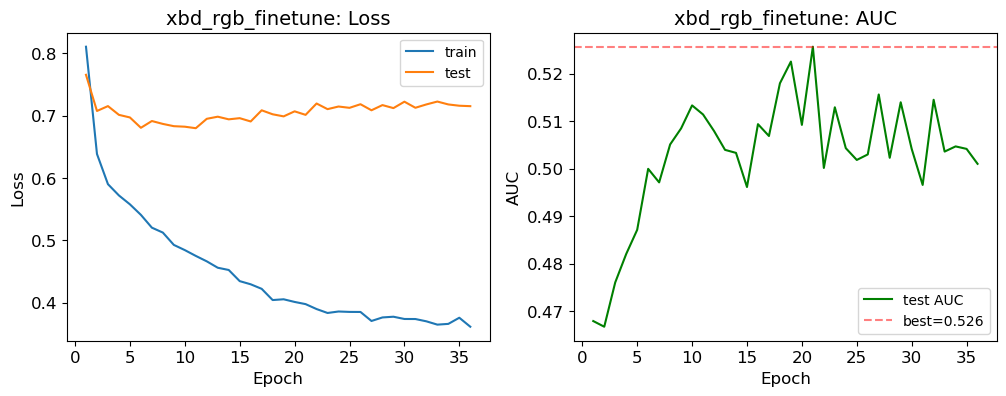

  Plot: xbd_rgb_finetune_curves_20260622_083415.png
  REG: d8b_xbd_rgb_finetune                          AUC=0.5257 F1=? n=None feat=0 cities=0 [NB09d/cell_d8]

  --- D8c: xBD ZERO-SHOT ON POST-ONLY RGB ---
  test: 662 patches (post_only, norm=/10000.0, multi-city (21 dirs))
  D8c RESULT: zero-shot AUC=0.4145
  REG: d8c_xbd_zeroshot_rgb                          AUC=0.4145 F1=? n=None feat=0 cities=0 [NB09d/cell_d8]
    saved oof -> oof_D8c_xbd_zeroshot_rgb__20260621_232712_213609.parquet  TP=0 FN=0 FP=431 TN=231


In [25]:
# @title CELL D8: POST-ONLY RGB EXPERIMENTS
# =============================================================================
# Three experiments using post-battle RGB only (3ch) from PATCH_DIR_MS:
# 1. BDA from post-only RGB (no xBD pretrain)
# 2. xBD pretrain + post-only RGB finetune
# 3. xBD zero-shot on post-only RGB
# Uses ACTIVE_PATCH_DIR (same patches as other cells) with post_only=True
# =============================================================================
print("=" * 70)
print("CELL D8: POST-ONLY RGB EXPERIMENTS")
print("=" * 70)

if ACTIVE_MODALITY != 'ms':
    print(f"  SKIP: post-only RGB requires MS modality (active={ACTIVE_MODALITY})")
elif len(df_patches) == 0:
    print(f"  SKIP: no patches available")
else:
    print(f"  Using patches from: {ACTIVE_PATCH_DIR}")
    print(f"  Patches: {len(df_patches)}, post_only=True (3ch RGB)")

    # Experiment 1: BDA post-only RGB from scratch
    print(f"\n  --- D8a: BDA POST-ONLY RGB (from scratch) ---")
    try:
        ds_train_rgb = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'train',
                                  list(range(3)), PATCH_SPLIT, 1, post_only=True)
        ds_test_rgb = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test',
                                 list(range(3)), PATCH_SPLIT, 1, post_only=True)
        ds_val_rgb = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'val',
                                list(range(3)), PATCH_SPLIT, 1, post_only=True)

        dl_train_rgb = DataLoader(ds_train_rgb, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
        dl_test_rgb = DataLoader(ds_test_rgb, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        dl_val_rgb = DataLoader(ds_val_rgb, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

        model_rgb = create_unet(in_channels=3, encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS).to(DEVICE)
        optimizer_rgb = torch.optim.Adam(model_rgb.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

        for epoch in range(NUM_EPOCHS_BDA):
            tl = train_epoch(model_rgb, dl_train_rgb, criterion, optimizer_rgb, DEVICE)
            vl, va = eval_epoch(model_rgb, dl_val_rgb, criterion, DEVICE)
            if (epoch+1) % 20 == 0:
                print(f"    Epoch {epoch+1}: train={tl:.4f} val_auc={va:.3f}")

        _, test_auc_rgb = eval_epoch(model_rgb, dl_test_rgb, criterion, DEVICE)
        print(f"  D8a RESULT: test_AUC={test_auc_rgb:.3f}")
        RESULTS_ALL['d8a_rgb_scratch'] = {'auc': test_auc_rgb}
        log_dl('d8a_rgb_scratch', test_auc_rgb, cell_id='cell_d8',
               note='Post-only RGB from scratch', tags=['dl', 'rgb', 'post_only', 'scratch'])
        extract_unet_oof(model_rgb, ds_test_rgb, DEVICE, 'D8a_rgb_scratch',
                         variant_id='unet_post_only;features=rgb;init=scratch')
        del model_rgb; gc.collect(); torch.cuda.empty_cache()
    except Exception as e:
        print(f"  D8a ERROR: {e}")

    # Experiment 2: xBD pretrain + post-only RGB finetune
    print(f"\n  --- D8b: xBD PRETRAIN + POST-ONLY RGB FINETUNE ---")
    if xbd_pretrain_skip:
        print("  SKIP: No xBD model")
    else:
        try:
            ft_train = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'train',
                                  list(range(3)), PATCH_SPLIT, 1, post_only=True)
            ft_test = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test',
                                 list(range(3)), PATCH_SPLIT, 1, post_only=True)

            m = create_unet(in_channels=3, encoder_weights=None)
            m.load_state_dict(torch.load(xbd_pretrain_path, map_location=DEVICE))
            m = m.to(DEVICE)
            o = optim.AdamW(m.parameters(), lr=LEARNING_RATE * 0.1, weight_decay=WEIGHT_DECAY)
            s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='min', factor=0.5, patience=5)
            h, best = train_model(m,
                DataLoader(ft_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS),
                DataLoader(ft_test, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS),
                criterion, o, s, NUM_EPOCHS_FINETUNE, DEVICE,
                MODEL_DIR / "xbd_rgb_finetune.pt", EARLY_STOP_PATIENCE)
            with open(RESULTS_DIR / "xbd_rgb_finetune_history.json", 'w') as f:
                json.dump(h, f, indent=2)
            plot_history(h, 'xbd_rgb_finetune')
            RESULTS_ALL['d8b_xbd_rgb_finetune'] = {'auc': best}
            log_dl('d8b_xbd_rgb_finetune', best, cell_id='cell_d8',
                   note='xBD pretrain + RGB post-only finetune', tags=['dl', 'rgb', 'post_only', 'finetune'])
            del m; gc.collect(); torch.cuda.empty_cache()
        except Exception as e:
            print(f"  D8b ERROR: {e}")

    # Experiment 3: xBD zero-shot on post-only RGB
    print(f"\n  --- D8c: xBD ZERO-SHOT ON POST-ONLY RGB ---")
    if xbd_pretrain_skip:
        print("  SKIP: No xBD model")
    else:
        try:
            zs_ds = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test',
                               list(range(3)), PATCH_SPLIT, 1, post_only=True)
            m = create_unet(in_channels=3, encoder_weights=None)
            m.load_state_dict(torch.load(xbd_pretrain_path, map_location=DEVICE))
            m = m.to(DEVICE)
            loss, auc = eval_epoch(m, DataLoader(zs_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS), criterion, DEVICE)
            print(f"  D8c RESULT: zero-shot AUC={auc:.4f}")
            RESULTS_ALL['d8c_xbd_zeroshot_rgb'] = {'auc': float(auc)}
            log_dl('d8c_xbd_zeroshot_rgb', float(auc), cell_id='cell_d8',
                   note='xBD zero-shot on RGB post-only', tags=['dl', 'rgb', 'post_only', 'zero_shot'])
            extract_unet_oof(m, zs_ds, DEVICE, 'D8c_xbd_zeroshot_rgb',
                             variant_id='unet_transfer;type=xbd_zero_shot;features=rgb_post_only')
            del m; gc.collect(); torch.cuda.empty_cache()
        except Exception as e:
            print(f"  D8c ERROR: {e}")


# D9: SIAMESE PRE/POST RGB (6ch concatenation)

In [26]:
# @title EXP: SIAMESE PRE/POST RGB (6ch concatenation)
EXP_ID_siam = "exp_siamese_rgb"
print("=" * 70)
print(f"EXP: SIAMESE PRE/POST RGB ({EXP_ID_siam})")
print("=" * 70)
print("Concatenates pre+post RGB (6ch) to give model temporal change signal.")
print("Tests whether pre/post comparison helps where single-image RGB fails.")
print()

# Use CHANNEL_GROUPS from Cell 10 (pre+post RGB = channels 0-5 in 6ch stack)
siam_channels = CHANNEL_GROUPS.get('ms_prepost', list(range(6)))
siam_channels_valid = len(siam_channels) == 6 and ACTIVE_MODALITY == 'ms'

if not siam_channels_valid:
    print(f"ERROR: Siamese requires MS patches with 6ch pre+post (modality={ACTIVE_MODALITY})")
else:
    print(f"Siamese channels (6ch): {siam_channels}")
    print(f"  [0-2] pre RGB (B04,B03,B02)")
    print(f"  [3-5] post RGB (B04,B03,B02)")

    siam_model_path = MODEL_DIR / f"{EXP_ID_siam}.pt"
    siam_history_path = RESULTS_DIR / f"{EXP_ID_siam}_history.json"

    if siam_model_path.exists() and not FORCE_RERUN_TRAINING:
        print(f"\nModel exists: {siam_model_path}")
        if siam_history_path.exists():
            with open(siam_history_path) as f:
                _h = json.load(f)
            print(f"Best AUC: {max(_h['test_auc']):.4f}")
    else:
        # use 20m2 masks (default, same as other experiments)
        siam_train = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'train', siam_channels, PATCH_SPLIT, 1)
        siam_test = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test', siam_channels, PATCH_SPLIT, 1)

        if len(siam_train) == 0:
            print("ERROR: train dataset empty")
        else:
            print(f"\nTrain: {len(siam_train)}, Test: {len(siam_test)}, 6ch")
            siam_train_loader = DataLoader(siam_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
            siam_test_loader = DataLoader(siam_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            # 6ch input -> no ImageNet weights
            siam_model = create_unet(in_channels=6, encoder_name=ENCODER_NAME)
            siam_model = siam_model.to(DEVICE)

            siam_opt = optim.AdamW(siam_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
            siam_sch = optim.lr_scheduler.ReduceLROnPlateau(siam_opt, mode='min', factor=0.5, patience=5)

            siam_h, siam_best = train_model(
                siam_model, siam_train_loader, siam_test_loader, criterion, siam_opt, siam_sch,
                NUM_EPOCHS_BDA, DEVICE, siam_model_path, EARLY_STOP_PATIENCE)

            with open(siam_history_path, 'w') as f:
                json.dump(siam_h, f, indent=2)
            plot_history(siam_h, EXP_ID_siam)
            RESULTS_ALL[f'd9_{EXP_ID_siam}'] = {'auc': siam_best}
            log_dl(f'd9_{EXP_ID_siam}', siam_best, cell_id='cell_d9',
                   note='Siamese pre/post RGB (6ch)', tags=['dl', 'siamese', 'prepost'])
            print(f"\nSiamese RGB Best AUC: {siam_best:.4f}")
            del siam_model; gc.collect(); torch.cuda.empty_cache()

EXP: SIAMESE PRE/POST RGB (exp_siamese_rgb)
Concatenates pre+post RGB (6ch) to give model temporal change signal.
Tests whether pre/post comparison helps where single-image RGB fails.

Siamese channels (6ch): [0, 1, 2, 3, 4, 5]
  [0-2] pre RGB (B04,B03,B02)
  [3-5] post RGB (B04,B03,B02)

Model exists: /content/masterthesis_local/nb09d_dl_experiments/models/exp_siamese_rgb.pt
Best AUC: 0.5461


# D10: MODALITY ABLATION

In [27]:
# @title CELL D10: MODALITY ABLATION (EXPERIMENT_CONFIGS sweep)
# =============================================================================
# Iterates EXPERIMENT_CONFIGS (built in Cell 1a). Covers:
#   ms_post_rgb (3ch)     -- MS post-only RGB, ImageNet init
#   ms_prepost (6ch)      -- MS pre+post RGB, no pretrain
#   card_post (2ch)       -- CARD post-only VV/VH, no pretrain
#   card_prepost (4ch)    -- CARD pre+post VV/VH, no pretrain
#   fusion_post (5ch)     -- MS+CARD post-only, no pretrain
#   fusion_prepost (10ch) -- MS+CARD pre+post, no pretrain
# All configs train from scratch here. xBD-pretrained fusion is in D13.
# NB08b reference: BDA CARD LogReg=0.693, BDA RGB ExtraTrees=0.750, BDA RGB+CARD LogReg=0.751
# =============================================================================
print("=" * 70)
print("CELL D10: MODALITY ABLATION (from-scratch sweep)")
print("=" * 70)

if not EXPERIMENT_CONFIGS:
    print("  EXPERIMENT_CONFIGS empty (check Cell 1a)")
else:
    for config_name, cfg in EXPERIMENT_CONFIGS.items():
        n_ch = cfg['in_channels']
        print(f"\n  === {config_name} ({n_ch} channels, modality={cfg['modality']}) ===")
        try:
            _nr = cfg.get('normalize_range', 10000.0)
            _cnr = cfg.get('card_normalize_range')
            ds_train = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                                  'train', cfg['channels'], PATCH_SPLIT, 1,
                                  normalize_range=_nr, post_only=cfg['post_only'],
                                  patch_dir_card=cfg['card_patch_dir'],
                                  card_normalize_range=_cnr)
            ds_test = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                                 'test', cfg['channels'], PATCH_SPLIT, 1,
                                 normalize_range=_nr, post_only=cfg['post_only'],
                                 patch_dir_card=cfg['card_patch_dir'],
                                 card_normalize_range=_cnr)
            ds_val = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                                'val', cfg['channels'], PATCH_SPLIT, 1,
                                normalize_range=_nr, post_only=cfg['post_only'],
                                patch_dir_card=cfg['card_patch_dir'],
                                card_normalize_range=_cnr)

            if len(ds_train) == 0 or len(ds_test) == 0:
                print(f"  SKIP: empty dataset (train={len(ds_train)}, test={len(ds_test)})")
                continue

            dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
            dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
            dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            enc_w = ENCODER_WEIGHTS if cfg['use_imagenet'] else None
            model_mod = create_unet(in_channels=n_ch, encoder_name=ENCODER_NAME,
                                    encoder_weights=enc_w).to(DEVICE)
            optimizer_mod = torch.optim.Adam(model_mod.parameters(), lr=LEARNING_RATE,
                                             weight_decay=WEIGHT_DECAY)

            best_auc = 0
            for epoch in range(NUM_EPOCHS_BDA):
                tl = train_epoch(model_mod, dl_train, criterion, optimizer_mod, DEVICE)
                vl, va = eval_epoch(model_mod, dl_val, criterion, DEVICE)
                best_auc = max(best_auc, va)
                if (epoch + 1) % 20 == 0:
                    print(f"    Epoch {epoch+1}: train={tl:.4f} val_auc={va:.3f}")

            _, test_auc = eval_epoch(model_mod, dl_test, criterion, DEVICE)
            print(f"  RESULT: {config_name} -> test_AUC={test_auc:.3f} (best_val={best_auc:.3f})")
            RESULTS_ALL[f'd10_{config_name}'] = {'auc': test_auc, 'n_channels': n_ch,
                                                 'modality': cfg['modality'],
                                                 'n_train': len(ds_train), 'n_test': len(ds_test)}
            log_dl(f'd10_{config_name}', test_auc, cell_id='cell_d10',
                   note=f"Modality ablation: {config_name} ({n_ch}ch, {cfg['modality']})",
                   tags=['dl', 'modality_ablation', config_name, cfg['modality']])
            extract_unet_oof(model_mod, ds_test, DEVICE, f'D10_{config_name}',
                             variant_id=f'unet_modality_ablation;config={config_name};channels={n_ch};modality={cfg["modality"]}')
            del model_mod; gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
        except Exception as e:
            print(f"  ERROR: {e}")

# summary
print(f"\n  D10 SUMMARY:")
for k in sorted(k for k in RESULTS_ALL if k.startswith('d10_')):
    v = RESULTS_ALL[k]
    print(f"    {k:30s} AUC={v.get('auc', 0):.3f} ({v.get('n_channels','?')}ch {v.get('modality','?')})")


CELL D10: MODALITY ABLATION (from-scratch sweep)

  === ms_post_rgb (3 channels, modality=ms) ===
  train: 1693 patches (post_only, norm=/10000.0, multi-city (21 dirs))
  test: 662 patches (post_only, norm=/10000.0, multi-city (21 dirs))
  val: 433 patches (post_only, norm=/10000.0, multi-city (21 dirs))
    Epoch 20: train=0.3192 val_auc=0.707
    Epoch 40: train=0.2265 val_auc=0.843
    Epoch 60: train=0.1372 val_auc=0.802
    Epoch 80: train=0.1090 val_auc=0.738
    Epoch 100: train=0.1040 val_auc=0.758
  RESULT: ms_post_rgb -> test_AUC=0.490 (best_val=0.873)
  REG: d10_ms_post_rgb                               AUC=0.4905 F1=? n=None feat=0 cities=0 [NB09d/cell_d10]
    saved oof -> oof_D10_ms_post_rgb__20260621_232712_213609.parquet  TP=0 FN=0 FP=0 TN=662

  === ms_prepost (6 channels, modality=ms) ===
  train: 1693 patches (pre+post, norm=/10000.0, multi-city (21 dirs))
  test: 662 patches (pre+post, norm=/10000.0, multi-city (21 dirs))
  val: 433 patches (pre+post, norm=/10000.0,

# D11: ATTENTION U-NET (SE-ResNeXt + scSE)

In [28]:
# @title CELL 6f: ARCHITECTURE COMPARISON
print("=" * 70)
print("CELL 6f: ARCHITECTURE COMPARISON")
print("=" * 70)

# create post-only RGB loaders inline
_arch_skip = ACTIVE_MODALITY != 'ms' or len(df_patches) == 0
if _arch_skip:
    print("  SKIP: requires MS patches")
    bda_tr, bda_te = None, None
else:
    _ds_tr = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'train',
                        CHANNEL_GROUPS.get('ms_post_rgb', list(range(3))), PATCH_SPLIT, 1, post_only=True)
    _ds_te = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test',
                        CHANNEL_GROUPS.get('ms_post_rgb', list(range(3))), PATCH_SPLIT, 1, post_only=True)
    bda_tr = DataLoader(_ds_tr, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    bda_te = DataLoader(_ds_te, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
if bda_tr is None or len(bda_tr) == 0:
    print("  No BDA patches. Run Cell 1a-1d first.")
else:
    arch_results = {}
    architectures = {
        'resnet34':        {'encoder': 'resnet34',        'attention': None,   'note': 'baseline'},
        'resnet50':        {'encoder': 'resnet50',        'attention': None,   'note': 'deeper encoder'},
        'efficientnet-b0': {'encoder': 'efficientnet-b0', 'attention': None,   'note': 'param efficient'},
        'resnet34+scse':   {'encoder': 'resnet34',        'attention': 'scse', 'note': 'spatial+channel SE'},
        'resnet50+scse':   {'encoder': 'resnet50',        'attention': 'scse', 'note': 'deeper + attention'},
    }

    for arch_name, cfg in architectures.items():
        print(f"\n  --- {arch_name} ({cfg['note']}) ---")
        t0 = time.time()
        try:
            model_arch = smp.Unet(encoder_name=cfg['encoder'], encoder_weights='imagenet',
                                   in_channels=3, classes=1, decoder_attention_type=cfg['attention'])
            model_arch = model_arch.to(DEVICE)
            n_params = sum(p.numel() for p in model_arch.parameters())
            print(f"    Parameters: {n_params/1e6:.1f}M")

            arch_model_path = MODEL_DIR / f"arch_{arch_name.replace('+','_')}.pt"
            o = optim.AdamW(model_arch.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
            s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='min', factor=0.5, patience=5)
            h, best_auc = train_model(model_arch, bda_tr, bda_te, criterion, o, s,
                                       NUM_EPOCHS_BDA, DEVICE, arch_model_path, EARLY_STOP_PATIENCE)
            elapsed = time.time() - t0
            arch_results[arch_name] = {
                'auc': best_auc, 'n_params_M': n_params / 1e6,
                'time_min': elapsed / 60, 'note': cfg['note'],
            }
            RESULTS_ALL[f'd11_{arch_name}'] = {'auc': best_auc}
            log_dl(f'd11_{arch_name}', best_auc, cell_id='cell_d11',
                   note=f'Architecture comparison: {arch_name}',
                   tags=['dl', 'architecture', arch_name])
            print(f"    AUC={best_auc:.3f}, Time={elapsed/60:.1f}min")
            plot_history(h, f'arch_{arch_name}')
            del model_arch; torch.cuda.empty_cache()
        except Exception as e:
            print(f"    FAILED: {e}")
            arch_results[arch_name] = {'auc': 0, 'note': f'FAILED: {e}'}

    # summary
    print(f"\n{'='*75}")
    print(f"  ARCHITECTURE COMPARISON SUMMARY")
    print(f"{'='*75}")
    print(f"  {'Architecture':25s} {'AUC':>7s} {'Params':>8s} {'Time':>8s} {'Note'}")
    for name, r in sorted(arch_results.items(), key=lambda x: -x[1].get('auc', 0)):
        print(f"  {name:25s} {r.get('auc',0):7.3f} {r.get('n_params_M',0):7.1f}M {r.get('time_min',0):7.1f}m {r.get('note','')}")

    if arch_results:
        arch_df = pd.DataFrame([{'architecture': k, **v} for k, v in arch_results.items()])
        save_result(arch_df, 'architecture_comparison', 'cell_d11')


CELL 6f: ARCHITECTURE COMPARISON
  train: 1693 patches (post_only, norm=/10000.0, multi-city (21 dirs))
  test: 662 patches (post_only, norm=/10000.0, multi-city (21 dirs))

  --- resnet34 (baseline) ---
    Parameters: 24.4M
    FAILED: index 3 is out of bounds for axis 0 with size 3

  --- resnet50 (deeper encoder) ---
    Parameters: 32.5M
    FAILED: index 3 is out of bounds for axis 0 with size 3

  --- efficientnet-b0 (param efficient) ---
    Parameters: 6.3M
    FAILED: index 3 is out of bounds for axis 0 with size 3

  --- resnet34+scse (spatial+channel SE) ---
    Parameters: 24.6M
    FAILED: index 3 is out of bounds for axis 0 with size 3

  --- resnet50+scse (deeper + attention) ---
    Parameters: 33.8M
    FAILED: index 3 is out of bounds for axis 0 with size 3

  ARCHITECTURE COMPARISON SUMMARY
  Architecture                  AUC   Params     Time Note
  resnet34                    0.000     0.0M     0.0m FAILED: index 3 is out of bounds for axis 0 with size 3
  resnet5

# D13: xBD-PRETRAINED FUSION (MS+CARD)

Key iteration-C experiment. Builds a multimodal U-Net where the RGB channels of
the first conv receive xBD pretrained weights (via first-conv surgery), while
CARD channels are randomly initialised. Rest of encoder + decoder fully inherits
xBD weights. Then finetuned on BDA fusion patches.

Rationale (NB08b findings):
- BDA RGB pixel features have Cohen's d ~ 0 (no pixel-level signal at 10m)
- BDA CARD features have Cohen's d 0.3-0.6 (real pixel-level signal)
- xBD-pretrained RGB zero-shot transfers to BDA with AUC=0.70
- xBD pretraining carries useful texture priors; CARD adds the signal that RGB lacks

Experiments:
- D13a: xBD pretrain -> fusion_post (5ch) finetune
- D13b: xBD pretrain -> fusion_prepost (10ch) finetune


In [29]:
# @title CELL D13: xBD-PRETRAINED FUSION EXPERIMENTS
# =============================================================================
# xBD-pretrained fusion U-Net: RGB channels init from xBD, CARD channels random.
# Uses create_fusion_unet_from_xbd() (Cell 0d).
# =============================================================================
print("=" * 70)
print("CELL D13: xBD-PRETRAINED FUSION (MS+CARD)")
print("=" * 70)

if not FUSION_AVAILABLE:
    print("  SKIP: fusion requires both MS and CARD patches (check Cell 1a)")
elif xbd_pretrain_skip:
    print("  SKIP: no xBD pretrained model available")
else:
    # rgb_indices per fusion stack (see BDADataset docstring)
    #   fusion_post  5ch: RGB_post [0,1,2] then CARD_post [3,4]
    #   fusion_prepost 10ch: RGB_pre [0,1,2] + RGB_post [3,4,5] + CARD_pre [6,7] + CARD_post [8,9]
    D13_EXPERIMENTS = {
        'd13a_fusion_post_xbd': dict(
            config_name='fusion_post', rgb_indices=[0, 1, 2]),
        'd13b_fusion_prepost_xbd': dict(
            config_name='fusion_prepost', rgb_indices=[0, 1, 2, 3, 4, 5]),
    }

    for exp_name, spec in D13_EXPERIMENTS.items():
        cfg = EXPERIMENT_CONFIGS.get(spec['config_name'])
        if cfg is None:
            print(f"\n  SKIP {exp_name}: EXPERIMENT_CONFIGS['{spec['config_name']}'] missing")
            continue
        n_ch = cfg['in_channels']
        print(f"\n  === {exp_name} ({n_ch}ch, rgb_indices={spec['rgb_indices']}) ===")

        fm_path = MODEL_DIR / f"{exp_name}.pt"
        fh_path = RESULTS_DIR / f"{exp_name}_history.json"
        if fm_path.exists() and not FORCE_RERUN_TRAINING:
            if fh_path.exists():
                with open(fh_path) as f: _h = json.load(f)
                best = max(_h['test_auc'])
                print(f"  Cached: best AUC={best:.4f}")
                RESULTS_ALL[exp_name] = {'auc': best, 'n_channels': n_ch, 'modality': 'fusion_xbd'}
                log_dl(exp_name, best, cell_id='cell_d13',
                       note=f'xBD-pretrained fusion (cached): {spec["config_name"]}',
                       tags=['dl', 'fusion', 'xbd_pretrain', spec['config_name'], 'cached'])
            continue

        try:
            _nr = cfg.get('normalize_range', 10000.0)
            _cnr = cfg.get('card_normalize_range')
            ds_train = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                                  'train', cfg['channels'], PATCH_SPLIT, 1,
                                  normalize_range=_nr, post_only=cfg['post_only'],
                                  patch_dir_card=cfg['card_patch_dir'],
                                  card_normalize_range=_cnr)
            ds_test = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                                 'test', cfg['channels'], PATCH_SPLIT, 1,
                                 normalize_range=_nr, post_only=cfg['post_only'],
                                 patch_dir_card=cfg['card_patch_dir'],
                                 card_normalize_range=_cnr)
            if len(ds_train) == 0 or len(ds_test) == 0:
                print(f"  SKIP: empty dataset (train={len(ds_train)}, test={len(ds_test)})")
                continue

            dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
            dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            m = create_fusion_unet_from_xbd(
                xbd_weights_path=xbd_pretrain_path,
                in_channels=n_ch,
                rgb_indices=spec['rgb_indices'],
                encoder_name=ENCODER_NAME,
            ).to(DEVICE)
            # lower LR for finetune (matches D5b)
            o = optim.AdamW(m.parameters(), lr=LEARNING_RATE * 0.1, weight_decay=WEIGHT_DECAY)
            s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='min', factor=0.5, patience=5)
            h, best = train_model(m, dl_train, dl_test, criterion, o, s,
                                  NUM_EPOCHS_FINETUNE, DEVICE, fm_path, EARLY_STOP_PATIENCE)
            with open(fh_path, 'w') as f:
                json.dump(h, f, indent=2)
            plot_history(h, exp_name)
            RESULTS_ALL[exp_name] = {'auc': best, 'n_channels': n_ch, 'modality': 'fusion_xbd',
                                     'n_train': len(ds_train), 'n_test': len(ds_test)}
            log_dl(exp_name, best, cell_id='cell_d13',
                   note=f'xBD-pretrained fusion finetune: {spec["config_name"]}',
                   tags=['dl', 'fusion', 'xbd_pretrain', spec['config_name']])
            del m; gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
        except Exception as e:
            print(f"  ERROR: {e}")

# summary
print(f"\n  D13 SUMMARY:")
for k in sorted(k for k in RESULTS_ALL if k.startswith('d13')):
    v = RESULTS_ALL[k]
    print(f"    {k:35s} AUC={v.get('auc', 0):.3f} ({v.get('n_channels','?')}ch)")


CELL D13: xBD-PRETRAINED FUSION (MS+CARD)

  === d13a_fusion_post_xbd (5ch, rgb_indices=[0, 1, 2]) ===
  Cached: best AUC=0.5112
  REG: d13a_fusion_post_xbd                          AUC=0.5112 F1=? n=None feat=0 cities=0 [NB09d/cell_d13]

  === d13b_fusion_prepost_xbd (10ch, rgb_indices=[0, 1, 2, 3, 4, 5]) ===
  Cached: best AUC=0.5245
  REG: d13b_fusion_prepost_xbd                       AUC=0.5245 F1=? n=None feat=0 cities=0 [NB09d/cell_d13]

  D13 SUMMARY:
    d13a_fusion_post_xbd                AUC=0.511 (5ch)
    d13b_fusion_prepost_xbd             AUC=0.525 (10ch)


# D12: RESULTS SUMMARY + SAVE

CELL D12: RESULTS SUMMARY

  Experiment                                     AUC  Note
  ------------------------------------------ -------  ----------------------------------------
  Dietrich_2025_RF                             0.813  Dietrich 2025 RF (paper ref)
  xBD_on_xBD                                   0.876  xBD-on-xBD U-Net (DL clean-sup ceiling)
  NB08b_BDA_RGB_ExtraTrees                     0.750  NB08b: BDA single-scene RGB, ExtraTrees (area_px-driven)
  NB08b_BDA_CARD_LogReg                        0.693  NB08b: BDA single-scene CARD, LogReg
  NB08b_BDA_RGB_CARD_LogReg                    0.751  NB08b: BDA RGB+CARD tabular fusion, LogReg
  NB08b_BDA_COHDROP_RGB_CARD                   0.748  NB08b: BDA COH_DROP+RGB+CARD, LogReg
  ------------------------------------------ -------  ----------------------------------------
  bda_min100                                   0.522  
  bda_min20                                    0.459  
  bda_min200                                   

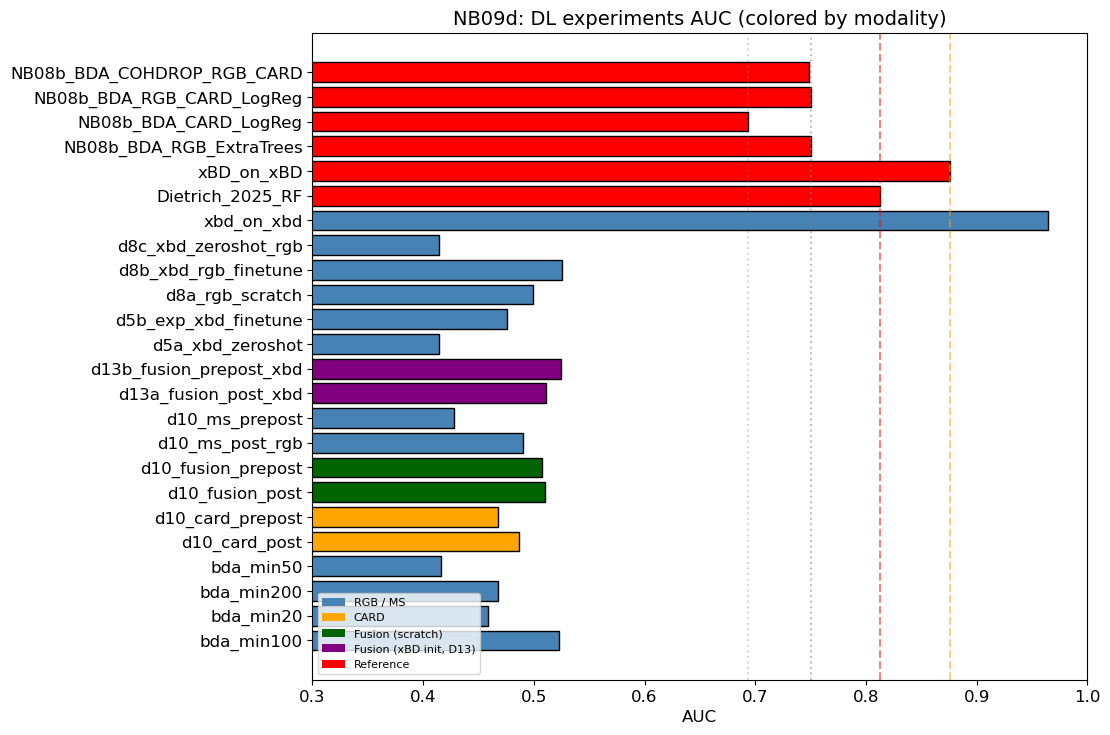

  Plot: dl_experiments_auc_20260622_194258.png

  BEST PER MODALITY:
    card           : d10_card_post                       AUC=0.486
    fusion         : d10_fusion_post                     AUC=0.510
    fusion_xbd     : d13b_fusion_prepost_xbd             AUC=0.525
    ms             : d10_ms_post_rgb                     AUC=0.490
    unknown        : xbd_on_xbd                          AUC=0.964


In [30]:
# @title CELL D12: RESULTS SUMMARY + SAVE
import json

print("=" * 70)
print("CELL D12: RESULTS SUMMARY")
print("=" * 70)

# references (paper + this-thesis tabular baselines from NB08b)
REFERENCES = {
    'Dietrich_2025_RF':            {'auc': 0.813, 'note': 'Dietrich 2025 RF (paper ref)',          'color': 'red'},
    'xBD_on_xBD':                  {'auc': 0.876, 'note': 'xBD-on-xBD U-Net (DL clean-sup ceiling)', 'color': 'orange'},
    'NB08b_BDA_RGB_ExtraTrees':    {'auc': 0.7503,'note': 'NB08b: BDA single-scene RGB, ExtraTrees (area_px-driven)', 'color': 'gray'},
    'NB08b_BDA_CARD_LogReg':       {'auc': 0.6932,'note': 'NB08b: BDA single-scene CARD, LogReg',  'color': 'gray'},
    'NB08b_BDA_RGB_CARD_LogReg':   {'auc': 0.7506,'note': 'NB08b: BDA RGB+CARD tabular fusion, LogReg', 'color': 'gray'},
    'NB08b_BDA_COHDROP_RGB_CARD':  {'auc': 0.7483,'note': 'NB08b: BDA COH_DROP+RGB+CARD, LogReg',  'color': 'gray'},
}

# ---- printed table ----
print(f"\n  {'Experiment':<42s} {'AUC':>7s}  {'Note'}")
print(f"  {'-'*42} {'-'*7}  {'-'*40}")
for key, ref in REFERENCES.items():
    print(f"  {key:<42s} {ref['auc']:>7.3f}  {ref['note']}")
print(f"  {'-'*42} {'-'*7}  {'-'*40}")
for key in sorted(RESULTS_ALL.keys()):
    auc = RESULTS_ALL[key].get('auc', 0)
    mod = RESULTS_ALL[key].get('modality', '')
    nch = RESULTS_ALL[key].get('n_channels', '')
    extra = f'{mod} {nch}ch' if mod else ''
    print(f"  {key:<42s} {auc:>7.3f}  {extra}")

# ---- save json + csv ----
serializable = {k: {kk: float(vv) if isinstance(vv, (int, float)) else str(vv)
                    for kk, vv in v.items()}
                for k, v in RESULTS_ALL.items()}
save_result(serializable, 'nb09d_results', 'cell_d12', fmt='json')

summary_rows = [{'experiment': k, 'auc': v.get('auc', 0),
                 'modality': v.get('modality', ''),
                 'n_channels': v.get('n_channels', '')}
                for k, v in sorted(RESULTS_ALL.items())]
for rk, rv in REFERENCES.items():
    summary_rows.append({'experiment': rk, 'auc': rv['auc'], 'modality': 'reference', 'n_channels': ''})
if summary_rows:
    save_result(pd.DataFrame(summary_rows), 'experiment_summary', 'cell_d12')

# ---- OOF predictions inventory (for NB12 overlap analysis) ----
print(f"\n  OOF predictions inventory  ({OOF_DIR})")
oof_files = sorted(OOF_DIR.glob('oof_*.parquet'))
if oof_files:
    inv_rows = []
    for p in oof_files:
        head = pd.read_parquet(p, columns=['model_id', 'variant_id', 'cm_class'])
        cm = head['cm_class'].value_counts()
        inv_rows.append({
            'file':       p.name,
            'model_id':   head['model_id'].iloc[0],
            'variant_id': head['variant_id'].iloc[0],
            'n_rows':     len(head),
            'TP':         int(cm.get('TP', 0)),
            'FN':         int(cm.get('FN', 0)),
            'FP':         int(cm.get('FP', 0)),
            'TN':         int(cm.get('TN', 0)),
        })
    inv_df = pd.DataFrame(inv_rows)
    save_result(inv_df, 'nb09d_oof_inventory', 'cell_d12')
    print(f"  Total OOF parquets: {len(oof_files)}")
else:
    print(f"  No OOF parquets saved")

# ---- registry ----
# note: log_reference / log_experiment signature mismatch in bda_results.py can raise
# TypeError here. Keep going so the bar chart + summary below still render.
_refs_to_log = [
    ('Dietrich_2025',                       {'auc': 0.813, 'f1': 0.749,
        'paper': 'Dietrich et al. 2025', 'note': 'RF on S1, geographic split'}),
    ('xBD_on_xBD_reference',                {'auc': 0.876,
        'paper': 'this_thesis', 'note': 'xBD pretrain+eval on xBD val (VALID)'}),
    ('NB08b_BDA_RGB_ExtraTrees',            {'auc': 0.7503,
        'paper': 'this_thesis_nb08b',
        'note': 'BDA single-scene RGB, ExtraTrees, 21 cities, GroupKFold (area_px-driven)'}),
    ('NB08b_BDA_CARD_LogReg',               {'auc': 0.6932,
        'paper': 'this_thesis_nb08b',
        'note': 'BDA single-scene CARD (VV/VH), LogReg, 21 cities'}),
    ('NB08b_BDA_RGB_CARD_LogReg',           {'auc': 0.7506,
        'paper': 'this_thesis_nb08b',
        'note': 'BDA RGB+CARD tabular fusion, LogReg, 21 cities'}),
    ('NB08b_BDA_COHDROP_RGB_CARD_LogReg',   {'auc': 0.7483,
        'paper': 'this_thesis_nb08b',
        'note': 'BDA COH_DROP+RGB+CARD, LogReg, 12 cities (COH-available)'}),
]
_registry_errors = 0
for _name, _kw in _refs_to_log:
    try:
        registry.log_reference(_name, **_kw)
    except TypeError as _e:
        _registry_errors += 1
        if _registry_errors == 1:
            print(f"  WARN: registry.log_reference failed ({_e}). Skipping registry refs.")
try:
    registry.save()
except Exception as _e:
    print(f"  WARN: registry.save failed: {_e}")

# ---- bar chart: color by modality ----
def _modality_color(key, default='steelblue'):
    if 'reference' in key.lower() or key in REFERENCES:
        return 'red'
    if key.startswith('d13'): return 'purple'          # xBD fusion
    k_lo = key.lower()
    if 'fusion' in k_lo: return 'darkgreen'             # fusion from scratch
    if 'card' in k_lo: return 'orange'                  # CARD
    if 'rgb' in k_lo or 'xbd' in k_lo or 'siamese' in k_lo or k_lo.startswith('bda_min'):
        return 'steelblue'                              # RGB/MS variants
    return default

if RESULTS_ALL or REFERENCES:
    import matplotlib.pyplot as plt
    all_rows = []
    for k, v in sorted(RESULTS_ALL.items()):
        all_rows.append({'experiment': k, 'auc': v.get('auc', 0)})
    for rk, rv in REFERENCES.items():
        all_rows.append({'experiment': rk, 'auc': rv['auc']})
    labels = [r['experiment'] for r in all_rows]
    aucs = [r['auc'] for r in all_rows]
    colors = [_modality_color(l) for l in labels]
    fig, ax = plt.subplots(figsize=(10, max(3, len(labels) * 0.35)))
    ax.barh(labels, aucs, color=colors, edgecolor='black')
    ax.set_xlabel('AUC')
    ax.set_xlim(0.3, 1.0)
    ax.axvline(0.813, color='red', linestyle='--', alpha=0.5, label='Dietrich=0.813')
    ax.axvline(0.876, color='orange', linestyle='--', alpha=0.5, label='xBD-on-xBD=0.876')
    ax.axvline(0.7503, color='gray', linestyle=':', alpha=0.5, label='NB08b BDA RGB tab=0.750')
    ax.axvline(0.6932, color='gray', linestyle=':', alpha=0.3, label='NB08b BDA CARD tab=0.693')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_title('NB09d: DL experiments AUC (colored by modality)')
    # legend for modalities
    from matplotlib.patches import Patch
    mod_legend = [
        Patch(facecolor='steelblue', label='RGB / MS'),
        Patch(facecolor='orange',    label='CARD'),
        Patch(facecolor='darkgreen', label='Fusion (scratch)'),
        Patch(facecolor='purple',    label='Fusion (xBD init, D13)'),
        Patch(facecolor='red',       label='Reference'),
    ]
    ax.legend(handles=mod_legend, fontsize=8, loc='lower left')
    save_fig(fig, 'dl_experiments_auc', 'cell_d12')

# ---- best-per-modality ----
print(f"\n  BEST PER MODALITY:")
by_mod = {}
for k, v in RESULTS_ALL.items():
    mod = v.get('modality', 'unknown')
    auc = v.get('auc', 0)
    if mod not in by_mod or auc > by_mod[mod][1]:
        by_mod[mod] = (k, auc)
for mod, (k, auc) in sorted(by_mod.items()):
    print(f"    {mod:15s}: {k:35s} AUC={auc:.3f}")


# D14: PAPER ARCHITECTURES (two-stream + Oktay attention + RescueNet)

Replicates the core architectural ideas of:

- Adriano et al. 2021 (RIKEN multimodal multitemporal Attention U-Net): two-stream encoder, pre and post images fed through separate ResNet/SE-ResNeXt streams; features concatenated at every skip and routed through Oktay attention gates before the U-Net decoder.
- Wu et al. 2021 (xBD attention U-Net with SE-ResNeXt/DPN/SENet backbones): same two-stream + attention-gate idea, swept across backbones.
- Gupta and Shah 2021 (RescueNet): dilated ResNet50 + ASPP backbone (smp DeepLabV3Plus is the same architecture), plus a change-detection head that consumes pre/post feature differences. Combined with a localization-aware loss.

All cells reuse the existing BDADataset, EXPERIMENT_CONFIGS, train_model, log_dl, and extract_unet_oof helpers. Channel splits for each modality come from BDADataset's documented stacking order.


In [31]:
# @title CELL D14: PAPER MODEL DEFINITIONS (TwoStreamAttnUNet, RescueNetLite, losses)
# =============================================================================
# Defines:
#   _OktayAttentionGate   - Oktay et al. 2018 attention gate (Adriano + Wu)
#   _DecoderBlock         - manual U-Net decoder block (no SMP internals stolen)
#   TwoStreamAttnUNet     - Adriano-style two-encoder U-Net with attention gates
#   RescueNetLite         - DeepLabV3Plus Siamese seg + change-detection head on feature diff
#   LocalizationAwareBCEDiceLoss - RescueNet eq.1 collapsed to binary BDA
#   loc_aware_criterion   - shared instance used by D14b, D15 rescuenet, D16 rescuenet
# Channel split helper:
#   PAPER_CHANNEL_SPLITS  - dict mapping config_name -> (pre_indices, post_indices)
# =============================================================================
print("=" * 70)
print("CELL D14: PAPER MODEL DEFINITIONS")
print("=" * 70)


class _OktayAttentionGate(nn.Module):
    """Oktay et al. 2018 attention gate used by Adriano 2021 and Wu 2021."""
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1, bias=True), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1, bias=True), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=True), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        if g.shape[-2:] != x.shape[-2:]:
            g = nn.functional.interpolate(g, size=x.shape[-2:], mode='bilinear', align_corners=False)
        psi = self.relu(self.W_g(g) + self.W_x(x))
        psi = self.psi(psi)
        return x * psi


class _DecoderBlock(nn.Module):
    """Manual U-Net decoder block (upsample -> concat skip -> 2x conv-bn-relu)."""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
    def forward(self, x, skip):
        x = nn.functional.interpolate(x, scale_factor=2.0, mode='bilinear', align_corners=False)
        if skip is not None:
            if x.shape[-2:] != skip.shape[-2:]:
                x = nn.functional.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
            x = torch.cat([x, skip], dim=1)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x


class TwoStreamAttnUNet(nn.Module):
    """Adriano et al. 2021 two-stream Attention U-Net.

    Two SMP encoders process pre and post images separately. At each scale
    the two feature maps are concatenated and reduced via 1x1 conv (Adriano
    section 3.1, Fig.4). Each fused skip then goes through an Oktay attention
    gate (gated by the next-deeper fused feature) before being passed to a
    manually-built U-Net decoder (no SMP decoder internals stolen).

    Input: [B, C_pre + C_post, H, W] in the order produced by BDADataset.
    pre_indices / post_indices select the channels of each stream from the
    concatenated input.
    """
    DECODER_CHANNELS = (256, 128, 64, 32, 16)

    def __init__(self, pre_indices, post_indices, encoder_name='resnet34',
                 encoder_weights='imagenet', classes=1, use_attention=True):
        super().__init__()
        self.pre_indices = list(pre_indices)
        self.post_indices = list(post_indices)
        n_pre = len(self.pre_indices)
        n_post = len(self.post_indices)
        ew_pre = encoder_weights if n_pre == 3 else None
        ew_post = encoder_weights if n_post == 3 else None
        self.encoder_pre  = smp.encoders.get_encoder(encoder_name, in_channels=n_pre,  weights=ew_pre)
        self.encoder_post = smp.encoders.get_encoder(encoder_name, in_channels=n_post, weights=ew_post)
        ch = list(self.encoder_pre.out_channels)  # length depth+1, e.g. ResNet34 = (3,64,64,128,256,512)
        self.fusion = nn.ModuleList([
            nn.Sequential(nn.Conv2d(2 * c, c, 1, bias=False), nn.BatchNorm2d(c), nn.ReLU(inplace=True))
            for c in ch])
        self.use_attention = use_attention
        if use_attention:
            self.attn = nn.ModuleList([
                _OktayAttentionGate(
                    F_g=ch[i + 1] if i + 1 < len(ch) else ch[i],
                    F_l=ch[i],
                    F_int=max(ch[i] // 2, 1))
                for i in range(len(ch))])
        # manual decoder. Encoder produces depth+1 features (incl. raw input at idx 0).
        # Number of upsampling blocks = depth = len(ch) - 1. We reuse skips ch[-2..0].
        n_blocks = len(ch) - 1
        decoder_channels = list(self.DECODER_CHANNELS)[:n_blocks]
        self.decoder_blocks = nn.ModuleList()
        in_ch = ch[-1]
        for i, out_ch in enumerate(decoder_channels):
            skip_ch = ch[-(i + 2)] if (i + 2) <= len(ch) else 0
            self.decoder_blocks.append(_DecoderBlock(in_ch, skip_ch, out_ch))
            in_ch = out_ch
        self.segmentation_head = nn.Conv2d(decoder_channels[-1], classes, 3, padding=1)

    def forward(self, x):
        pre = x[:, self.pre_indices]
        post = x[:, self.post_indices]
        feats_pre = list(self.encoder_pre(pre))
        feats_post = list(self.encoder_post(post))
        fused = [fuse(torch.cat([fp, fq], dim=1))
                 for fp, fq, fuse in zip(feats_pre, feats_post, self.fusion)]
        if self.use_attention:
            gated = []
            for i, f in enumerate(fused):
                g_idx = min(i + 1, len(fused) - 1)
                gated.append(self.attn[i](fused[g_idx], f))
            fused = gated
        # manual decoder: deepest feature is fused[-1], skips are fused[-2], fused[-3], ..., fused[0]
        rev = fused[::-1]
        out = rev[0]
        for i, block in enumerate(self.decoder_blocks):
            skip = rev[i + 1] if (i + 1) < len(rev) else None
            out = block(out, skip)
        # final upsample to input H,W if the deepest block did not reach it
        if out.shape[-2:] != x.shape[-2:]:
            out = nn.functional.interpolate(out, size=x.shape[-2:], mode='bilinear', align_corners=False)
        return self.segmentation_head(out)


class RescueNetLite(nn.Module):
    """Gupta and Shah 2021 RescueNet-inspired (binary BDA, Siamese encoder).

    Per the paper (Fig. 2, "Both share the same weight"), pre and post images
    are processed by the SAME encoder. We use smp.DeepLabV3Plus (= dilated
    ResNet50 + ASPP) as the segmentation network on the post image, then run
    its encoder a second time on the pre image and compute the deepest-feature
    difference. The change-detection head consumes that difference and is
    upsampled to full resolution; the final logits are the average of the
    seg-head and change-head outputs.

    Requires n_pre == n_post (Siamese constraint).
    """
    def __init__(self, pre_indices, post_indices,
                 encoder_name='resnet50', encoder_weights='imagenet', classes=1):
        super().__init__()
        self.pre_indices = list(pre_indices)
        self.post_indices = list(post_indices)
        n_pre = len(self.pre_indices)
        n_post = len(self.post_indices)
        if n_pre != n_post:
            raise ValueError(
                f"RescueNetLite requires equal pre/post channels (got pre={n_pre}, post={n_post}). "
                "Use ms_prepost (3+3), card_prepost (2+2), or fusion_prepost (5+5).")
        ew = encoder_weights if n_post == 3 else None
        self.seg_net = smp.DeepLabV3Plus(
            encoder_name=encoder_name, encoder_weights=ew,
            in_channels=n_post, classes=classes, activation=None)
        deep_ch = self.seg_net.encoder.out_channels[-1]
        self.change_head = nn.Sequential(
            nn.Conv2d(deep_ch, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout(0.2),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, classes, 1))

    def forward(self, x):
        pre = x[:, self.pre_indices]
        post = x[:, self.post_indices]
        seg_logits = self.seg_net(post)
        feats_post = self.seg_net.encoder(post)
        feats_pre  = self.seg_net.encoder(pre)   # SIAMESE: shared weights
        diff = feats_post[-1] - feats_pre[-1]
        chg_small = self.change_head(diff)
        chg_logits = nn.functional.interpolate(
            chg_small, size=seg_logits.shape[-2:], mode='bilinear', align_corners=False)
        return 0.5 * (seg_logits + chg_logits)


class LocalizationAwareBCEDiceLoss(nn.Module):
    """Gupta and Shah 2021 localization-aware loss collapsed to binary BDA.

    Foreground (weight > 0, building footprint): BCE on damage label + Dice.
    Background (weight == 0): BCE pushing logits toward 0 (no damage), scaled
                              by bg_weight to avoid drowning out the signal.
    Reduces to MaskedBCEDiceLoss when bg_weight=0.
    """
    def __init__(self, bce_weight=0.5, dice_weight=0.5, bg_weight=0.1):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bg_weight = bg_weight
        self.bce = nn.BCEWithLogitsLoss(reduction='none')
    def forward(self, logits, targets, weights):
        bce = self.bce(logits, targets)
        fg_w = weights
        fg_bce = (bce * fg_w).sum() / (fg_w.sum() + 1e-8)
        bg_mask = (fg_w == 0).float()
        bg_bce = (bce * bg_mask * self.bg_weight).sum() / (bg_mask.sum() + 1e-8)
        probs = torch.sigmoid(logits)
        inter = (probs * fg_w * targets).sum()
        union = (probs * fg_w).sum() + (targets * fg_w).sum()
        dice = 1 - (2 * inter + 1e-8) / (union + 1e-8)
        return self.bce_weight * (fg_bce + bg_bce) + self.dice_weight * dice


# Shared loc-aware criterion instance (used by D14b RescueNet sweep, D15 rescuenet
# xBD pretrain, D16 rescuenet finetune). Defined here in setup so D15/D16 do not
# depend on D14b having been executed first.
loc_aware_criterion = LocalizationAwareBCEDiceLoss(bce_weight=0.5, dice_weight=0.5, bg_weight=0.1)


# Channel split LUT per BDADataset modality (see BDADataset docstring).
# fusion_prepost stack order: [RGB_pre(3) + RGB_post(3) + CARD_pre(2) + CARD_post(2)] = 10ch
PAPER_CHANNEL_SPLITS = {
    'ms_prepost':     dict(pre=[0, 1, 2],          post=[3, 4, 5]),
    'card_prepost':   dict(pre=[0, 1],             post=[2, 3]),
    'fusion_prepost': dict(pre=[0, 1, 2, 6, 7],    post=[3, 4, 5, 8, 9]),
}


# ---- self-test: model construction + tiny forward (catches SMP / shape bugs early) ----
def _d14_self_test():
    print("\n  self-test: instantiating models on a 2x6x64x64 dummy batch...")
    try:
        x = torch.zeros(2, 6, 64, 64)
        m = TwoStreamAttnUNet(pre_indices=[0, 1, 2], post_indices=[3, 4, 5],
                               encoder_name='resnet34', encoder_weights=None, classes=1)
        y = m(x)
        print(f"    TwoStreamAttnUNet OK  out shape={tuple(y.shape)}")
        del m, y
    except Exception as e:
        print(f"    TwoStreamAttnUNet FAILED: {type(e).__name__}: {e}")
    try:
        x = torch.zeros(2, 6, 64, 64)
        m = RescueNetLite(pre_indices=[0, 1, 2], post_indices=[3, 4, 5],
                           encoder_name='resnet50', encoder_weights=None, classes=1)
        y = m(x)
        print(f"    RescueNetLite     OK  out shape={tuple(y.shape)}")
        del m, y
    except Exception as e:
        print(f"    RescueNetLite     FAILED: {type(e).__name__}: {e}")
    gc.collect()


_d14_self_test()

print(f"\nDefined: _OktayAttentionGate, _DecoderBlock, TwoStreamAttnUNet, RescueNetLite,")
print(f"         LocalizationAwareBCEDiceLoss, loc_aware_criterion, PAPER_CHANNEL_SPLITS")
print(f"PAPER_CHANNEL_SPLITS keys: {list(PAPER_CHANNEL_SPLITS.keys())}")
print(f"smp version: {smp.__version__}")


CELL D14: PAPER MODEL DEFINITIONS

  self-test: instantiating models on a 2x6x64x64 dummy batch...
    TwoStreamAttnUNet OK  out shape=(2, 1, 64, 64)
    RescueNetLite     OK  out shape=(2, 1, 64, 64)

Defined: _OktayAttentionGate, _DecoderBlock, TwoStreamAttnUNet, RescueNetLite,
         LocalizationAwareBCEDiceLoss, loc_aware_criterion, PAPER_CHANNEL_SPLITS
PAPER_CHANNEL_SPLITS keys: ['ms_prepost', 'card_prepost', 'fusion_prepost']
smp version: 0.5.0


# D14a: ADRIANO TWO-STREAM ATTENTION U-NET (per modality)

Sweeps the Adriano-style two-stream Attention U-Net across the three pre+post
modalities defined in EXPERIMENT_CONFIGS:

- ms_prepost   (6ch, optical pre+post, Adriano data Mode 2)
- card_prepost (4ch, SAR pre+post, Adriano data Mode 3)
- fusion_prepost (10ch, optical+SAR pre+post, Adriano data Mode 1 = full fusion)

Backbone: resnet34 (matches Adriano's ResNeXt depth at NB09d's 64x64 patch budget;
swap encoder_name in the cell to test other backbones if desired).


CELL D14a: ADRIANO TWO-STREAM ATTENTION U-NET (per pre+post modality)

  === d14a_twostream_attn_ms_prepost (6ch, pre=[0, 1, 2], post=[3, 4, 5]) ===
  train: 1693 patches (pre+post, norm=/10000.0, multi-city (21 dirs))
  test: 662 patches (pre+post, norm=/10000.0, multi-city (21 dirs))
    Backbone: resnet34, params: 46.8M
    Cached: d14a_twostream_attn_ms_prepost.pt
    Best AUC (cached): 0.5441


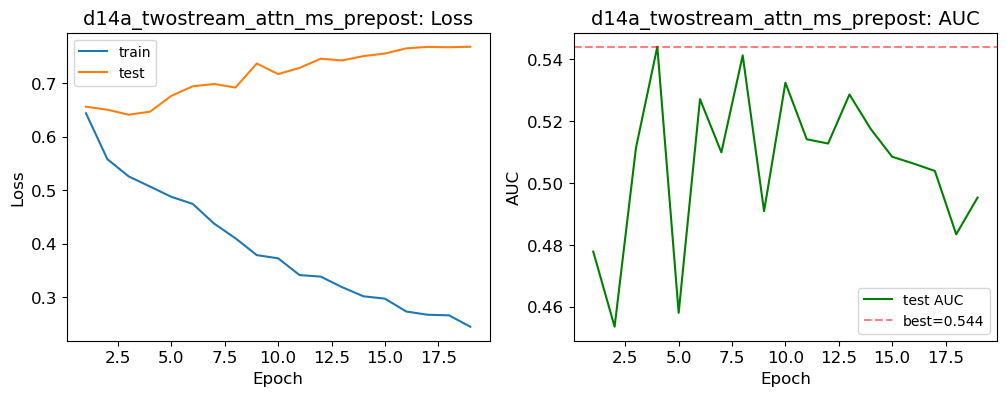

  Plot: d14a_twostream_attn_ms_prepost_curves_20260622_194347.png
  REG: d14a_twostream_attn_ms_prepost                AUC=0.5441 F1=? n=None feat=0 cities=0 [NB09d/cell_d14a]
    saved oof -> oof_d14a_twostream_attn_ms_prepost__20260621_232712_213609.parquet  TP=0 FN=0 FP=8 TN=654

  === d14a_twostream_attn_card_prepost (4ch, pre=[0, 1], post=[2, 3]) ===
  train: 1693 patches (pre+post, norm=/1.0, multi-city (21 dirs))
  test: 662 patches (pre+post, norm=/1.0, multi-city (21 dirs))
    Backbone: resnet34, params: 46.8M
    Cached: d14a_twostream_attn_card_prepost.pt
    Best AUC (cached): 0.5354


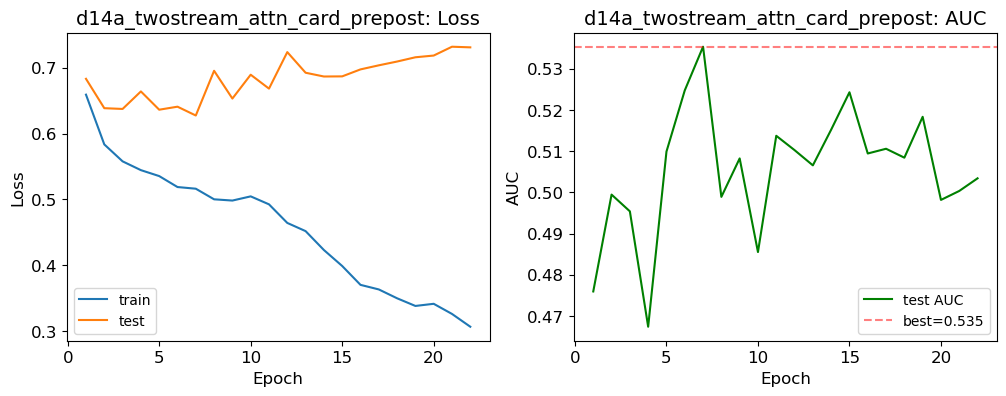

  Plot: d14a_twostream_attn_card_prepost_curves_20260622_194535.png
  REG: d14a_twostream_attn_card_prepost              AUC=0.5354 F1=? n=None feat=0 cities=0 [NB09d/cell_d14a]
    saved oof -> oof_d14a_twostream_attn_card_prepost__20260621_232712_213609.parquet  TP=0 FN=0 FP=0 TN=662

  === d14a_twostream_attn_fusion_prepost (10ch, pre=[0, 1, 2, 6, 7], post=[3, 4, 5, 8, 9]) ===
  train: 1693 patches (fusion, norm=ms/10000.0, card/1.0, multi-city (21 dirs))
  test: 662 patches (fusion, norm=ms/10000.0, card/1.0, multi-city (21 dirs))
    Backbone: resnet34, params: 46.8M
    Cached: d14a_twostream_attn_fusion_prepost.pt
    Best AUC (cached): 0.6037


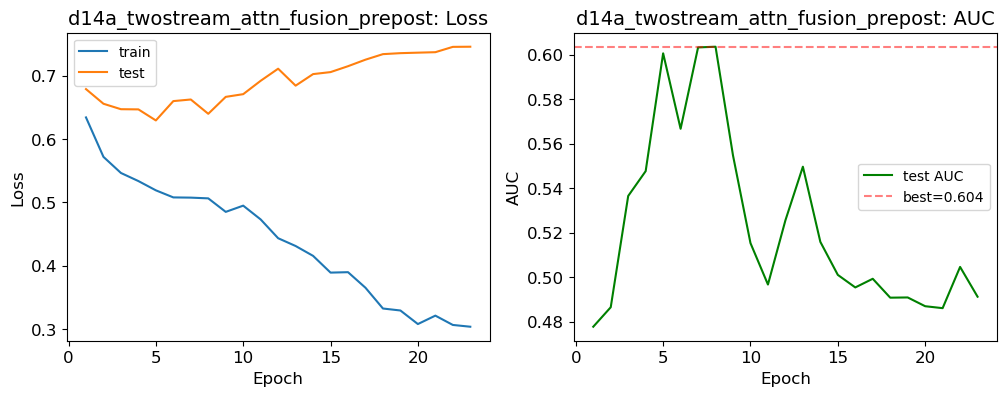

  Plot: d14a_twostream_attn_fusion_prepost_curves_20260622_194722.png
  REG: d14a_twostream_attn_fusion_prepost            AUC=0.6037 F1=? n=None feat=0 cities=0 [NB09d/cell_d14a]
    saved oof -> oof_d14a_twostream_attn_fusion_prepost__20260621_232712_213609.parquet  TP=0 FN=0 FP=5 TN=657

  D14a done.


In [32]:
# @title CELL D14a: ADRIANO TWO-STREAM ATTENTION U-NET SWEEP
print("=" * 70)
print("CELL D14a: ADRIANO TWO-STREAM ATTENTION U-NET (per pre+post modality)")
print("=" * 70)

D14A_BACKBONE = 'resnet34'  # change to 'se_resnext50_32x4d' to match Wu best single model

if not EXPERIMENT_CONFIGS:
    print("  EXPERIMENT_CONFIGS empty (run Cell 1a first)")
else:
    for cfg_name, split in PAPER_CHANNEL_SPLITS.items():
        cfg = EXPERIMENT_CONFIGS.get(cfg_name)
        if cfg is None:
            print(f"\n  SKIP d14a_{cfg_name}: EXPERIMENT_CONFIGS['{cfg_name}'] missing")
            continue
        n_ch = cfg['in_channels']
        if n_ch != len(split['pre']) + len(split['post']):
            print(f"\n  SKIP d14a_{cfg_name}: channel count mismatch "
                  f"(cfg in_channels={n_ch}, pre+post={len(split['pre'])+len(split['post'])})")
            continue
        exp_name = f"d14a_twostream_attn_{cfg_name}"
        print(f"\n  === {exp_name} ({n_ch}ch, pre={split['pre']}, post={split['post']}) ===")
        try:
            _nr = cfg.get('normalize_range', 10000.0)
            _cnr = cfg.get('card_normalize_range')
            ds_train = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                                  'train', cfg['channels'], PATCH_SPLIT, 1,
                                  normalize_range=_nr, post_only=cfg['post_only'],
                                  patch_dir_card=cfg['card_patch_dir'],
                                  card_normalize_range=_cnr)
            ds_test  = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                                  'test',  cfg['channels'], PATCH_SPLIT, 1,
                                  normalize_range=_nr, post_only=cfg['post_only'],
                                  patch_dir_card=cfg['card_patch_dir'],
                                  card_normalize_range=_cnr)
            if len(ds_train) == 0 or len(ds_test) == 0:
                print(f"    SKIP: train={len(ds_train)} test={len(ds_test)}")
                continue
            dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
            dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            model = TwoStreamAttnUNet(
                pre_indices=split['pre'], post_indices=split['post'],
                encoder_name=D14A_BACKBONE,
                encoder_weights='imagenet', classes=1, use_attention=True).to(DEVICE)
            n_params = sum(p.numel() for p in model.parameters())
            print(f"    Backbone: {D14A_BACKBONE}, params: {n_params/1e6:.1f}M")

            mp = MODEL_DIR / f"{exp_name}.pt"
            hp = RESULTS_DIR / f"{exp_name}_history.json"
            if mp.exists() and not FORCE_RERUN_TRAINING:
                print(f"    Cached: {mp.name}")
                if hp.exists():
                    with open(hp) as f: _h = json.load(f)
                    best = max(_h['test_auc'])
                    print(f"    Best AUC (cached): {best:.4f}")
                    plot_history(_h, exp_name)
                    RESULTS_ALL[exp_name] = {'auc': best}
                    log_dl(exp_name, best, cell_id='cell_d14a',
                           note=f'Adriano two-stream Attn U-Net cached on {cfg_name}',
                           tags=['dl','adriano','two_stream','attention',cfg_name,'cached'])
                    model.load_state_dict(torch.load(mp, map_location=DEVICE))
                    extract_unet_oof(model, ds_test, DEVICE, exp_name,
                                     variant_id=f'two_stream_attn;backbone={D14A_BACKBONE};modality={cfg_name};cached')
                del model; gc.collect(); torch.cuda.empty_cache()
                continue

            opt = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
            sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
            h, best_auc = train_model(model, dl_train, dl_test, criterion, opt, sch,
                                      NUM_EPOCHS_BDA, DEVICE, mp, EARLY_STOP_PATIENCE)
            with open(hp, 'w') as f: json.dump(h, f, indent=2)
            plot_history(h, exp_name)
            RESULTS_ALL[exp_name] = {'auc': best_auc}
            log_dl(exp_name, best_auc, cell_id='cell_d14a',
                   note=f'Adriano two-stream Attn U-Net on {cfg_name}',
                   tags=['dl','adriano','two_stream','attention',cfg_name])
            try:
                model.load_state_dict(torch.load(mp, map_location=DEVICE))
                extract_unet_oof(model, ds_test, DEVICE, exp_name,
                                 variant_id=f'two_stream_attn;backbone={D14A_BACKBONE};modality={cfg_name}')
            except Exception as e:
                print(f"    OOF extract skipped: {e}")
            del model; gc.collect(); torch.cuda.empty_cache()
        except Exception as e:
            print(f"    FAILED: {e}")

print("\n  D14a done.")


# D14b: RESCUENET-LITE (DeepLabV3+ post stream + change-detection head on feature diff)

Replicates Gupta and Shah 2021 RescueNet's two architectural innovations:

- a dilated ResNet50 + ASPP backbone (smp.DeepLabV3Plus is the same architecture)
- a change-detection head that consumes (feats_post - feats_pre) and is upsampled
  to full resolution; the final logits are the average of the segmentation head
  and the change head.

Trained with the LocalizationAwareBCEDiceLoss (binary BDA collapse of RescueNet's eq.1).
Sweeps the same three pre+post modalities (ms / card / fusion).


CELL D14b: RESCUENET-LITE (DeepLabV3+ + change-detection head)

  === d14b_rescuenet_ms_prepost (6ch, pre=[0, 1, 2], post=[3, 4, 5]) ===
  train: 1693 patches (pre+post, norm=/10000.0, multi-city (21 dirs))
  test: 662 patches (pre+post, norm=/10000.0, multi-city (21 dirs))
    Backbone: resnet50 (DeepLabV3+ ASPP), params: 32.0M
    Cached: d14b_rescuenet_ms_prepost.pt
    Best AUC (cached): 0.5138


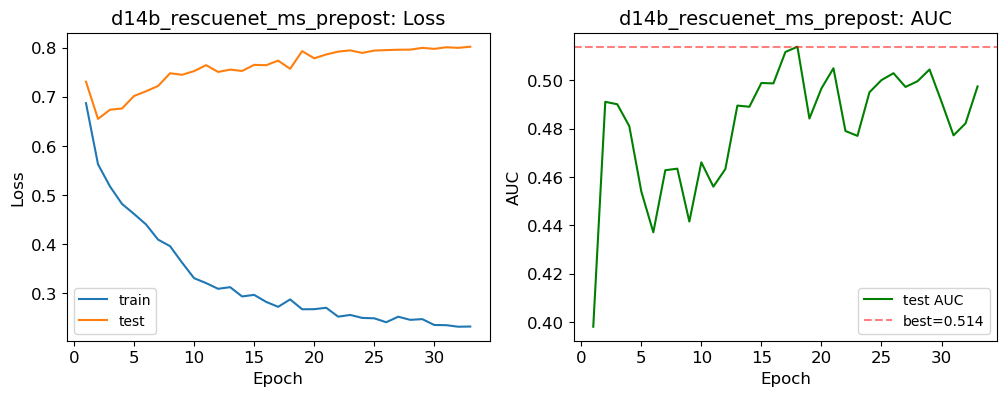

  Plot: d14b_rescuenet_ms_prepost_curves_20260622_194905.png
  REG: d14b_rescuenet_ms_prepost                     AUC=0.5138 F1=? n=None feat=0 cities=0 [NB09d/cell_d14b]
    saved oof -> oof_d14b_rescuenet_ms_prepost__20260621_232712_213609.parquet  TP=0 FN=0 FP=0 TN=662

  === d14b_rescuenet_card_prepost (4ch, pre=[0, 1], post=[2, 3]) ===
  train: 1693 patches (pre+post, norm=/1.0, multi-city (21 dirs))
  test: 662 patches (pre+post, norm=/1.0, multi-city (21 dirs))
    Backbone: resnet50 (DeepLabV3+ ASPP), params: 32.0M
    Cached: d14b_rescuenet_card_prepost.pt
    Best AUC (cached): 0.5293


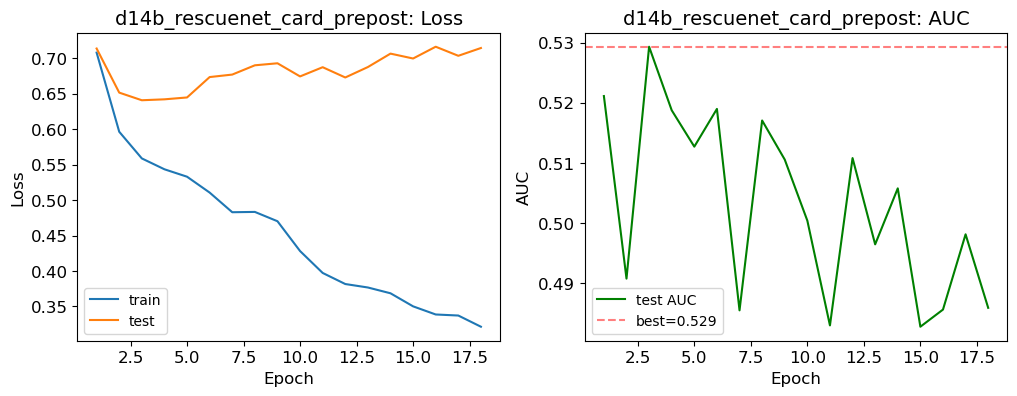

  Plot: d14b_rescuenet_card_prepost_curves_20260622_195041.png
  REG: d14b_rescuenet_card_prepost                   AUC=0.5293 F1=? n=None feat=0 cities=0 [NB09d/cell_d14b]
    saved oof -> oof_d14b_rescuenet_card_prepost__20260621_232712_213609.parquet  TP=0 FN=0 FP=0 TN=662

  === d14b_rescuenet_fusion_prepost (10ch, pre=[0, 1, 2, 6, 7], post=[3, 4, 5, 8, 9]) ===
  train: 1693 patches (fusion, norm=ms/10000.0, card/1.0, multi-city (21 dirs))
  test: 662 patches (fusion, norm=ms/10000.0, card/1.0, multi-city (21 dirs))
    Backbone: resnet50 (DeepLabV3+ ASPP), params: 32.0M
    Cached: d14b_rescuenet_fusion_prepost.pt
    Best AUC (cached): 0.5463


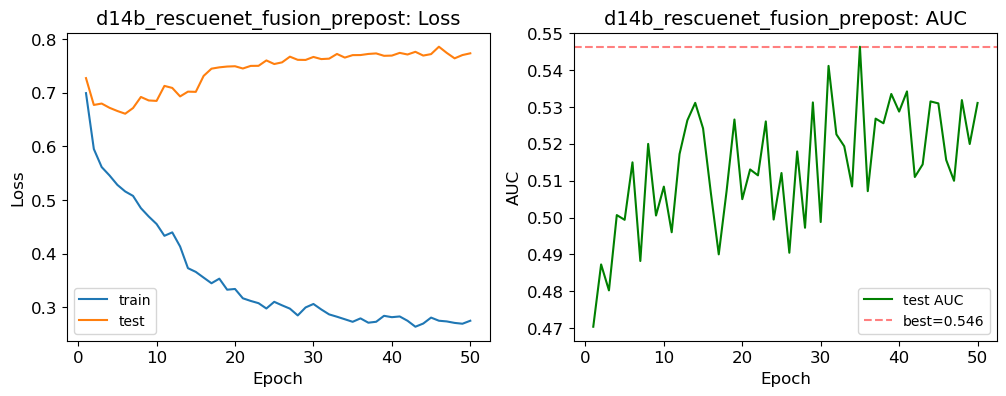

  Plot: d14b_rescuenet_fusion_prepost_curves_20260622_195231.png
  REG: d14b_rescuenet_fusion_prepost                 AUC=0.5463 F1=? n=None feat=0 cities=0 [NB09d/cell_d14b]
    saved oof -> oof_d14b_rescuenet_fusion_prepost__20260621_232712_213609.parquet  TP=0 FN=0 FP=0 TN=662

  D14b done.


In [33]:
# @title CELL D14b: RESCUENET-LITE SWEEP (DeepLabV3+ + change-diff head + loc-aware loss)
print("=" * 70)
print("CELL D14b: RESCUENET-LITE (DeepLabV3+ + change-detection head)")
print("=" * 70)

D14B_BACKBONE = 'resnet50'  # RescueNet uses dilated ResNet50
loc_aware_criterion = LocalizationAwareBCEDiceLoss(bce_weight=0.5, dice_weight=0.5, bg_weight=0.1)

if not EXPERIMENT_CONFIGS:
    print("  EXPERIMENT_CONFIGS empty (run Cell 1a first)")
else:
    for cfg_name, split in PAPER_CHANNEL_SPLITS.items():
        cfg = EXPERIMENT_CONFIGS.get(cfg_name)
        if cfg is None:
            print(f"\n  SKIP d14b_{cfg_name}: EXPERIMENT_CONFIGS['{cfg_name}'] missing")
            continue
        n_ch = cfg['in_channels']
        if n_ch != len(split['pre']) + len(split['post']):
            print(f"\n  SKIP d14b_{cfg_name}: channel count mismatch")
            continue
        exp_name = f"d14b_rescuenet_{cfg_name}"
        print(f"\n  === {exp_name} ({n_ch}ch, pre={split['pre']}, post={split['post']}) ===")
        try:
            _nr = cfg.get('normalize_range', 10000.0)
            _cnr = cfg.get('card_normalize_range')
            ds_train = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                                  'train', cfg['channels'], PATCH_SPLIT, 1,
                                  normalize_range=_nr, post_only=cfg['post_only'],
                                  patch_dir_card=cfg['card_patch_dir'],
                                  card_normalize_range=_cnr)
            ds_test  = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                                  'test',  cfg['channels'], PATCH_SPLIT, 1,
                                  normalize_range=_nr, post_only=cfg['post_only'],
                                  patch_dir_card=cfg['card_patch_dir'],
                                  card_normalize_range=_cnr)
            if len(ds_train) == 0 or len(ds_test) == 0:
                print(f"    SKIP: train={len(ds_train)} test={len(ds_test)}")
                continue
            dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
            dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            model = RescueNetLite(
                pre_indices=split['pre'], post_indices=split['post'],
                encoder_name=D14B_BACKBONE,
                encoder_weights='imagenet', classes=1).to(DEVICE)
            n_params = sum(p.numel() for p in model.parameters())
            print(f"    Backbone: {D14B_BACKBONE} (DeepLabV3+ ASPP), params: {n_params/1e6:.1f}M")

            mp = MODEL_DIR / f"{exp_name}.pt"
            hp = RESULTS_DIR / f"{exp_name}_history.json"
            if mp.exists() and not FORCE_RERUN_TRAINING:
                print(f"    Cached: {mp.name}")
                if hp.exists():
                    with open(hp) as f: _h = json.load(f)
                    best = max(_h['test_auc'])
                    print(f"    Best AUC (cached): {best:.4f}")
                    plot_history(_h, exp_name)
                    RESULTS_ALL[exp_name] = {'auc': best}
                    log_dl(exp_name, best, cell_id='cell_d14b',
                           note=f'RescueNet-lite cached on {cfg_name}',
                           tags=['dl','rescuenet','deeplabv3plus','change_head',cfg_name,'cached'])
                    model.load_state_dict(torch.load(mp, map_location=DEVICE))
                    extract_unet_oof(model, ds_test, DEVICE, exp_name,
                                     variant_id=f'rescuenet_lite;backbone={D14B_BACKBONE};modality={cfg_name};cached')
                del model; gc.collect(); torch.cuda.empty_cache()
                continue

            opt = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
            sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
            h, best_auc = train_model(model, dl_train, dl_test, loc_aware_criterion, opt, sch,
                                      NUM_EPOCHS_BDA, DEVICE, mp, EARLY_STOP_PATIENCE)
            with open(hp, 'w') as f: json.dump(h, f, indent=2)
            plot_history(h, exp_name)
            RESULTS_ALL[exp_name] = {'auc': best_auc}
            log_dl(exp_name, best_auc, cell_id='cell_d14b',
                   note=f'RescueNet-lite (DeepLabV3+ + change-diff head + loc-aware loss) on {cfg_name}',
                   tags=['dl','rescuenet','deeplabv3plus','change_head','loc_aware_loss',cfg_name])
            try:
                model.load_state_dict(torch.load(mp, map_location=DEVICE))
                extract_unet_oof(model, ds_test, DEVICE, exp_name,
                                 variant_id=f'rescuenet_lite;backbone={D14B_BACKBONE};modality={cfg_name}')
            except Exception as e:
                print(f"    OOF extract skipped: {e}")
            del model; gc.collect(); torch.cuda.empty_cache()
        except Exception as e:
            print(f"    FAILED: {e}")

print("\n  D14b done.")


# D14c: WU et al. BACKBONE SWEEP (two-stream Attn U-Net x backbones)

Wu et al. 2021 sweeps four backbones (ResNet-34, SE-ResNeXt, DPN, SENet) on a
Siamese U-Net with attention gates. Here we run the same sweep on the
TwoStreamAttnUNet defined in D14, on the strongest pre+post modality
(fusion_prepost = 10ch optical+SAR). DPN is omitted because its smp encoder
needs special weights download; the other three backbones cover Wu's main
comparison.


In [34]:
# @title CELL D14c: WU et al BACKBONE SWEEP ON TWO-STREAM ATTN U-NET
print("=" * 70)
print("CELL D14c: WU et al BACKBONE SWEEP (two-stream Attn U-Net)")
print("=" * 70)

D14C_MODALITY = 'fusion_prepost'  # change to 'ms_prepost' if MS-only desired
D14C_BACKBONES = [
    'resnet34',
    'se_resnext50_32x4d',  # Wu's SEResNeXt
    'senet154',            # Wu's SENet
]

split = PAPER_CHANNEL_SPLITS.get(D14C_MODALITY)
cfg   = EXPERIMENT_CONFIGS.get(D14C_MODALITY) if EXPERIMENT_CONFIGS else None
if split is None or cfg is None:
    print(f"  SKIP: '{D14C_MODALITY}' not available in EXPERIMENT_CONFIGS / PAPER_CHANNEL_SPLITS")
else:
    n_ch = cfg['in_channels']
    print(f"  Modality: {D14C_MODALITY} ({n_ch}ch), pre={split['pre']}, post={split['post']}")

    _nr = cfg.get('normalize_range', 10000.0)
    _cnr = cfg.get('card_normalize_range')
    ds_train = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                          'train', cfg['channels'], PATCH_SPLIT, 1,
                          normalize_range=_nr, post_only=cfg['post_only'],
                          patch_dir_card=cfg['card_patch_dir'],
                          card_normalize_range=_cnr)
    ds_test  = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                          'test',  cfg['channels'], PATCH_SPLIT, 1,
                          normalize_range=_nr, post_only=cfg['post_only'],
                          patch_dir_card=cfg['card_patch_dir'],
                          card_normalize_range=_cnr)
    if len(ds_train) == 0 or len(ds_test) == 0:
        print(f"  SKIP: train={len(ds_train)} test={len(ds_test)}")
    else:
        dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
        dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

        d14c_results = {}
        for backbone in D14C_BACKBONES:
            exp_name = f"d14c_twostream_attn_{D14C_MODALITY}_{backbone.replace('-','_')}"
            print(f"\n  --- {exp_name} ---")
            try:
                model = TwoStreamAttnUNet(
                    pre_indices=split['pre'], post_indices=split['post'],
                    encoder_name=backbone,
                    encoder_weights='imagenet', classes=1, use_attention=True).to(DEVICE)
                n_params = sum(p.numel() for p in model.parameters())
                print(f"    Backbone: {backbone}, params: {n_params/1e6:.1f}M")

                mp = MODEL_DIR / f"{exp_name}.pt"
                hp = RESULTS_DIR / f"{exp_name}_history.json"
                if mp.exists() and not FORCE_RERUN_TRAINING:
                    if hp.exists():
                        with open(hp) as f: _h = json.load(f)
                        best = max(_h['test_auc'])
                        d14c_results[backbone] = {'auc': best, 'n_params_M': n_params/1e6, 'cached': True}
                        print(f"    Cached AUC: {best:.4f}")
                        RESULTS_ALL[exp_name] = {'auc': best}
                        log_dl(exp_name, best, cell_id='cell_d14c',
                               note=f'Wu sweep cached: {backbone} on {D14C_MODALITY}',
                               tags=['dl','wu','backbone_sweep','two_stream',backbone,D14C_MODALITY,'cached'])
                    del model; gc.collect(); torch.cuda.empty_cache()
                    continue

                opt = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
                sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
                h, best_auc = train_model(model, dl_train, dl_test, criterion, opt, sch,
                                          NUM_EPOCHS_BDA, DEVICE, mp, EARLY_STOP_PATIENCE)
                with open(hp, 'w') as f: json.dump(h, f, indent=2)
                plot_history(h, exp_name)
                RESULTS_ALL[exp_name] = {'auc': best_auc}
                log_dl(exp_name, best_auc, cell_id='cell_d14c',
                       note=f'Wu sweep: {backbone} on {D14C_MODALITY}',
                       tags=['dl','wu','backbone_sweep','two_stream',backbone,D14C_MODALITY])
                d14c_results[backbone] = {'auc': best_auc, 'n_params_M': n_params/1e6}
                try:
                    model.load_state_dict(torch.load(mp, map_location=DEVICE))
                    extract_unet_oof(model, ds_test, DEVICE, exp_name,
                                     variant_id=f'two_stream_attn;backbone={backbone};modality={D14C_MODALITY}')
                except Exception as e:
                    print(f"    OOF extract skipped: {e}")
                del model; gc.collect(); torch.cuda.empty_cache()
            except Exception as e:
                print(f"    FAILED: {e}")
                d14c_results[backbone] = {'auc': 0, 'note': f'FAILED: {e}'}

        if d14c_results:
            print(f"\n  {'Backbone':30s} {'AUC':>7s} {'Params':>10s}")
            for k, r in sorted(d14c_results.items(), key=lambda x: -x[1].get('auc', 0)):
                print(f"  {k:30s} {r.get('auc',0):7.3f} {r.get('n_params_M',0):8.1f}M")
            d14c_df = pd.DataFrame([{'backbone': k, **v} for k, v in d14c_results.items()])
            save_result(d14c_df, 'd14c_wu_backbone_sweep', 'cell_d14c')

print("\n  D14c done.")


CELL D14c: WU et al BACKBONE SWEEP (two-stream Attn U-Net)
  Modality: fusion_prepost (10ch), pre=[0, 1, 2, 6, 7], post=[3, 4, 5, 8, 9]
  train: 1693 patches (fusion, norm=ms/10000.0, card/1.0, multi-city (21 dirs))
  test: 662 patches (fusion, norm=ms/10000.0, card/1.0, multi-city (21 dirs))

  --- d14c_twostream_attn_fusion_prepost_resnet34 ---
    Backbone: resnet34, params: 46.8M
    Cached AUC: 0.5905
  REG: d14c_twostream_attn_fusion_prepost_resnet34   AUC=0.5905 F1=? n=None feat=0 cities=0 [NB09d/cell_d14c]

  --- d14c_twostream_attn_fusion_prepost_se_resnext50_32x4d ---
    Backbone: se_resnext50_32x4d, params: 77.5M
    Cached AUC: 0.5858
  REG: d14c_twostream_attn_fusion_prepost_se_resnext50_32x4d AUC=0.5858 F1=? n=None feat=0 cities=0 [NB09d/cell_d14c]

  --- d14c_twostream_attn_fusion_prepost_senet154 ---
    Backbone: senet154, params: 252.6M
    Cached AUC: 0.6002
  REG: d14c_twostream_attn_fusion_prepost_senet154   AUC=0.6002 F1=? n=None feat=0 cities=0 [NB09d/cell_d14c]

# D15: STEP A -- xBD-on-xBD pretraining for adriano / rescuenet / wu_sweep

Defines XBDPrePostDataset (loads xBD pre+post 3-channel pairs as a 6-channel
[pre_RGB, post_RGB] stack matching BDADataset's ms_prepost layout) and runs
xBD pretraining for:

- adriano / wu_sweep: TwoStreamAttnUNet on backbones [resnet34, se_resnext50_32x4d, senet154]
- rescuenet: RescueNetLite on resnet50

Each pretrain finishes by evaluating on xBD val (the canonical "xBD-on-xBD" metric)
and stores the checkpoint at MODEL_DIR/d15_xbd_pretrain_<variant>_<backbone>.pt
for use by D16. vanilla step A is already done in cells 21 and 22 (D1).


In [35]:
# @title CELL D15: STEP A -- xBD PRETRAIN FOR adriano/rescuenet/wu_sweep + EVAL ON xBD VAL
# =============================================================================
# Pretrains paper architectures on xBD pre+post pairs (6ch RGB) and evaluates
# on xBD val. Outputs:
#   MODEL_DIR / d15_xbd_pretrain_twostream_<backbone>.pt    (adriano + wu_sweep)
#   MODEL_DIR / d15_xbd_pretrain_rescuenet_resnet50.pt      (rescuenet)
# =============================================================================
print("=" * 70)
print("CELL D15: STEP A -- xBD PRETRAIN FOR PAPER ARCHITECTURES")
print("=" * 70)


class XBDPrePostDataset(Dataset):
    """xBD pre+post 3-channel RGB pairs returned as a 6-channel concatenated
    [pre_RGB, post_RGB] tensor matching the BDADataset ms_prepost layout.
    Mask convention follows XBDDataset: target=1 if mask>=2 (damaged),
    weight=1 if mask>=1 (any building).
    """
    def __init__(self, xbd_root, split='train'):
        self.samples = []
        idir = Path(xbd_root) / split / 'images'
        mdir = Path(xbd_root) / split / 'labels'
        if idir.exists() and mdir.exists():
            for ip_post in sorted(idir.glob("*_post_disaster.png")):
                ip_pre = idir / ip_post.name.replace('_post_disaster.png', '_pre_disaster.png')
                mp = mdir / ip_post.name
                if ip_pre.exists() and mp.exists():
                    self.samples.append((ip_pre, ip_post, mp))
        print(f"  xBD prepost {split}: {len(self.samples)} pairs")
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        ip_pre, ip_post, mp = self.samples[idx]
        pre = np.array(Image.open(ip_pre))
        post = np.array(Image.open(ip_post))
        if pre.ndim == 2:  pre  = np.stack([pre]*3, axis=-1)
        if post.ndim == 2: post = np.stack([post]*3, axis=-1)
        pre  = pre[:, :, :3].transpose(2, 0, 1).astype(np.float32) / 255.0
        post = post[:, :, :3].transpose(2, 0, 1).astype(np.float32) / 255.0
        img = np.concatenate([pre, post], axis=0)  # 6ch [RGB_pre, RGB_post]
        mask = np.array(Image.open(mp))
        target = (mask >= 2).astype(np.float32)
        weight = (mask >= 1).astype(np.float32)
        return (torch.from_numpy(img),
                torch.from_numpy(target).unsqueeze(0),
                torch.from_numpy(weight).unsqueeze(0))


# --- variant pretrain plan ---
# adriano + wu_sweep: same TwoStreamAttnUNet, sweep backbones
D15_TWOSTREAM_BACKBONES = ['resnet34', 'se_resnext50_32x4d', 'senet154']
D15_PREPOST_PRE  = [0, 1, 2]   # xBD pre RGB
D15_PREPOST_POST = [3, 4, 5]   # xBD post RGB

xbd_pp_train = XBDPrePostDataset(XBD_DL_ROOT, 'train')
xbd_pp_val   = XBDPrePostDataset(XBD_DL_ROOT, 'val')
d15_skip = (len(xbd_pp_train) == 0)

if d15_skip:
    print("  SKIP: no xBD pre+post pairs found")
else:
    dl_xbd_train = DataLoader(xbd_pp_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)
    dl_xbd_val   = DataLoader(xbd_pp_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    # ----- adriano / wu_sweep: TwoStreamAttnUNet, sweep backbones -----
    for backbone in D15_TWOSTREAM_BACKBONES:
        exp_name = f"d15_xbd_pretrain_twostream_{backbone}"
        print(f"\n  === adriano / wu_sweep step A | {exp_name} ===")
        try:
            model = TwoStreamAttnUNet(
                pre_indices=D15_PREPOST_PRE, post_indices=D15_PREPOST_POST,
                encoder_name=backbone, encoder_weights='imagenet',
                classes=1, use_attention=True).to(DEVICE)
            n_params = sum(p.numel() for p in model.parameters())
            print(f"    Backbone: {backbone}, params: {n_params/1e6:.1f}M")

            mp = MODEL_DIR / f"{exp_name}.pt"
            hp = RESULTS_DIR / f"{exp_name}_history.json"
            if mp.exists() and not FORCE_RERUN_TRAINING:
                print(f"    Cached: {mp.name}")
                if hp.exists():
                    with open(hp) as f: _h = json.load(f)
                    best = max(_h['test_auc'])
                    print(f"    xBD val AUC (cached): {best:.4f}")
                    RESULTS_ALL[f'{exp_name}_xbd_on_xbd'] = {'auc': best}
                    log_dl(f'{exp_name}_xbd_on_xbd', best, cell_id='cell_d15',
                           note=f'adriano / wu_sweep step A xBD-on-xBD cached ({backbone})',
                           tags=['dl','step_a','xbd_on_xbd','two_stream','adriano','wu',backbone,'cached'])
                del model; gc.collect(); torch.cuda.empty_cache()
                continue

            opt = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
            sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
            h, best_auc = train_model(model, dl_xbd_train, dl_xbd_val, criterion, opt, sch,
                                      NUM_EPOCHS_XBD, DEVICE, mp, EARLY_STOP_PATIENCE)
            with open(hp, 'w') as f: json.dump(h, f, indent=2)
            plot_history(h, exp_name)
            RESULTS_ALL[f'{exp_name}_xbd_on_xbd'] = {'auc': best_auc}
            log_dl(f'{exp_name}_xbd_on_xbd', best_auc, cell_id='cell_d15',
                   note=f'adriano / wu_sweep step A xBD-on-xBD ({backbone})',
                   tags=['dl','step_a','xbd_on_xbd','two_stream','adriano','wu',backbone])
            del model; gc.collect(); torch.cuda.empty_cache()
        except Exception as e:
            print(f"    FAILED: {e}")

    # ----- rescuenet: RescueNetLite (resnet50 + DeepLabV3+) -----
    exp_name = "d15_xbd_pretrain_rescuenet_resnet50"
    print(f"\n  === rescuenet step A | {exp_name} ===")
    try:
        model = RescueNetLite(
            pre_indices=D15_PREPOST_PRE, post_indices=D15_PREPOST_POST,
            encoder_name='resnet50', encoder_weights='imagenet', classes=1).to(DEVICE)
        n_params = sum(p.numel() for p in model.parameters())
        print(f"    Backbone: resnet50 (DeepLabV3+ ASPP), params: {n_params/1e6:.1f}M")

        mp = MODEL_DIR / f"{exp_name}.pt"
        hp = RESULTS_DIR / f"{exp_name}_history.json"
        if mp.exists() and not FORCE_RERUN_TRAINING:
            print(f"    Cached: {mp.name}")
            if hp.exists():
                with open(hp) as f: _h = json.load(f)
                best = max(_h['test_auc'])
                print(f"    xBD val AUC (cached): {best:.4f}")
                RESULTS_ALL[f'{exp_name}_xbd_on_xbd'] = {'auc': best}
                log_dl(f'{exp_name}_xbd_on_xbd', best, cell_id='cell_d15',
                       note='rescuenet step A xBD-on-xBD cached (RescueNet-lite)',
                       tags=['dl','step_a','xbd_on_xbd','rescuenet','gupta_shah','cached'])
            del model; gc.collect(); torch.cuda.empty_cache()
        else:
            opt = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
            sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
            # use the localization-aware loss as in D14b
            h, best_auc = train_model(model, dl_xbd_train, dl_xbd_val, loc_aware_criterion, opt, sch,
                                      NUM_EPOCHS_XBD, DEVICE, mp, EARLY_STOP_PATIENCE)
            with open(hp, 'w') as f: json.dump(h, f, indent=2)
            plot_history(h, exp_name)
            RESULTS_ALL[f'{exp_name}_xbd_on_xbd'] = {'auc': best_auc}
            log_dl(f'{exp_name}_xbd_on_xbd', best_auc, cell_id='cell_d15',
                   note='rescuenet step A xBD-on-xBD (RescueNet-lite)',
                   tags=['dl','step_a','xbd_on_xbd','rescuenet','gupta_shah'])
            del model; gc.collect(); torch.cuda.empty_cache()
    except Exception as e:
        print(f"    FAILED: {e}")

print("\n  D15 done. Pretrained checkpoints saved for D16 finetune step.")


CELL D15: STEP A -- xBD PRETRAIN FOR PAPER ARCHITECTURES
  xBD prepost train: 4849 pairs
  xBD prepost val: 1060 pairs

  === adriano / wu_sweep step A | d15_xbd_pretrain_twostream_resnet34 ===
    Backbone: resnet34, params: 46.8M
    Cached: d15_xbd_pretrain_twostream_resnet34.pt
    xBD val AUC (cached): 0.9712
  REG: d15_xbd_pretrain_twostream_resnet34_xbd_on_xbd AUC=0.9712 F1=? n=None feat=0 cities=0 [NB09d/cell_d15]

  === adriano / wu_sweep step A | d15_xbd_pretrain_twostream_se_resnext50_32x4d ===
    Backbone: se_resnext50_32x4d, params: 77.5M
    Cached: d15_xbd_pretrain_twostream_se_resnext50_32x4d.pt
    xBD val AUC (cached): 0.9788
  REG: d15_xbd_pretrain_twostream_se_resnext50_32x4d_xbd_on_xbd AUC=0.9788 F1=? n=None feat=0 cities=0 [NB09d/cell_d15]

  === adriano / wu_sweep step A | d15_xbd_pretrain_twostream_senet154 ===
    Backbone: senet154, params: 252.6M
    Cached: d15_xbd_pretrain_twostream_senet154.pt
    xBD val AUC (cached): 0.9757
  REG: d15_xbd_pretrain_twost

# D16: STEP C -- xBD pretrain + BDA finetune for adriano / rescuenet / wu_sweep

Loads each xBD-pretrained checkpoint produced by D15 and finetunes on the BDA
ms_prepost (6ch optical pre+post) modality. Lower learning rate (LEARNING_RATE * 0.1)
matches the vanilla finetune protocol in cell 32 (D5b).

Coverage:

- adriano / wu_sweep (TwoStreamAttnUNet across [resnet34, se_resnext50_32x4d, senet154])
- rescuenet (RescueNetLite, resnet50)

Note: xBD has only RGB, so the natural channel-matching modality for finetune
is ms_prepost (6ch). Extending step C to fusion_prepost (10ch with CARD) requires
channel surgery on the post-RGB and pre-RGB indices similar to
create_fusion_unet_from_xbd in Cell 0d.


CELL D16: STEP C -- xBD PRETRAIN + BDA FINETUNE
  Finetune modality: ms_prepost (6ch), pre=[0, 1, 2], post=[3, 4, 5]
  train: 1693 patches (pre+post, norm=/10000.0, multi-city (21 dirs))
  test: 662 patches (pre+post, norm=/10000.0, multi-city (21 dirs))

  === adriano / wu_sweep step C | d16_xbd_finetune_twostream_resnet34_ms_prepost ===
    Loaded xBD weights from d15_xbd_pretrain_twostream_resnet34.pt, params: 46.8M
    Cached: d16_xbd_finetune_twostream_resnet34_ms_prepost.pt
    BDA test AUC (cached): 0.5174


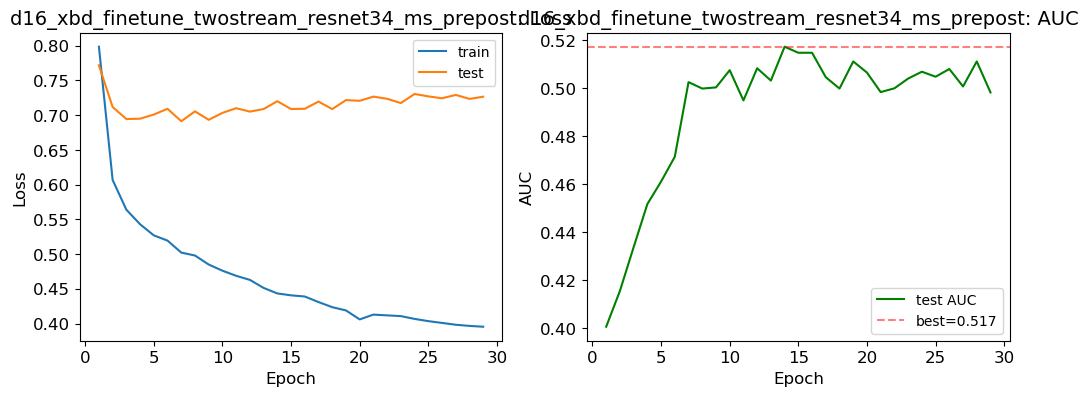

  Plot: d16_xbd_finetune_twostream_resnet34_ms_prepost_curves_20260622_195606.png
  REG: d16_xbd_finetune_twostream_resnet34_ms_prepost AUC=0.5174 F1=? n=None feat=0 cities=0 [NB09d/cell_d16]
    saved oof -> oof_d16_xbd_finetune_twostream_resnet34_ms_prepost__20260621_232712_213609.parquet  TP=0 FN=0 FP=29 TN=633

  === adriano / wu_sweep step C | d16_xbd_finetune_twostream_se_resnext50_32x4d_ms_prepost ===
    Loaded xBD weights from d15_xbd_pretrain_twostream_se_resnext50_32x4d.pt, params: 77.5M
    Cached: d16_xbd_finetune_twostream_se_resnext50_32x4d_ms_prepost.pt
    BDA test AUC (cached): 0.5048


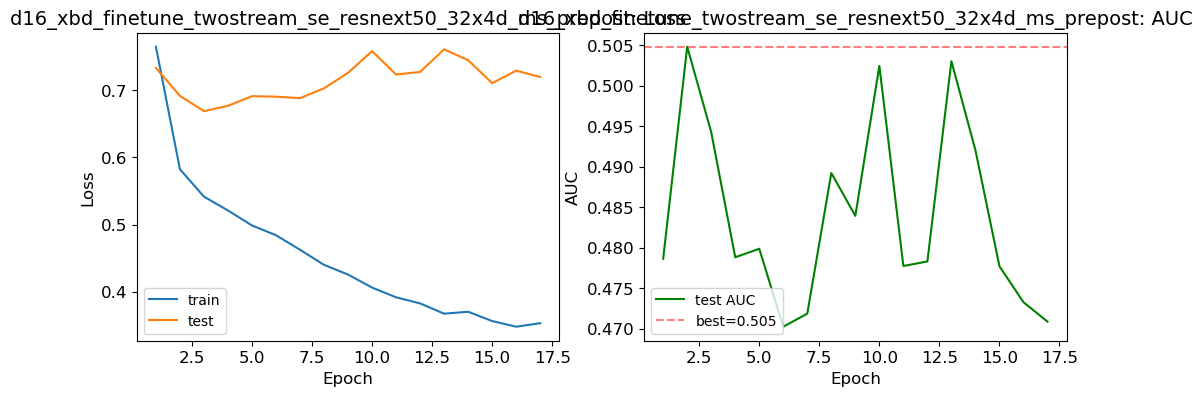

  Plot: d16_xbd_finetune_twostream_se_resnext50_32x4d_ms_prepost_curves_20260622_195716.png
  REG: d16_xbd_finetune_twostream_se_resnext50_32x4d_ms_prepost AUC=0.5048 F1=? n=None feat=0 cities=0 [NB09d/cell_d16]
    saved oof -> oof_d16_xbd_finetune_twostream_se_resnext50_32x4d_ms_prepost__20260621_232712_213609.parquet  TP=0 FN=0 FP=24 TN=638

  === adriano / wu_sweep step C | d16_xbd_finetune_twostream_senet154_ms_prepost ===
    Loaded xBD weights from d15_xbd_pretrain_twostream_senet154.pt, params: 252.6M
    Cached: d16_xbd_finetune_twostream_senet154_ms_prepost.pt
    BDA test AUC (cached): 0.4988


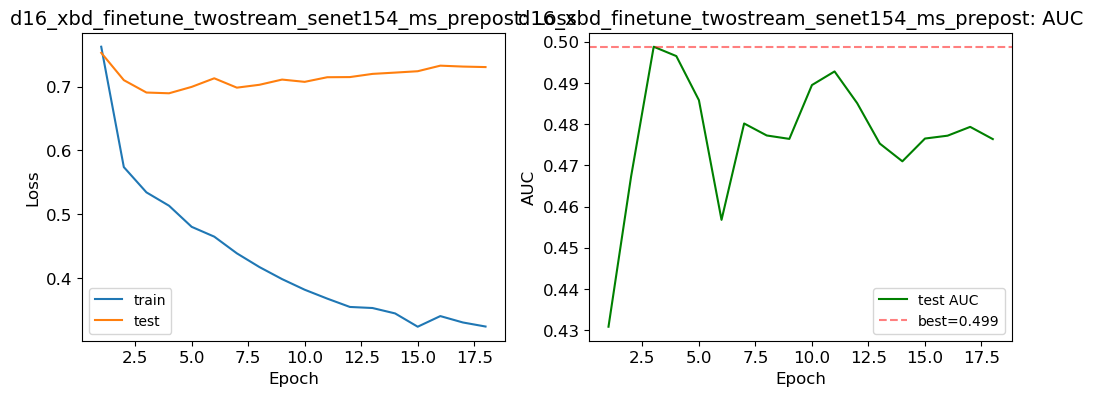

  Plot: d16_xbd_finetune_twostream_senet154_ms_prepost_curves_20260622_195931.png
  REG: d16_xbd_finetune_twostream_senet154_ms_prepost AUC=0.4988 F1=? n=None feat=0 cities=0 [NB09d/cell_d16]
    saved oof -> oof_d16_xbd_finetune_twostream_senet154_ms_prepost__20260621_232712_213609.parquet  TP=0 FN=0 FP=28 TN=634

  === rescuenet step C | d16_xbd_finetune_rescuenet_resnet50_ms_prepost ===
    Loaded xBD weights from d15_xbd_pretrain_rescuenet_resnet50.pt, params: 32.0M
    Cached: d16_xbd_finetune_rescuenet_resnet50_ms_prepost.pt
    BDA test AUC (cached): 0.6198


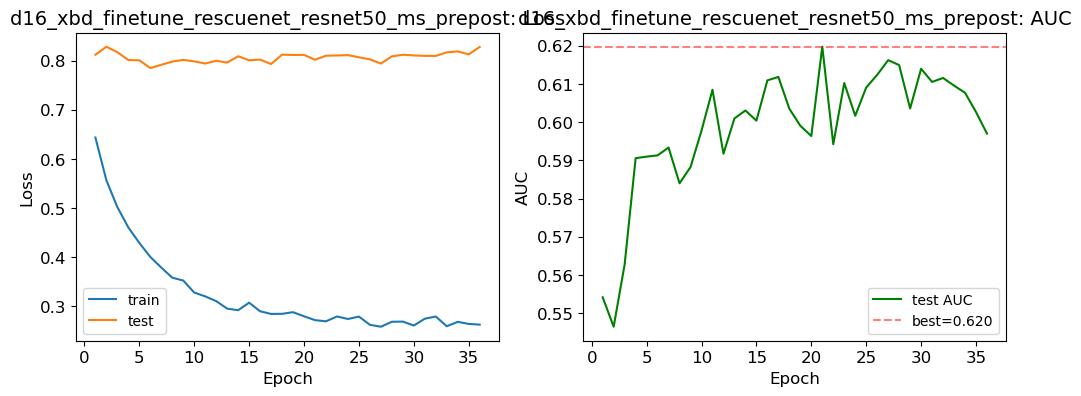

  Plot: d16_xbd_finetune_rescuenet_resnet50_ms_prepost_curves_20260622_200200.png
  REG: d16_xbd_finetune_rescuenet_resnet50_ms_prepost AUC=0.6198 F1=? n=None feat=0 cities=0 [NB09d/cell_d16]
    saved oof -> oof_d16_xbd_finetune_rescuenet_resnet50_ms_prepost__20260621_232712_213609.parquet  TP=0 FN=0 FP=0 TN=662

  D16 done.


In [36]:
# @title CELL D16: STEP C -- xBD PRETRAIN + BDA FINETUNE FOR adriano/rescuenet/wu_sweep
print("=" * 70)
print("CELL D16: STEP C -- xBD PRETRAIN + BDA FINETUNE")
print("=" * 70)

D16_MODALITY = 'ms_prepost'
D16_TWOSTREAM_BACKBONES = ['resnet34', 'se_resnext50_32x4d', 'senet154']

cfg = EXPERIMENT_CONFIGS.get(D16_MODALITY) if EXPERIMENT_CONFIGS else None
split = PAPER_CHANNEL_SPLITS.get(D16_MODALITY)
if cfg is None or split is None:
    print(f"  SKIP: '{D16_MODALITY}' missing in EXPERIMENT_CONFIGS / PAPER_CHANNEL_SPLITS")
else:
    n_ch = cfg['in_channels']
    print(f"  Finetune modality: {D16_MODALITY} ({n_ch}ch), pre={split['pre']}, post={split['post']}")
    _nr = cfg.get('normalize_range', 10000.0)
    _cnr = cfg.get('card_normalize_range')
    bda_train = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                           'train', cfg['channels'], PATCH_SPLIT, 1,
                           normalize_range=_nr, post_only=cfg['post_only'],
                           patch_dir_card=cfg['card_patch_dir'],
                           card_normalize_range=_cnr)
    bda_test  = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                           'test',  cfg['channels'], PATCH_SPLIT, 1,
                           normalize_range=_nr, post_only=cfg['post_only'],
                           patch_dir_card=cfg['card_patch_dir'],
                           card_normalize_range=_cnr)
    if len(bda_train) == 0 or len(bda_test) == 0:
        print(f"  SKIP: BDA train={len(bda_train)} test={len(bda_test)}")
    else:
        dl_bda_train = DataLoader(bda_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
        dl_bda_test  = DataLoader(bda_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        FT_LR = LEARNING_RATE * 0.1

        # ----- adriano / wu_sweep finetune -----
        for backbone in D16_TWOSTREAM_BACKBONES:
            exp_name = f"d16_xbd_finetune_twostream_{backbone}_{D16_MODALITY}"
            pretrain_ckpt = MODEL_DIR / f"d15_xbd_pretrain_twostream_{backbone}.pt"
            print(f"\n  === adriano / wu_sweep step C | {exp_name} ===")
            if not pretrain_ckpt.exists():
                print(f"    SKIP: missing xBD pretrain ckpt {pretrain_ckpt.name} (run D15 first)")
                continue
            try:
                model = TwoStreamAttnUNet(
                    pre_indices=split['pre'], post_indices=split['post'],
                    encoder_name=backbone, encoder_weights=None,
                    classes=1, use_attention=True)
                model.load_state_dict(torch.load(pretrain_ckpt, map_location='cpu'))
                model = model.to(DEVICE)
                n_params = sum(p.numel() for p in model.parameters())
                print(f"    Loaded xBD weights from {pretrain_ckpt.name}, params: {n_params/1e6:.1f}M")

                mp = MODEL_DIR / f"{exp_name}.pt"
                hp = RESULTS_DIR / f"{exp_name}_history.json"
                if mp.exists() and not FORCE_RERUN_TRAINING:
                    print(f"    Cached: {mp.name}")
                    if hp.exists():
                        with open(hp) as f: _h = json.load(f)
                        best = max(_h['test_auc'])
                        print(f"    BDA test AUC (cached): {best:.4f}")
                        plot_history(_h, exp_name)
                        RESULTS_ALL[exp_name] = {'auc': best}
                        log_dl(exp_name, best, cell_id='cell_d16',
                               note=f'adriano / wu_sweep step C xBD->BDA finetune cached ({backbone})',
                               tags=['dl','step_c','xbd_finetune','two_stream','adriano','wu',backbone,'cached'])
                        model.load_state_dict(torch.load(mp, map_location=DEVICE))
                        extract_unet_oof(model, bda_test, DEVICE, exp_name,
                                         variant_id=f'two_stream_attn_xbd_finetuned;backbone={backbone};modality={D16_MODALITY};cached')
                    del model; gc.collect(); torch.cuda.empty_cache()
                    continue

                opt = optim.AdamW(model.parameters(), lr=FT_LR, weight_decay=WEIGHT_DECAY)
                sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
                h, best_auc = train_model(model, dl_bda_train, dl_bda_test, criterion, opt, sch,
                                          NUM_EPOCHS_FINETUNE, DEVICE, mp, EARLY_STOP_PATIENCE)
                with open(hp, 'w') as f: json.dump(h, f, indent=2)
                plot_history(h, exp_name)
                RESULTS_ALL[exp_name] = {'auc': best_auc}
                log_dl(exp_name, best_auc, cell_id='cell_d16',
                       note=f'adriano / wu_sweep step C xBD->BDA finetune ({backbone})',
                       tags=['dl','step_c','xbd_finetune','two_stream','adriano','wu',backbone])
                try:
                    model.load_state_dict(torch.load(mp, map_location=DEVICE))
                    extract_unet_oof(model, bda_test, DEVICE, exp_name,
                                     variant_id=f'two_stream_attn_xbd_finetuned;backbone={backbone};modality={D16_MODALITY}')
                except Exception as e:
                    print(f"    OOF extract skipped: {e}")
                del model; gc.collect(); torch.cuda.empty_cache()
            except Exception as e:
                print(f"    FAILED: {e}")

        # ----- rescuenet finetune -----
        exp_name = f"d16_xbd_finetune_rescuenet_resnet50_{D16_MODALITY}"
        pretrain_ckpt = MODEL_DIR / "d15_xbd_pretrain_rescuenet_resnet50.pt"
        print(f"\n  === rescuenet step C | {exp_name} ===")
        if not pretrain_ckpt.exists():
            print(f"    SKIP: missing xBD pretrain ckpt {pretrain_ckpt.name} (run D15 first)")
        else:
            try:
                model = RescueNetLite(
                    pre_indices=split['pre'], post_indices=split['post'],
                    encoder_name='resnet50', encoder_weights=None, classes=1)
                model.load_state_dict(torch.load(pretrain_ckpt, map_location='cpu'))
                model = model.to(DEVICE)
                n_params = sum(p.numel() for p in model.parameters())
                print(f"    Loaded xBD weights from {pretrain_ckpt.name}, params: {n_params/1e6:.1f}M")

                mp = MODEL_DIR / f"{exp_name}.pt"
                hp = RESULTS_DIR / f"{exp_name}_history.json"
                if mp.exists() and not FORCE_RERUN_TRAINING:
                    print(f"    Cached: {mp.name}")
                    if hp.exists():
                        with open(hp) as f: _h = json.load(f)
                        best = max(_h['test_auc'])
                        print(f"    BDA test AUC (cached): {best:.4f}")
                        plot_history(_h, exp_name)
                        RESULTS_ALL[exp_name] = {'auc': best}
                        log_dl(exp_name, best, cell_id='cell_d16',
                               note='rescuenet step C xBD->BDA finetune cached (RescueNet-lite)',
                               tags=['dl','step_c','xbd_finetune','rescuenet','gupta_shah','cached'])
                        model.load_state_dict(torch.load(mp, map_location=DEVICE))
                        extract_unet_oof(model, bda_test, DEVICE, exp_name,
                                         variant_id=f'rescuenet_lite_xbd_finetuned;backbone=resnet50;modality={D16_MODALITY};cached')
                    del model; gc.collect(); torch.cuda.empty_cache()
                else:
                    opt = optim.AdamW(model.parameters(), lr=FT_LR, weight_decay=WEIGHT_DECAY)
                    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
                    h, best_auc = train_model(model, dl_bda_train, dl_bda_test, loc_aware_criterion, opt, sch,
                                              NUM_EPOCHS_FINETUNE, DEVICE, mp, EARLY_STOP_PATIENCE)
                    with open(hp, 'w') as f: json.dump(h, f, indent=2)
                    plot_history(h, exp_name)
                    RESULTS_ALL[exp_name] = {'auc': best_auc}
                    log_dl(exp_name, best_auc, cell_id='cell_d16',
                           note='rescuenet step C xBD->BDA finetune (RescueNet-lite)',
                           tags=['dl','step_c','xbd_finetune','rescuenet','gupta_shah'])
                    try:
                        model.load_state_dict(torch.load(mp, map_location=DEVICE))
                        extract_unet_oof(model, bda_test, DEVICE, exp_name,
                                         variant_id=f'rescuenet_lite_xbd_finetuned;backbone=resnet50;modality={D16_MODALITY}')
                    except Exception as e:
                        print(f"    OOF extract skipped: {e}")
                    del model; gc.collect(); torch.cuda.empty_cache()
            except Exception as e:
                print(f"    FAILED: {e}")

print("\n  D16 done.")


# D17: VARIANT x STEP RESULT MAP

Pulls the AUCs for each (variant, step) cell out of RESULTS_ALL into a single
table. Existing cells (V1) and the new D14 / D15 / D16 cells together cover the
full A x B x C grid for V1..V4. Re-run D12 (cell 49) afterwards for the full
consolidated NB10d summary CSV.


In [37]:
# @title CELL D17: VARIANT x STEP RESULT MAP
print("=" * 70)
print("CELL D17: NB10d VARIANT x STEP RESULT MAP")
print("=" * 70)

# (variant_label, step_label, key_in_RESULTS_ALL)
D17_MAP = [
    # vanilla U-Net (Ronneberger 2015), 3ch post-only RGB
    ('vanilla_unet_ronneberger',     'A_xbd_on_xbd',           'xbd_on_xbd'),
    ('vanilla_unet_ronneberger',     'B_bda_on_bda',           'd8a_rgb_scratch'),
    ('vanilla_unet_ronneberger',     'C_xbd_pretrain_finetune','d5b_exp_xbd_finetune'),

    # adriano two-stream Attn U-Net (resnet34 default backbone in D14a)
    ('adriano_twostream_attn',       'A_xbd_on_xbd',           'd15_xbd_pretrain_twostream_resnet34_xbd_on_xbd'),
    ('adriano_twostream_attn',       'B_bda_on_bda',           'd14a_twostream_attn_ms_prepost'),
    ('adriano_twostream_attn',       'C_xbd_pretrain_finetune','d16_xbd_finetune_twostream_resnet34_ms_prepost'),

    # rescuenet (Gupta and Shah 2021), DeepLabV3+ ASPP, Siamese encoder
    ('rescuenet_gupta_shah',         'A_xbd_on_xbd',           'd15_xbd_pretrain_rescuenet_resnet50_xbd_on_xbd'),
    ('rescuenet_gupta_shah',         'B_bda_on_bda',           'd14b_rescuenet_ms_prepost'),
    ('rescuenet_gupta_shah',         'C_xbd_pretrain_finetune','d16_xbd_finetune_rescuenet_resnet50_ms_prepost'),

    # wu_sweep two-stream attention U-Net across backbones (Wu 2021)
    ('wu_sweep_se_resnext50',        'A_xbd_on_xbd',           'd15_xbd_pretrain_twostream_se_resnext50_32x4d_xbd_on_xbd'),
    ('wu_sweep_se_resnext50',        'B_bda_on_bda',           'd14c_twostream_attn_fusion_prepost_se_resnext50_32x4d'),
    ('wu_sweep_se_resnext50',        'C_xbd_pretrain_finetune','d16_xbd_finetune_twostream_se_resnext50_32x4d_ms_prepost'),

    ('wu_sweep_senet154',            'A_xbd_on_xbd',           'd15_xbd_pretrain_twostream_senet154_xbd_on_xbd'),
    ('wu_sweep_senet154',            'B_bda_on_bda',           'd14c_twostream_attn_fusion_prepost_senet154'),
    ('wu_sweep_senet154',            'C_xbd_pretrain_finetune','d16_xbd_finetune_twostream_senet154_ms_prepost'),
]

rows = []
for variant, step, key in D17_MAP:
    r = RESULTS_ALL.get(key, None)
    auc = r.get('auc') if isinstance(r, dict) else None
    rows.append({'variant': variant, 'step': step, 'auc_key': key,
                 'auc': float(auc) if auc is not None else float('nan'),
                 'present': r is not None})

d17_df = pd.DataFrame(rows)

# attach run scope from CELL S0c so the CSV records what data was used
d17_df['dl_city_mode'] = DL_CITY_MODE
d17_df['n_selected_cities'] = len(SELECTED_CITIES)
d17_df['transfer_train_cities'] = str(TRAIN_CITY_OVERRIDE) if TRAIN_CITY_OVERRIDE else ''

print(d17_df.to_string(index=False))
save_result(d17_df, 'd17_variant_step_map', 'cell_d17')
print(f"\n  D17 saved variant x step map ({d17_df['present'].sum()}/{len(d17_df)} cells with results).")
print(f"  Run scope: DL_CITY_MODE={DL_CITY_MODE}, SELECTED_CITIES={len(SELECTED_CITIES)}")


CELL D17: NB10d VARIANT x STEP RESULT MAP
                 variant                    step                                                  auc_key      auc  present dl_city_mode  n_selected_cities transfer_train_cities
vanilla_unet_ronneberger            A_xbd_on_xbd                                               xbd_on_xbd 0.964332     True   all_unosat                 21                      
vanilla_unet_ronneberger            B_bda_on_bda                                          d8a_rgb_scratch 0.499399     True   all_unosat                 21                      
vanilla_unet_ronneberger C_xbd_pretrain_finetune                                     d5b_exp_xbd_finetune 0.475395     True   all_unosat                 21                      
  adriano_twostream_attn            A_xbd_on_xbd           d15_xbd_pretrain_twostream_resnet34_xbd_on_xbd 0.971225     True   all_unosat                 21                      
  adriano_twostream_attn            B_bda_on_bda                    